# Evaluating fast-folding proteins
This notebook contains evaluations for fast-folding proteins (click to expand):

<br>

<details>
<summary><b>Pairwise distances</b></summary>
Calculating the pairwise distances between all beads for all samples, and comparing to the reference. Since pairwise distance matrices are symmetric, we only look at the upper triangle, with and a default (but adjustable) offset of three from the diagonal to emphasize global structure over local structure.
</details>

<br>

<details>
<summary><b>Time-lagged independent component analysis (TICA)</b></summary>
Similar to PCA, TIC analysis takes a high-dimensional input and fits a linear model to obtain a lower-dimensional output, where TICA also includes a time component. The first two TIC components correspond to the reaction coordinates that explain the slowest conformational changes, which is highly relevant for protein (un)folding. We can use these two TIC components to obtain a 2D free energy landscape, where we can compare samples to the reference distribution (MD simulation).
</details>

<br>

<details>
<summary><b>RMSD to folded structure</b></summary>
Align samples to the <i>native</i> structure, and calculate the bead-wise root mean squared distance.
</details>

<br>

<details>
<summary><b>Contacts</b></summary>
Contacts occur when two beads are far away in the protien sequence, but close in the 3D structure. We can calculate the pairwise distances between all beads, and binarize the resulting all-vs-all map by setting a cutoff of 10Å. This gives a square, symmetric matrix that shows which entries are contacts, called a contact map. By summing over all contact maps and normalizing w.r.t. the number of samples, we obtain the contact probability for each pair of beads.
</details>

<br>

<details>
<summary><b>State transition probabilities</b></summary>
For time-ordered simulations, we can count the state transition probabilities between clusters in the TIC free energy landscape (see explanation of TICA above).
</details>

<br>
<br>


> <span style="color: blue;">**! Note 1:**</span> <br> This notebook assumes that sampled molecules are saved. Use the [sampling script](../sample.py) to sample molecules and save them to a specified location.

> <span style="color: blue;">**! Note 2:**</span> <br> In this notebook, we assume that the raw data is not available, and therefore use the pre-saved reference distribution from [saved_references](../saved_references/).

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
import mdtraj as md
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from os.path import join
from deeptime.clustering import MiniBatchKMeans
from deeptime.markov import TransitionCountEstimator
from sklearn.preprocessing import normalize
import seaborn as sns
from pathlib import Path
import os
import sys
sys.path.insert(0, "../")
from evaluate.evaluators import (
    PwdEvaluator,
    TicEvaluator,
    RmsdEvaluator,
    ContactEvaluator,
    get_pwd_triu_batch,
    js_divergence,
)
from datasets.dataset_utils_empty import Molecules
from logging_utils import get_interpolation_viz, visualize_gif
from IPython.display import Image as IPImage, display
from PIL import Image


np.random.seed(0)
# Villin [13 6]
# Chignolin [16, 6]
# Trp-cage [16, 6]
# BBA [15, 3]
# Protein G [13, 16]

# default cluster endpoints for testing interpolation (obtained by visual inspection of what are hard transition paths to capture)
CLUSTER_ENDPOINTS = {
   'chignolin': [16, 6],
   'trp_cage': [16, 6],
   'bba': [15, 3],
   'villin': [13, 6],
   'protein_g': [13, 16],
}

start_tica_coords = {
    'chignolin': np.array([-0.5, 0]),
    'trp_cage': np.array([-2.2, 0]),
    'protein_g': np.array([-0.75, 0])
}

end_tica_coords = {
    'chignolin': np.array([1.6, 0.1]),
    'trp_cage': np.array([0.5, 2.5]),
    'protein_g': np.array([1.75, -2])

}


### Arguments

> <span style="color: blue;">**! Note 1:**</span> <br>
The results in the [paper](https://pubs.acs.org/doi/10.1021/acs.jctc.3c00702) are based on a number of samples equal to the size of the training dataset (see below). To reproduce results obtained in the paper, this is the number of required samples. If needed, it is possible to randomly subsample from a set of generated structures. This is especially important for the dynamics setting, where it is necessary to subsample from the long simulated trajectories.

> <span style="color: blue;">**! Note 2:**</span> <br>
Don't use random subsampling when analyzing dynamics, as samples need to be in time order.

<details>
<summary>Dataset sizes (click to expand)</summary>
<br>

| Protein name | Dataset size (total) | Training set size (70%) | Validation set size (10%)| Test set size (20%)|
|--------------|----------------------|-------------------|---------------------|---------------|
| chignolin    |  534.743             | 374.320           | 53.474              | 106.949       |
| trp_cage     |  1.044.000           | 730.800           | 104.400             | 208.800       |
| bba          |  1.114.545           | 780.181           | 111.455             | 222.909       |
| villin       |  627.907             | 439.535           | 62.791              | 125.581       |
| protein_g    |  1.849.251           | 1.294.476         | 184.925             | 369.850       |
</details>

In [6]:

def get_tic_plot(protein_name, gen_mode, append_exp_name, subsample = None, ref_path = None, return_ref = False, window_size = 7, gif = False):
    # Load data

    # Inferred
    append_exp_name_str = '_' + append_exp_name if append_exp_name else ''
    eval_folder = f"../saved_models/{protein_name}/main_eval_output_{gen_mode}{append_exp_name_str}"
    sample_path = Path(eval_folder, f"sample-{gen_mode}.pt")
    pdb_file = f"../datasets/folded_pdbs/{Molecules[protein_name.upper()].value}-0-c-alpha.pdb"

    

    # Load sampled molecules
    sampled_mol = torch.load(sample_path)
    if subsample is not None:
        sampled_mol = sampled_mol[np.random.permutation(subsample)]
    # print(f"Size of samples set (num_samples x num_backbone_atoms x 3): {sampled_mol.shape}")
    n_atoms = sampled_mol.shape[1]

    # Load topology from pdb file
    topology = md.load(pdb_file).topology
    print(f"Atoms: {[a for a in topology.atoms]}")

    # store endpoints if interpolation is used (assumes endpoints for all batches are the same)
    if "interpolate" in gen_mode:
        endpoints = sampled_mol.reshape(sampled_mol.shape[0], -1, n_atoms, 3)[0, [0, -1]].numpy() # [2, n_atoms, 3]


    
    # Initialize evaluator
    tic_evaluator = TicEvaluator(val_data=None,
                                mol_name=protein_name,
                                eval_folder=eval_folder,
                                data_folder="/home/sanjeevr/om-diffusion/two-for-one-diffusion/datasets",
                                folded_pdb_folder="/home/sanjeevr/om-diffusion/two-for-one-diffusion/datasets/folded_pdbs",
                                bins=101,
                                evalset='testset') # The evalset is the set we'll compare to in the next evaluation steps


    loop = [sampled_mol]
    # Load path along optimization if OM interpolation is used
    if gif and gen_mode == "om_interpolate":
        path_history = Path(eval_folder, f"path_history-{gen_mode}.pt")
        path_history = torch.load(path_history)
        loop = path_history
    

    # TIC plot
    # Reference
    ref_fig = tic_evaluator._plot_tic(tic_evaluator.gt_prob,
                                endpoints = endpoints if "interpolate" in gen_mode else None,
                                ref_path = ref_path,
                                file_name=join(tic_evaluator.plots_folder, "TICA_reference.png"),
                                title="Reference testset",
                                save_plot=True)

    # Create a folder to temporarily store the images if it doesn't exist
    gif_folder = 'temp_gif_images'
    os.makedirs(gif_folder, exist_ok=True)

    image_paths = []  # To keep track of the image paths for creating the GIF
    for i, path in enumerate(loop):
        # Get samples TIC free energy landscape
        sample_tic_features = tic_evaluator.get_tic_features(path, tic_evaluator.folded)
        transformed_samples = tic_evaluator.tica(sample_tic_features)

        prob_samp, _, _ = np.histogram2d(
                    transformed_samples[:, 0],
                    transformed_samples[:, 1],
                    bins=[tic_evaluator.bin_edges_x, tic_evaluator.bin_edges_y],
                    density=True,
                )

        bins_x = np.digitize(transformed_samples[:, 0], tic_evaluator.bin_edges_x)
        bins_y = np.digitize(transformed_samples[:, 1], tic_evaluator.bin_edges_y)
        # clip the bins to the maximum bin index
        bins_x = np.clip(bins_x, 0, tic_evaluator.bins - 1)
        bins_y = np.clip(bins_y, 0, tic_evaluator.bins - 1)
        gt_probs = np.zeros_like(bins_x, dtype=float)
        prob_samp = np.zeros_like(prob_samp)

        padding = window_size // 2 
        # Iterate over each bin index
        for i in range(len(bins_x)):
            # Get the bin indices
            x_bin = bins_x[i]
            y_bin = bins_y[i]

            if tic_evaluator.gt_prob[x_bin, y_bin] != 0:
                gt_probs[i] = tic_evaluator.gt_prob[x_bin, y_bin]
                prob_samp[x_bin, y_bin] = tic_evaluator.gt_prob[x_bin, y_bin]
                continue

            # Define the 7x7 window boundaries
            x_min = max(0, x_bin - padding)
            x_max = min(tic_evaluator.gt_prob.shape[0] - 1, x_bin + padding)
            y_min = max(0, y_bin - padding)
            y_max = min(tic_evaluator.gt_prob.shape[1] - 1, y_bin + padding)

            # Extract the 7x7 window
            window = tic_evaluator.gt_prob[x_min:x_max+1, y_min:y_max+1]

            # Find the minimum non-zero probability in the 7x7 window
            non_zero_probs = window[window > 0]

            if non_zero_probs.size > 0:
                # Set the minimum non-zero value in gt_probs
                gt_probs[i] = np.min(non_zero_probs)
                prob_samp[x_bin, y_bin] = np.min(non_zero_probs)
            else:
                # If no non-zero values found, set gt_probs to 0 (or handle as needed)
                # raise ValueError("No non-zero values found in the window")
                gt_probs[i] = 0
                prob_samp[x_bin, y_bin] = 0

        free_energy = -np.log(gt_probs + np.exp(-10))
    
        # Samples
        file_name = join(gif_folder, f"TICA_sampled_{i}.png")
        tic_evaluator._plot_tic(prob_samp,
                                endpoints = endpoints if "interpolate" in gen_mode else None,
                                ref_path = ref_path,
                                file_name=file_name,
                                title="Samples",
                                save_plot=True)  # Save the plot

        image_paths.append(file_name)

    # Create a GIF from the saved images
    gif_path = join(tic_evaluator.plots_folder, 'tica_samples.gif')
    images = [Image.open(image_path) for image_path in image_paths]

    # Save as GIF
    images[0].save(
        gif_path,
        save_all=True,
        append_images=images[1:],
        optimize=False,
        duration=100,  # Duration for each frame in milliseconds
        loop=1  # Loop forever
    )

    # Optionally, remove the temporary image files
    # for image_path in image_paths:
    #     os.remove(image_path)

    display(IPImage(gif_path))
    return free_energy


def visualize_interpolation(protein_name, gen_mode, append_exp_name, subsample = None, ref_path = None):
    # Load data
    # Inferred
    append_exp_name_str = '_' + append_exp_name if append_exp_name else ''
    eval_folder = f"../saved_models/{protein_name}/main_eval_output_{gen_mode}{append_exp_name_str}"
    sample_path = Path(eval_folder, f"sample-{gen_mode}.pt")
    pdb_file = f"../datasets/folded_pdbs/{Molecules[protein_name.upper()].value}-0-c-alpha.pdb"

    # Load sampled molecules
    sampled_mol = torch.load(sample_path)
    if subsample is not None:
        sampled_mol = sampled_mol[np.random.permutation(subsample)]
    # print(f"Size of samples set (num_samples x num_backbone_atoms x 3): {sampled_mol.shape}")
    n_atoms = sampled_mol.shape[1]

    vis_in = sampled_mol.reshape(sampled_mol.shape[0], -1, n_atoms, 3)[0].permute(1, 0, 2)
    visualization = get_interpolation_viz(vis_in) 
    return visualization

    


### Dynamics

> <span style="color: blue;">**! Note 1:**</span> <br>
Only for Langevin dynamics samples! I.i.d. samples are not in order of time, and therefore results will not be meaningful. Make sure the Langevin dynamics samples are in time order, and not randomly subsampled.

> <span style="color: blue;">**! Note 2:**</span> <br>
Since protein G could not be compared between our DFF method and Flow-CGNet, we do not provide presets for this protein.

In [7]:
from tqdm import tqdm
from collections import defaultdict
import heapq
from matplotlib.colors import ListedColormap

# Preset cluster centers, determined via standard K-means clustering 
# (elbow method to find the number fo clusters)
num_clusters_per_protein = {
    "chignolin": 3,
    "villin": 3,
    "trp_cage": 3,
    'bba': 4,
}

cluster_centers = {
      'chignolin': np.array([[ 0.69400153, -0.34598462],
       [-0.48732213,  0.00642035],
       [ 1.87483537,  0.06285344]]),
    
    'trp_cage': np.array([[-2.15921372,  0.0062795 ],
       [ 0.47752285, -0.38050238],
       [ 0.40182245,  2.0690773 ]]),

    'bba': np.array([[-0.5756589 , -0.60663654],
       [ 1.7861676 , -0.87717611],
       [ 0.91295128,  1.07518898],
       [-0.49210152,  0.40313689]]),
       
    'villin': np.array([[ 1.08971813, -0.98522752],
       [-2.49001353, -2.31375028],
       [-0.12929561,  0.53703407]])
}



def dynamics_analysis(protein_name, gen_mode, append_exp_name, num_clusters = None, subsample = None):
    assert gen_mode == "langevin", "This analysis is only for Langevin dynamics samples (see Note 2 above)"
    # Load data
    if num_clusters is None:
        num_clusters = num_clusters_per_protein[protein_name]

    # Inferred
    append_exp_name_str = '_' + append_exp_name if append_exp_name else ''
    eval_folder = f"../saved_models/{protein_name}/main_eval_output_{gen_mode}{append_exp_name_str}"
    sample_path = Path(eval_folder, f"sample-{gen_mode}.pt")
    pdb_file = f"../datasets/folded_pdbs/{Molecules[protein_name.upper()].value}-0-c-alpha.pdb"

    # Load sampled molecules
    sampled_mol = torch.load(sample_path)
    if subsample is not None:
        sampled_mol = sampled_mol[np.random.permutation(subsample)]
    # print(f"Size of samples set (num_samples x num_backbone_atoms x 3): {sampled_mol.shape}")
    n_atoms = sampled_mol.shape[1]

    # Load topology from pdb file
    topology = md.load(pdb_file).topology
    print(f"Atoms: {[a for a in topology.atoms]}")

    # Since we need to do K-means clustering in TIC-space, we will transform the samples first
    # (this code is the same as in the "TIC analysis" section)


    # Initialize TIC evaluator
    tic_evaluator = TicEvaluator(val_data=None,
                                mol_name=protein_name,
                                eval_folder=eval_folder,
                                data_folder="/home/sanjeevr/om-diffusion/two-for-one-diffusion/datasets",
                                folded_pdb_folder="/home/sanjeevr/om-diffusion/two-for-one-diffusion/datasets/folded_pdbs",
                                bins=101,
                                evalset='testset') # The evalset is the set we'll compare to in the next evaluation steps

    # Get samples TIC free energy landscape
    sample_tic_features = tic_evaluator.get_tic_features(sampled_mol, tic_evaluator.folded)
    transformed_samples = tic_evaluator.tica(sample_tic_features)

    # K-means clustering
    kmeans = MiniBatchKMeans(n_clusters=num_clusters, 
                            max_iter=0, 
                            batch_size=64, 
                            init_strategy='kmeans++', 
                            n_jobs=16, 
                            tolerance=1e-7) 

    assignments = kmeans.fit_transform(transformed_samples)

    # Count transition probabilities
    count_matrix = TransitionCountEstimator.count(count_mode="sliding", 
                                                    dtrajs=[assignments.astype('int')], 
                                                    lagtime=1)

    cluster_centers = kmeans._model.cluster_centers

    cluster_assignments = np.argmin(np.linalg.norm(transformed_samples[:, None] - cluster_centers, axis=-1), axis=-1)
    distance_to_clusters = np.linalg.norm(transformed_samples - cluster_centers[cluster_assignments], axis=-1)
    cluster_rep_idxs = [np.argmin(distance_to_clusters[cluster_assignments == i], axis=0) for i in range(cluster_centers.shape[0])]
    cluster_rep_coords = np.stack([sampled_mol[cluster_assignments == i][idx] for i, idx in enumerate(cluster_rep_idxs)])
    # np.save(f"saved_references/saved_cluster_rep_coords_{protein_name.upper()}.npy", cluster_rep_coords)
                                                
    count_matrix = np.round(normalize(count_matrix, axis=1, norm='l1'), 2)


    # Plot 1: show cluster assignments in TIC-space
    save_plot = True # Whether or not to save the displayed plots

    # plt.figure(figsize=(6,5))
    # colors_50 = [
    # '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
    # '#bcbd22', '#17becf', '#f4a582', '#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#f781bf',
    # '#a65628', '#ffff33', '#e5c494', '#d95f02', '#1b9e77', '#d84d08', '#ffbb78', '#e7298a',
    # '#66a61e', '#e6ab02', '#a6761d', '#6a3d9a', '#b15928', '#f0027f', '#beaed4', '#fdc086',
    # '#fbb4ae', '#c7eae5', '#c7c7c7', '#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#ffff33',
    # '#a65628', '#f781bf', '#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#ffff33', '#e5c494',
    # '#f4a582', '#e7298a', '#66a61e', '#e6ab02', '#a6761d', '#6a3d9a', '#b15928'
    # ]
    # cmap = plt.get_cmap("viridis")
    # cmap = ListedColormap(colors_50)

    # handles=[]
    # for i in range(num_clusters):
    #     plt.scatter(*transformed_samples[assignments==i].T, color=cmap(i), s=5, alpha=.1)
    #     handles.append(mpatches.Patch(color=cmap(i), label=f'Class {i+1}'))
    # # plt.legend(handles=handles)
    # plt.title(f'Transformed state assignments')
    # if save_plot:
    #     plt.savefig(join(eval_folder, f'{protein_name}_{gen_mode}_kmeans.png'))
    #     plt.show()

    # # Plot 2: transition probability matrix
    # save_plot = True # Whether or not to save the displayed plots

    # n_clusters=num_clusters
    # plt.figure(figsize=(6,6))
    # sns.heatmap(count_matrix, annot=True, square=True, cmap = 'Greens', fmt='.3f', 
    #             xticklabels=np.arange(1,n_clusters+1), yticklabels=np.arange(1,n_clusters+1))
    # plt.xlabel("End class", fontsize=14)
    # plt.ylabel("Start class", fontsize=14)
    # plt.title(f"Transition probability matrix", fontsize=14, pad=10)
    # if save_plot:
    #     plt.savefig(join(eval_folder, f'{protein_name}_{gen_mode}_transitions.png'))
    # plt.show()
    return count_matrix, cluster_centers

def most_probable_path(transition_matrix, start_state, end_state):
    """
    Compute the most probable path between two states in a Markov chain using Dijkstra's algorithm.
    """
    N = len(transition_matrix)
    # convert to zero indexing
    start_state -=1
    end_state -=1 
    
    # Convert the problem to a shortest path problem by taking -log of probabilities
    log_transition_matrix = -np.log(transition_matrix + 1e-10)  # Adding a small epsilon to avoid log(0)
    
    # Dijkstra's algorithm initialization
    min_heap = [(0, start_state, [])]  # (current log probability, current state, path taken)
    visited = set()
    
    while min_heap:
        current_log_prob, current_state, path = heapq.heappop(min_heap)
        
        # If we've already visited this state, skip it
        if current_state in visited:
            continue
        
        # Mark the current state as visited
        visited.add(current_state)
        
        # Include the current state in the path
        path = path + [current_state]
        
        # If we've reached the end state, return the path
        if current_state == end_state:
            return [path+1 for path in path]  # Convert back to 1-indexing
        
        # Explore neighbors
        for next_state in range(N):
            if next_state not in visited:
                new_log_prob = current_log_prob + log_transition_matrix[current_state][next_state]
                heapq.heappush(min_heap, (new_log_prob, next_state, path))
    
    # If no path is found
    return []

def compute_path_probability(transition_matrix, path):
    probability = 1.0
    for i in range(len(path) - 1):
        current_state = path[i]
        next_state = path[i + 1]
        probability *= transition_matrix[current_state][next_state]
    return probability

# TODO: make this function work - currently it always gets stuck in an infinite loop
# def all_possible_paths(transition_matrix, start_state, end_state):
#     # convert to 0-indexing
#     start_state -= 1
#     end_state -= 1
#     N = len(transition_matrix)
#     stack = [(start_state, [start_state], 1.0)]  # Stack stores tuples of (current_state, path, probability)
#     all_paths = []
#     failed_paths = set()  # Set to keep track of failed paths

#     while stack:
#         current_state, path, current_prob = stack.pop()

#         # Create a tuple of the current path to check for revisits
#         path_tuple = tuple(path)


#         # If we've reached the end state and the path length is within the limit, store the path and its probability
#         if current_state == end_state and len(path) <= N:
#             all_paths.append((path, current_prob))
#             continue  # Don't extend this path further

#         # Mark this path as failed so we don't revisit it
#         if len(path) >=N:
#             failed_paths.add(path_tuple)

#         # If the path length is less than the max length, explore further
#         else:
#             for next_state in range(N):
#                 if next_state != current_state and transition_matrix[current_state][next_state] > 0:  # Ignore self-transitions
#                     new_path = path + [next_state]
#                     if tuple(new_path) not in failed_paths and len(new_path) <= N:
#                         next_prob = current_prob * transition_matrix[current_state][next_state]
#                         stack.append((next_state, new_path, next_prob))

#     # Convert the paths to 1-indexing
#     all_paths = [([state+1 for state in path], prob) for path, prob in all_paths]
    
#     return all_paths
 

IID Samples

Atoms: [ASP1-CA, ALA2-CA, TYR3-CA, ALA4-CA, GLN5-CA, TRP6-CA, LEU7-CA, ALA8-CA, ASP9-CA, GLY10-CA, GLY11-CA, PRO12-CA, SER13-CA, SER14-CA, GLY15-CA, ARG16-CA, PRO17-CA, PRO18-CA, PRO19-CA, SER20-CA]


/home/sanjeevr/miniforge3/envs/om-diffusion/lib/python3.12/site-packages/mdtraj/formats/pdb/pdbfile.py:206: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(


Atoms: [ASP1-CA, ALA2-CA, TYR3-CA, ALA4-CA, GLN5-CA, TRP6-CA, LEU7-CA, ALA8-CA, ASP9-CA, GLY10-CA, GLY11-CA, PRO12-CA, SER13-CA, SER14-CA, GLY15-CA, ARG16-CA, PRO17-CA, PRO18-CA, PRO19-CA, SER20-CA]


/home/sanjeevr/miniforge3/envs/om-diffusion/lib/python3.12/site-packages/mdtraj/formats/pdb/pdbfile.py:206: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(
/home/sanjeevr/om-diffusion/two-for-one-diffusion/evaluate/../evaluate/evaluators.py:544: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(


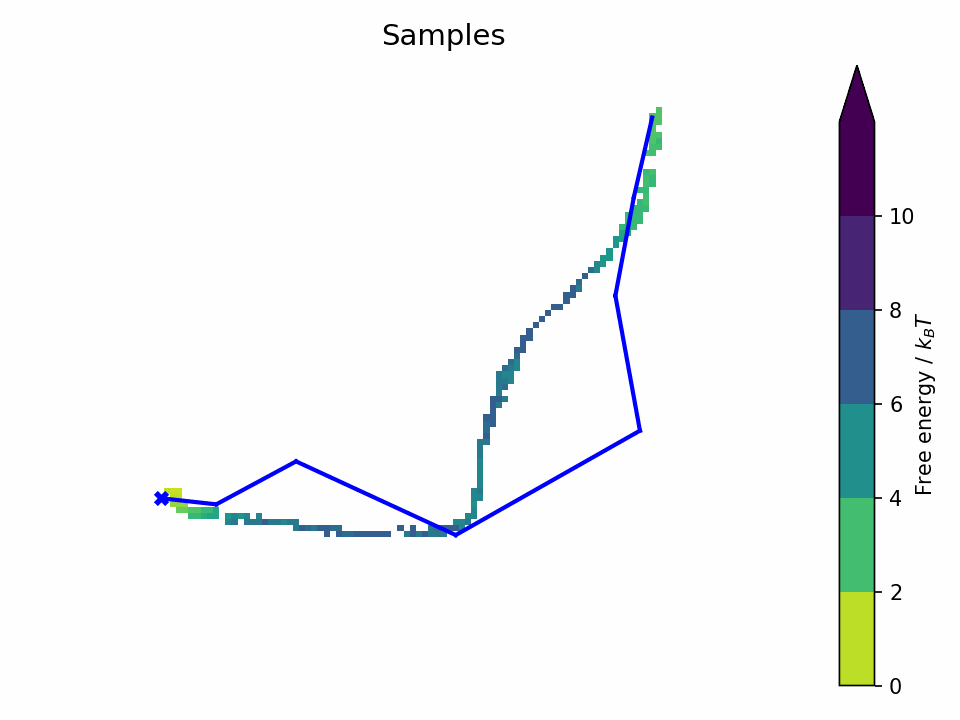

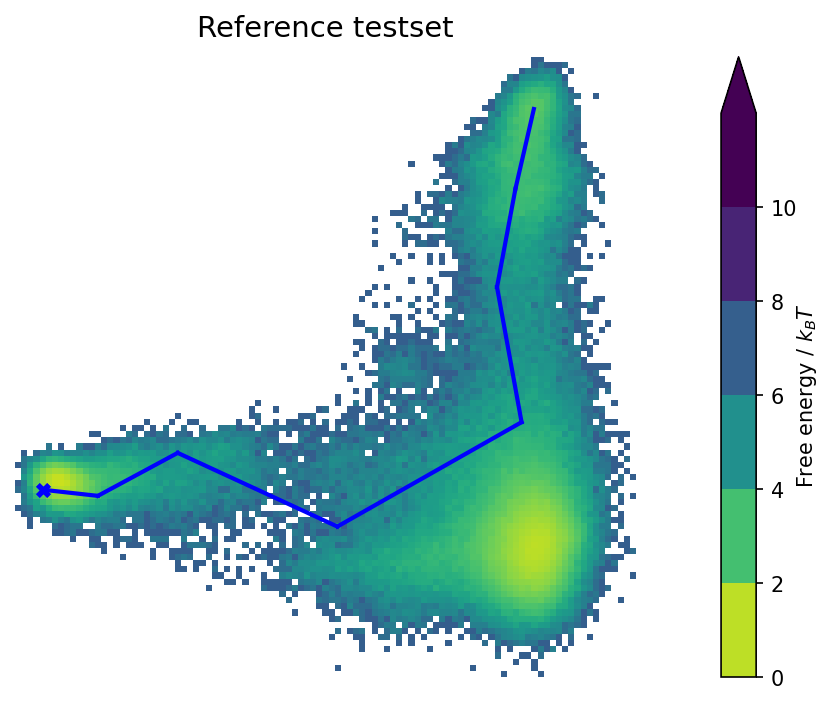

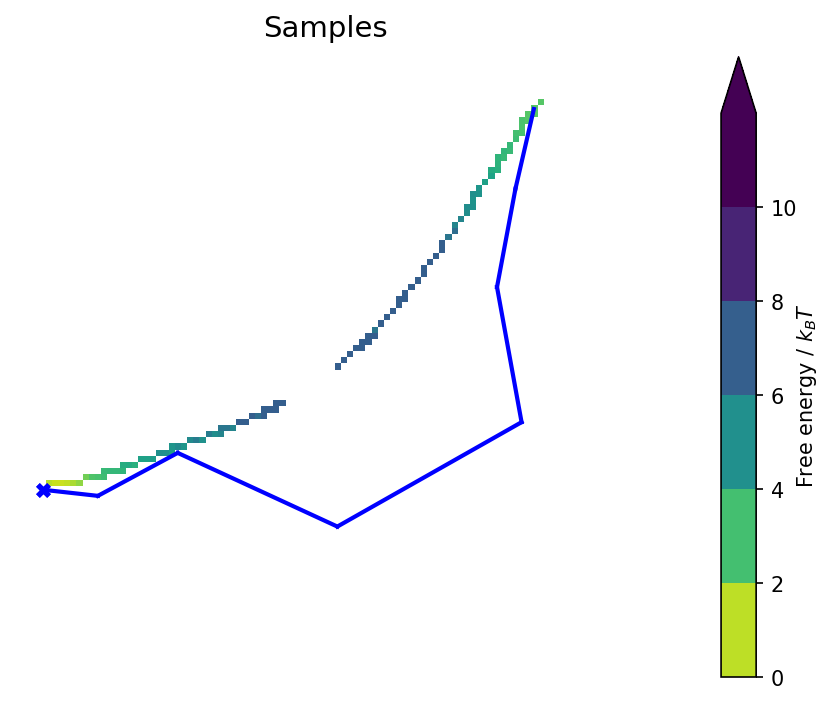

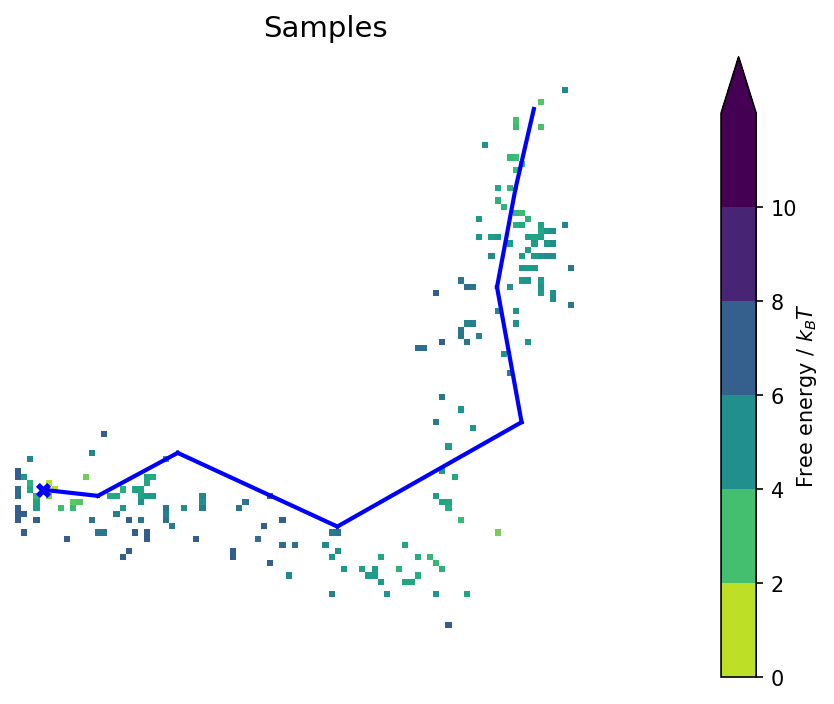

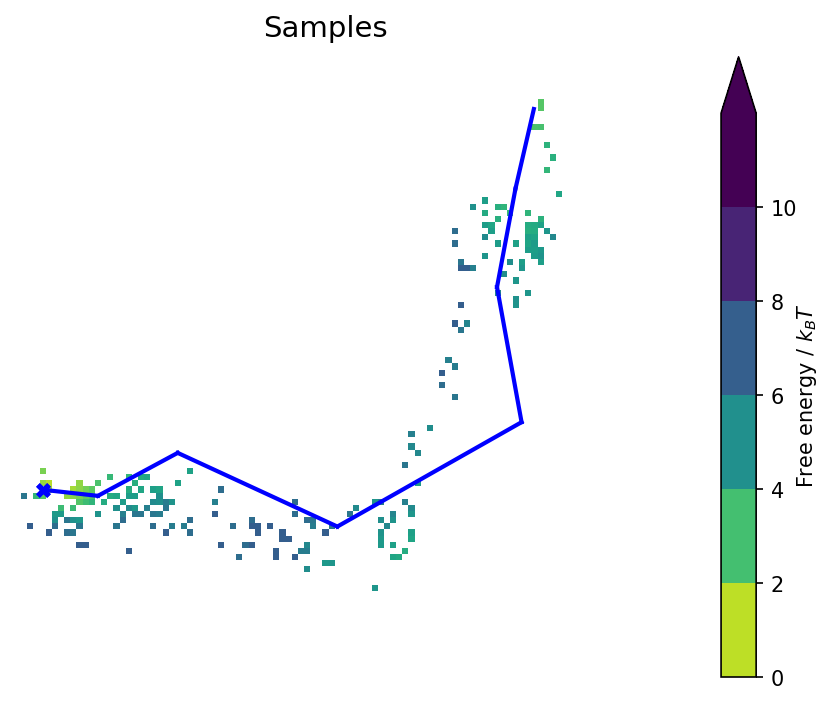

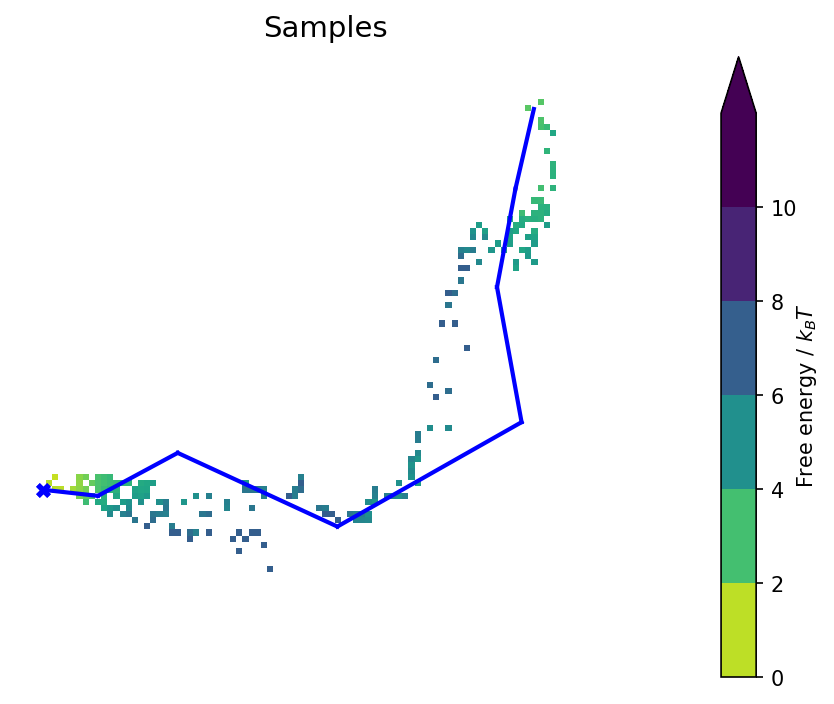

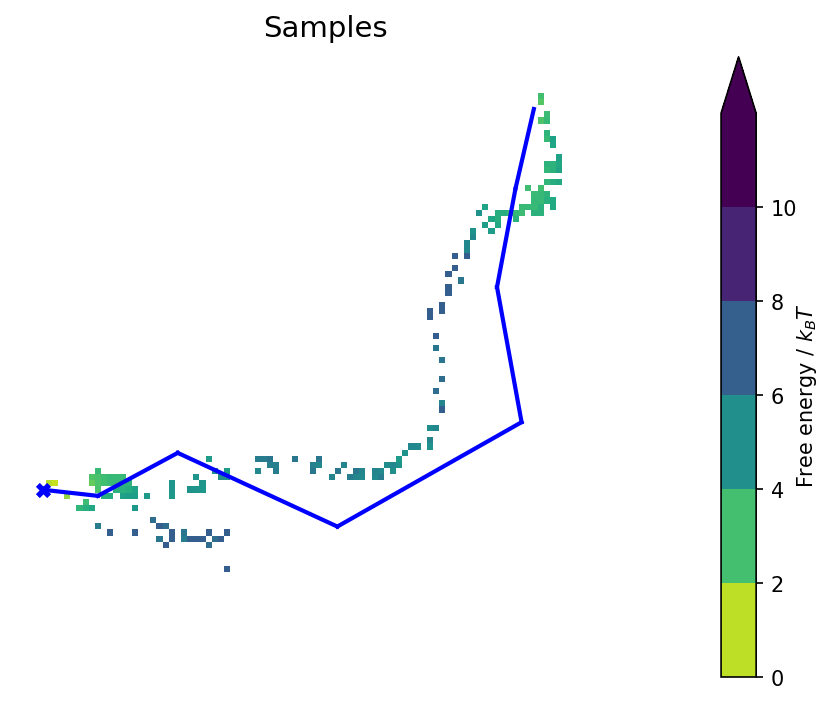

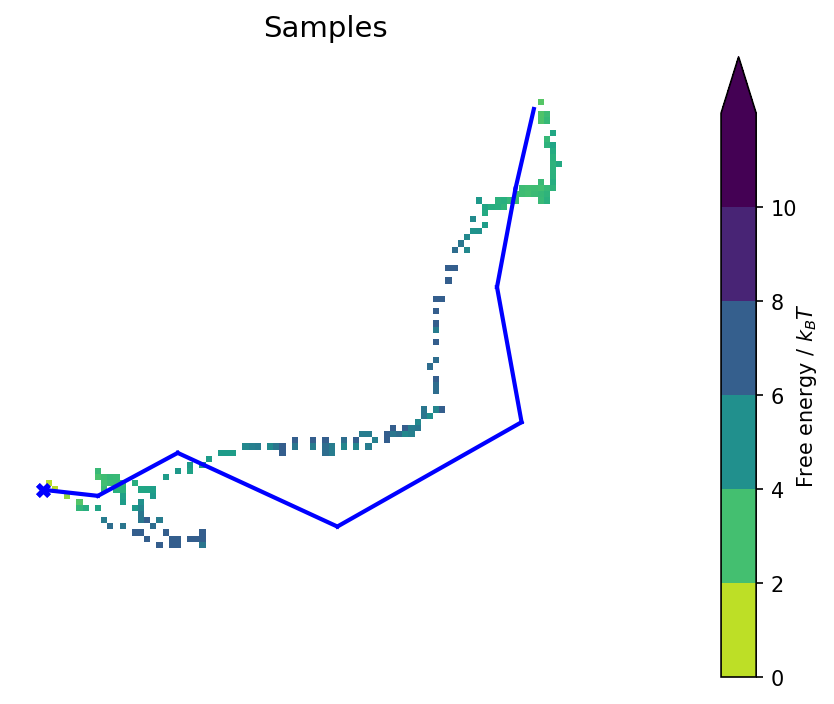

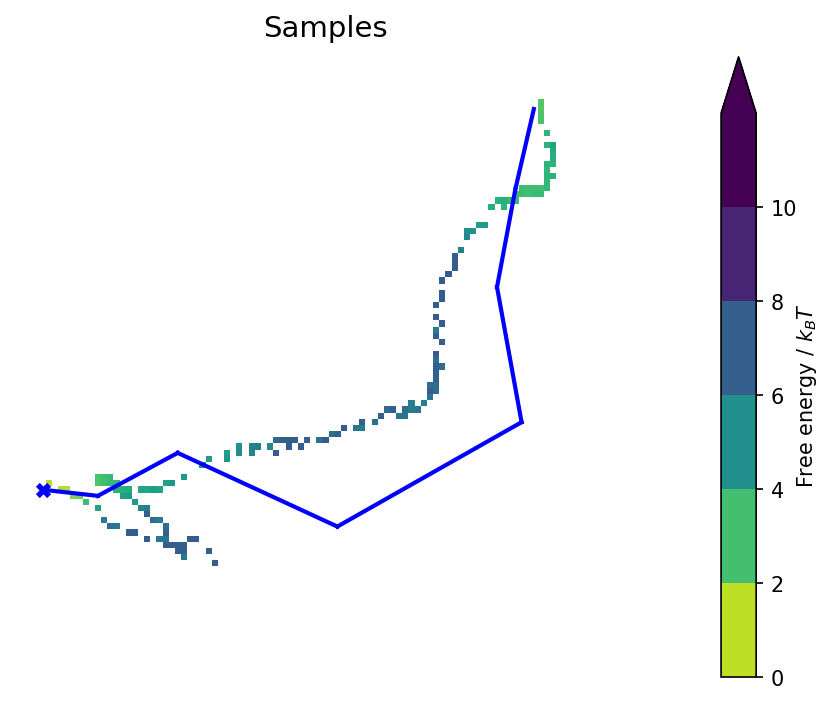

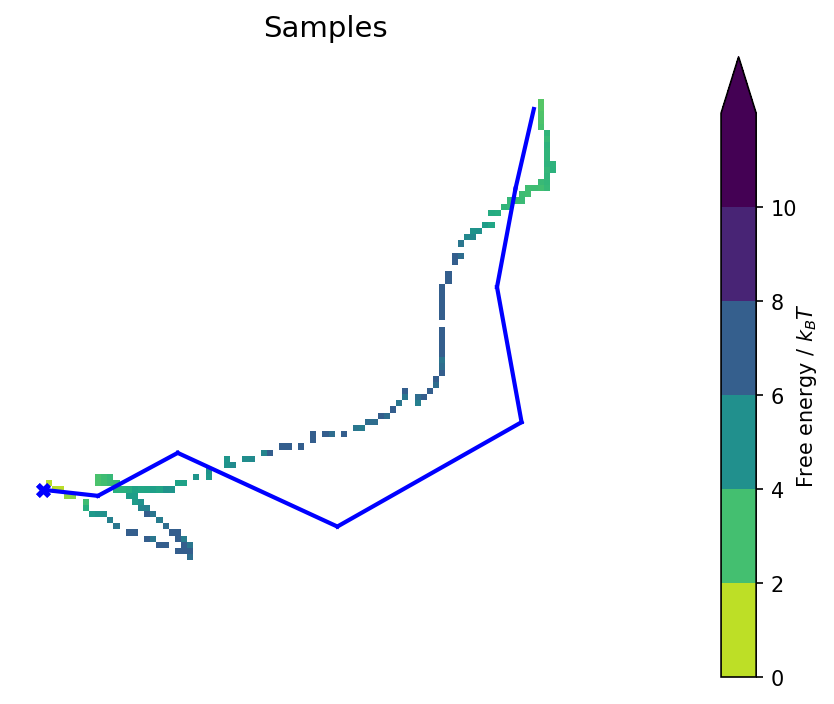

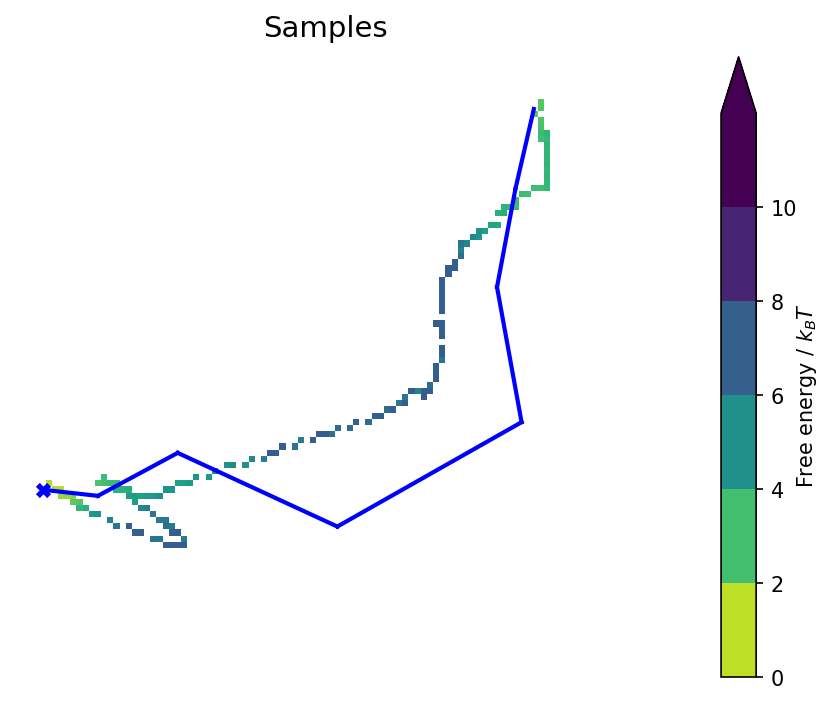

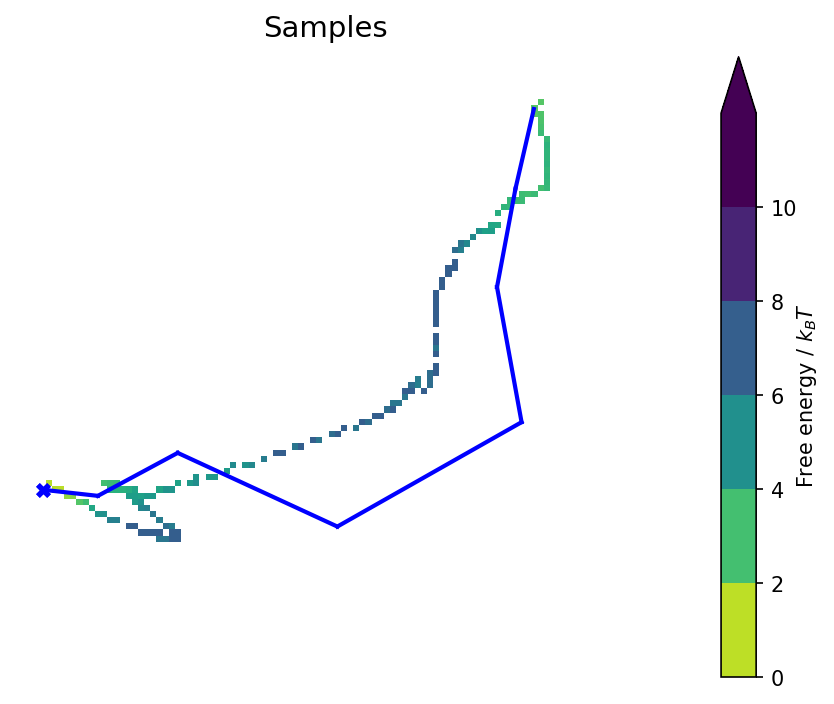

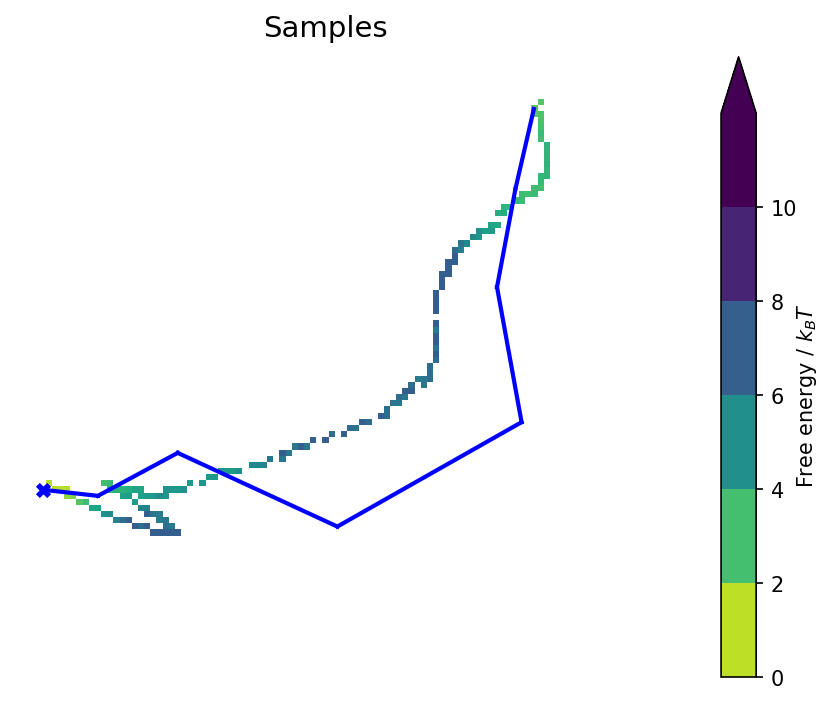

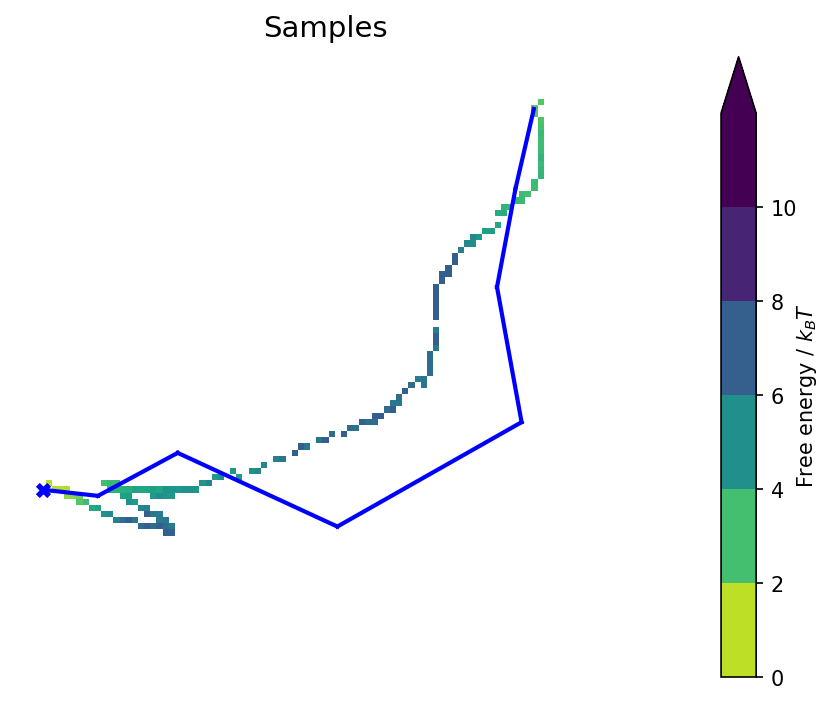

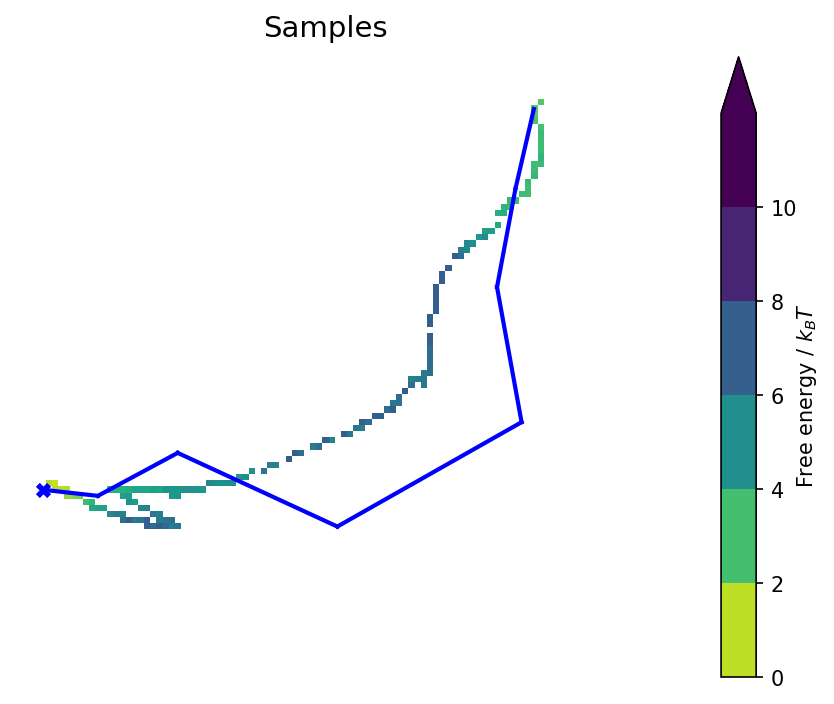

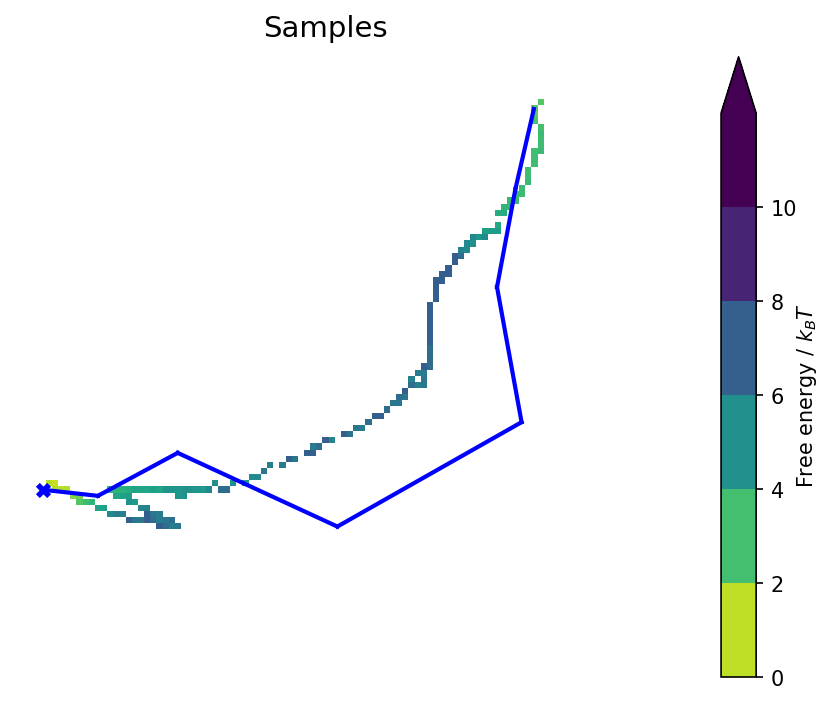

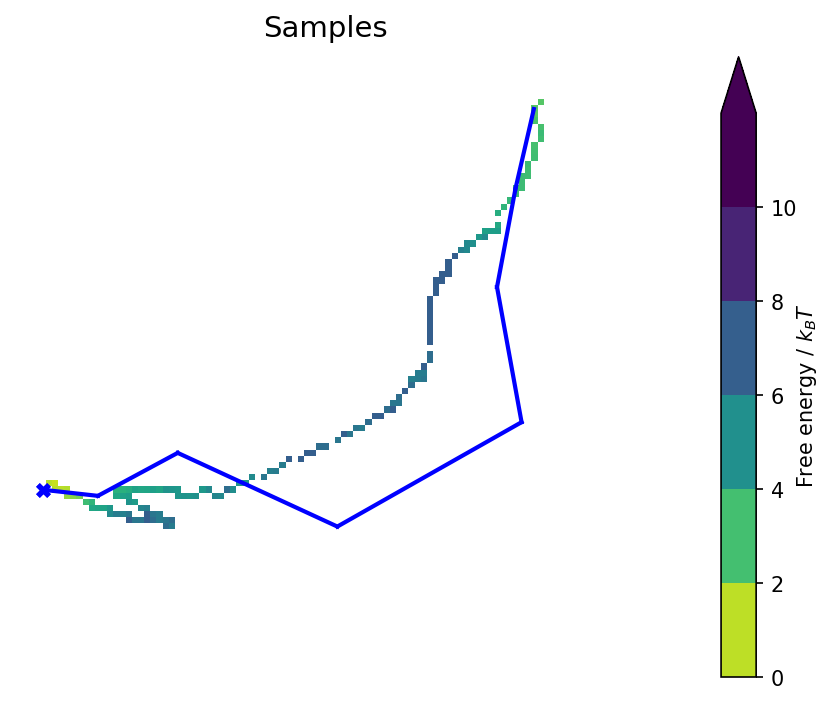

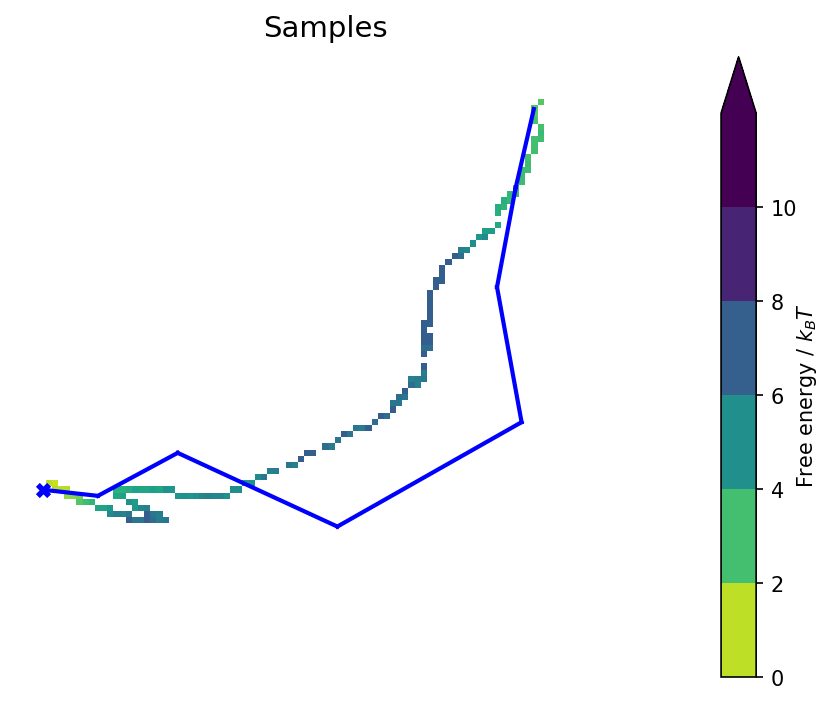

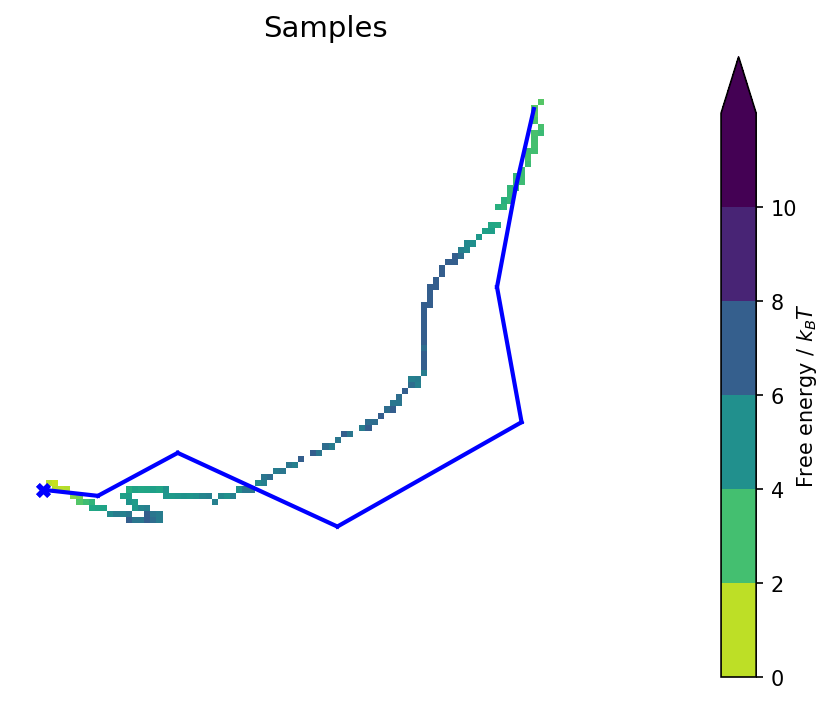

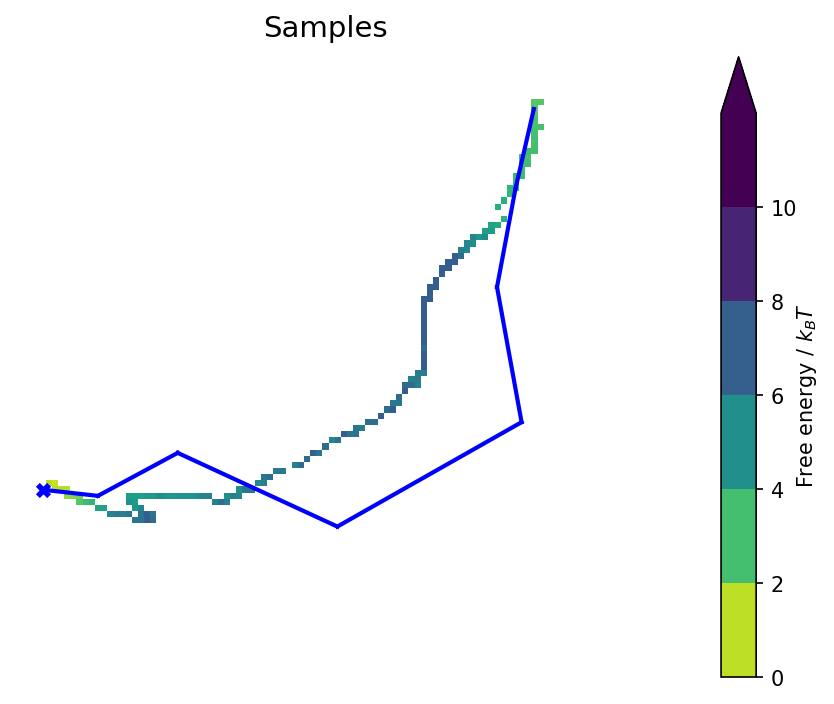

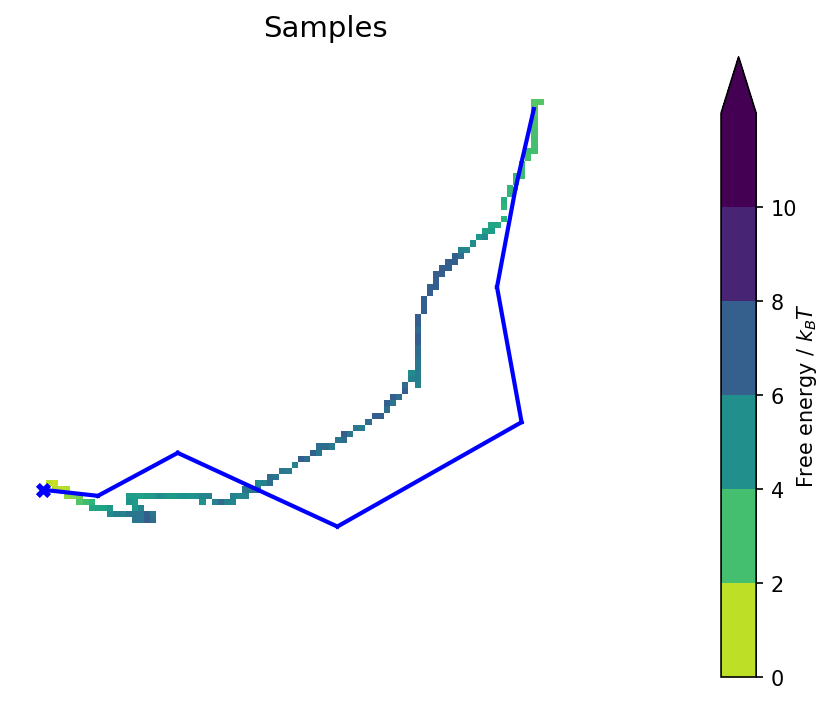

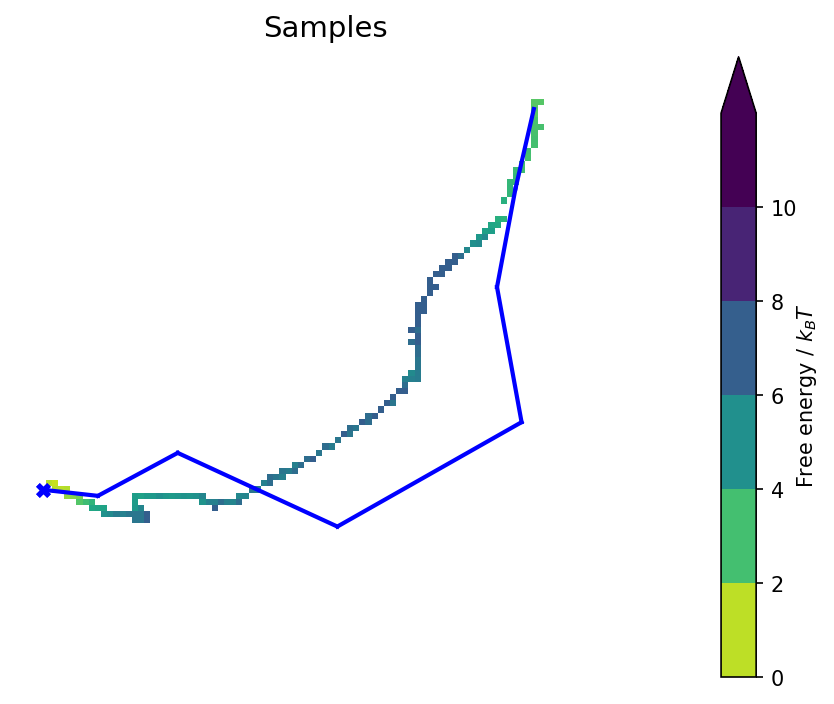

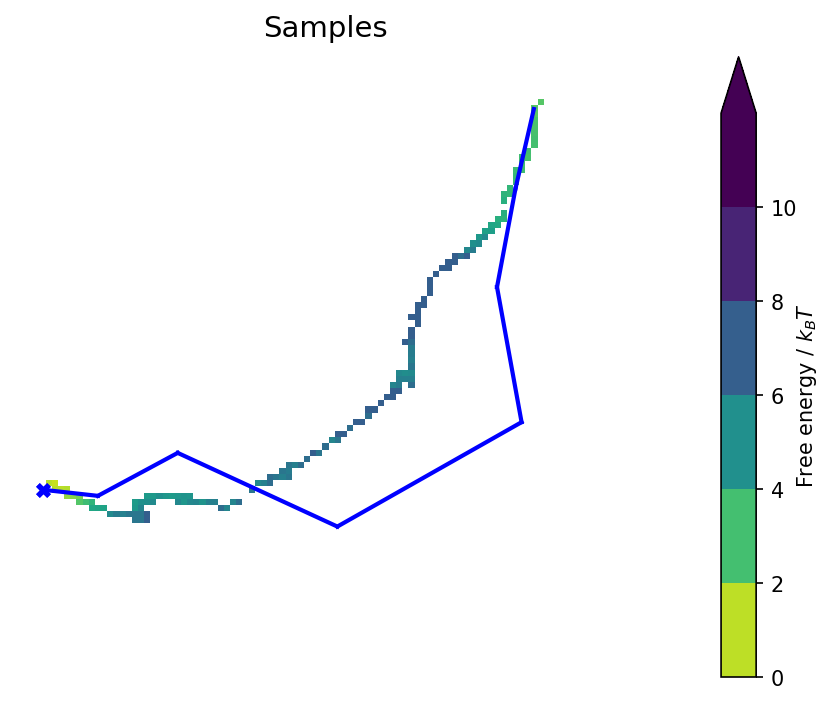

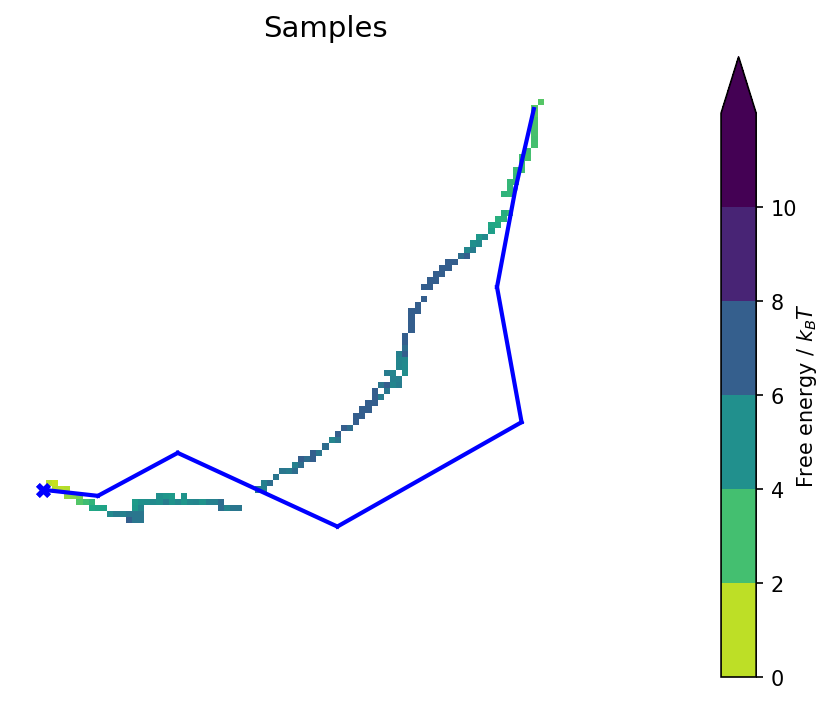

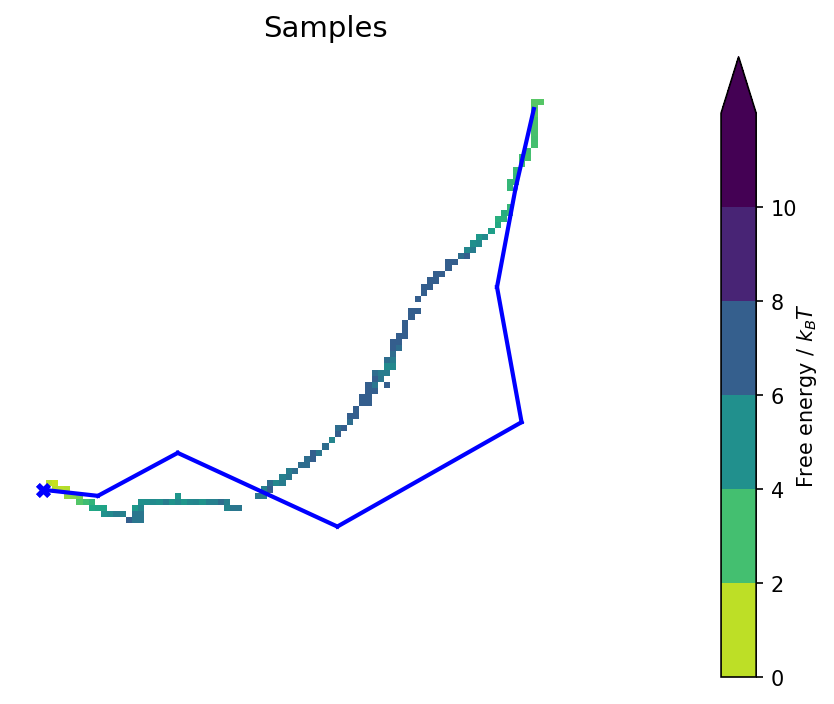

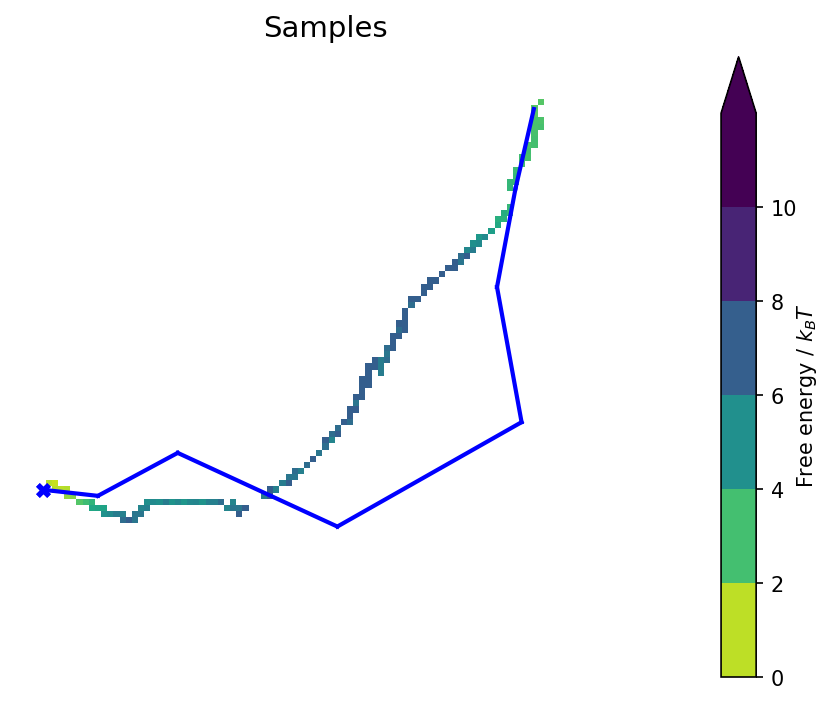

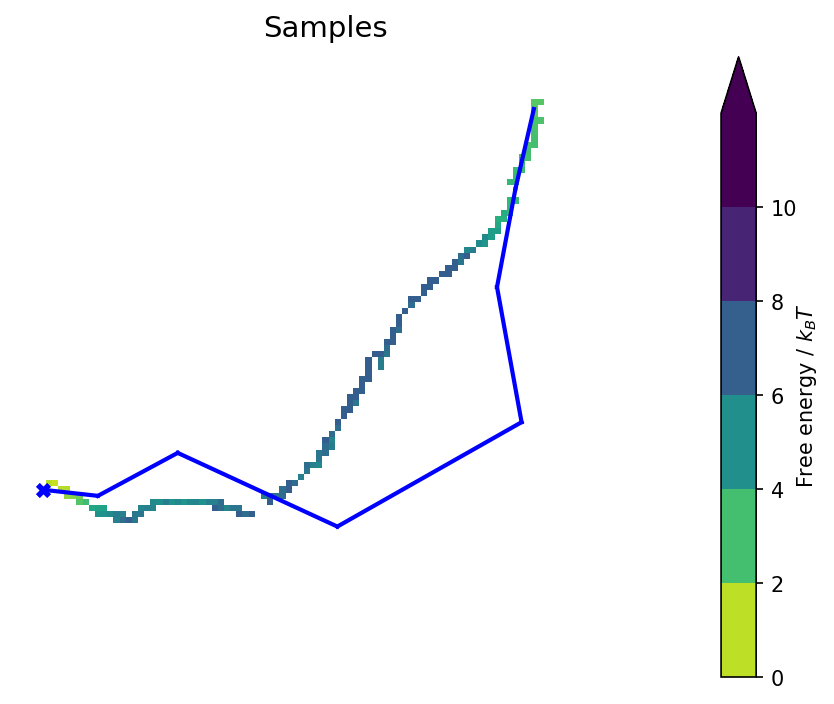

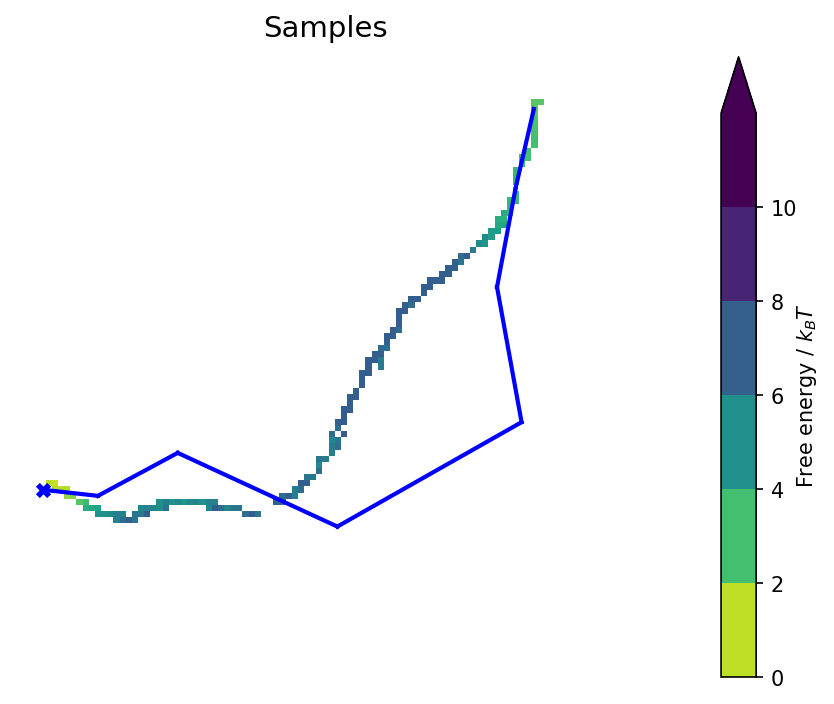

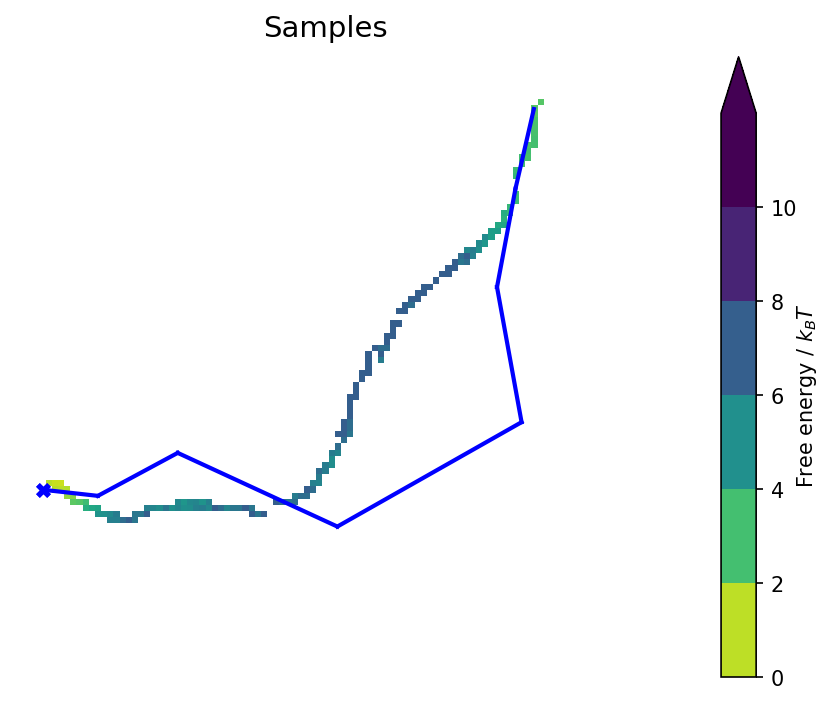

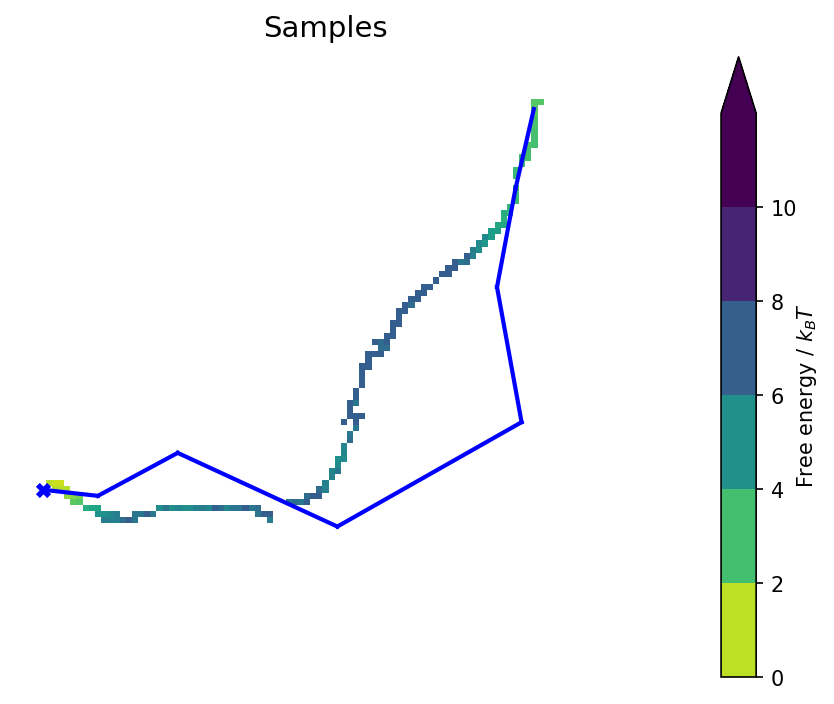

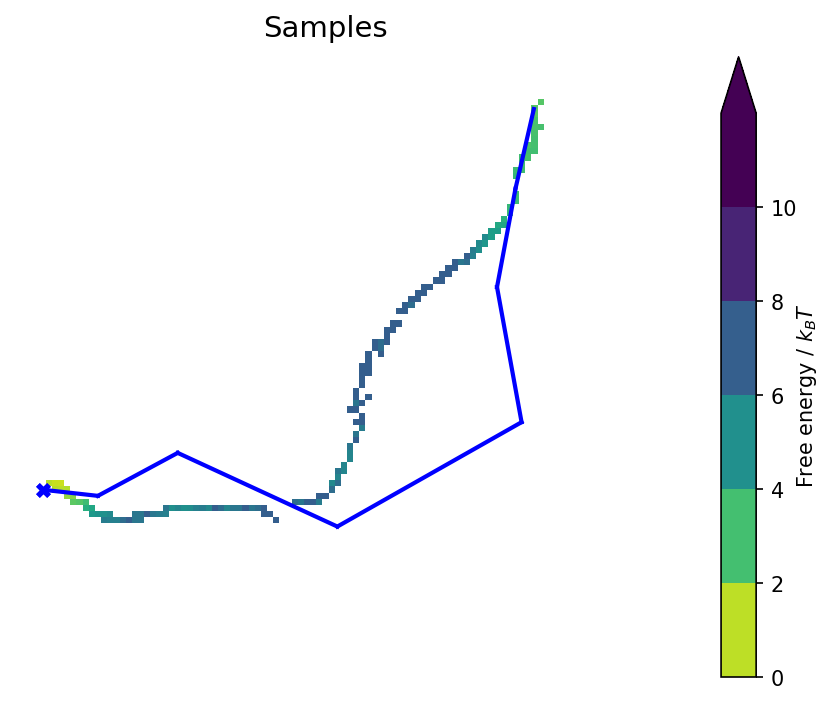

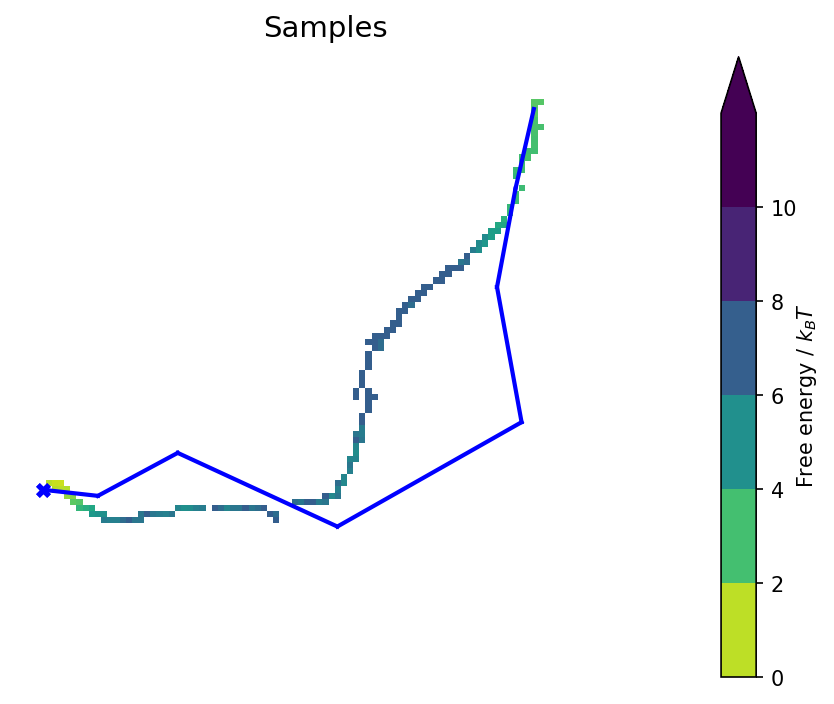

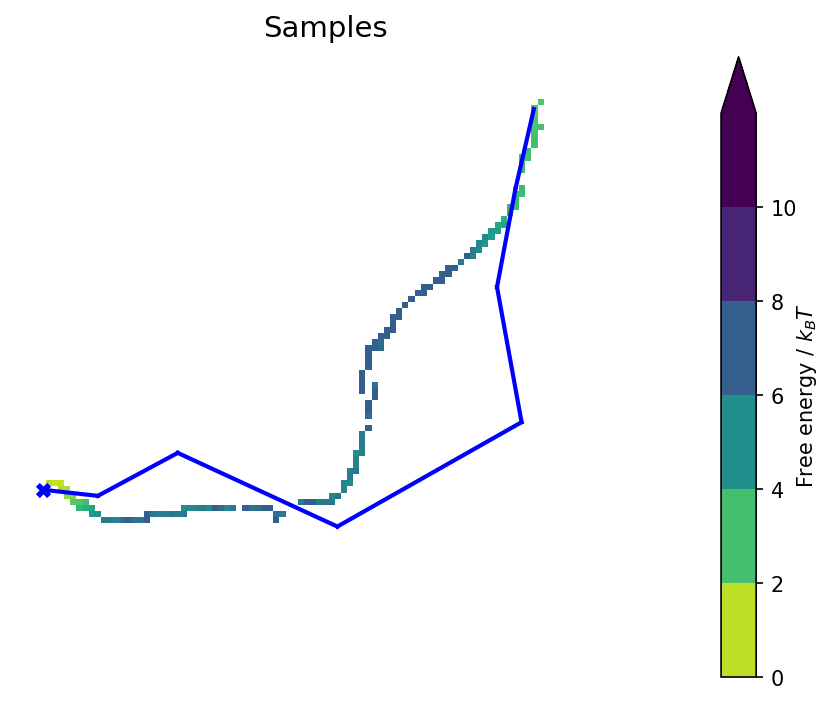

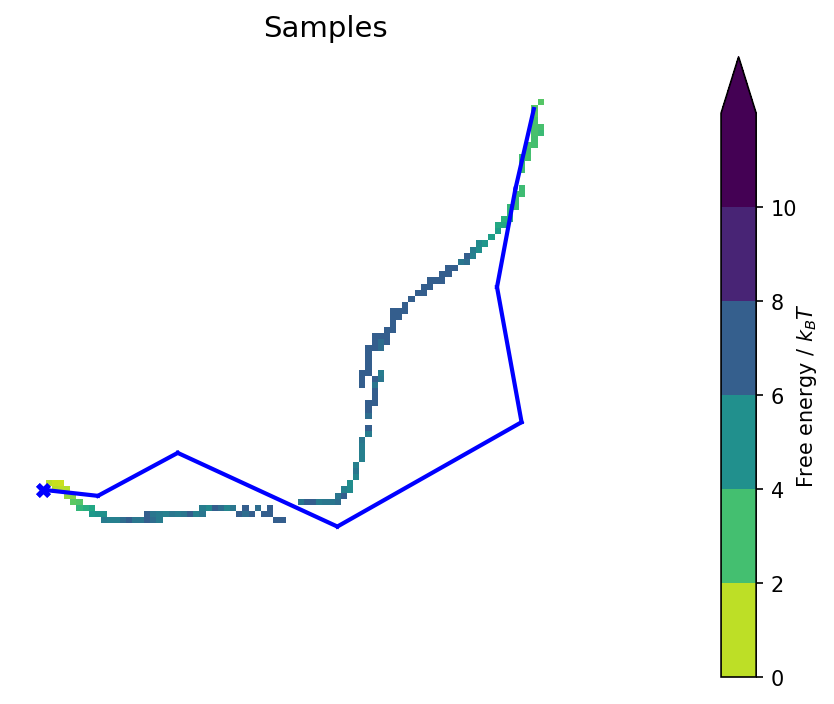

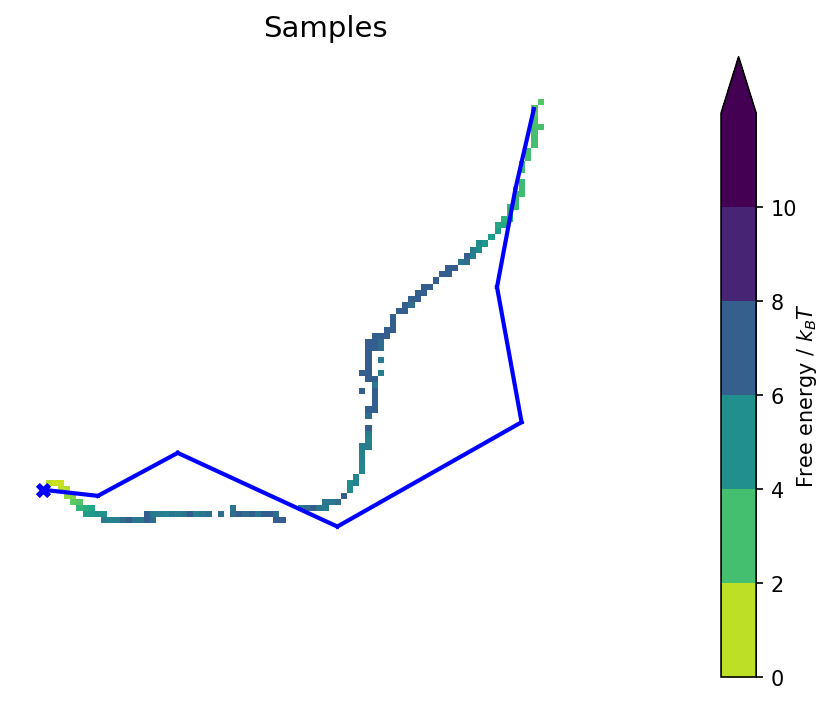

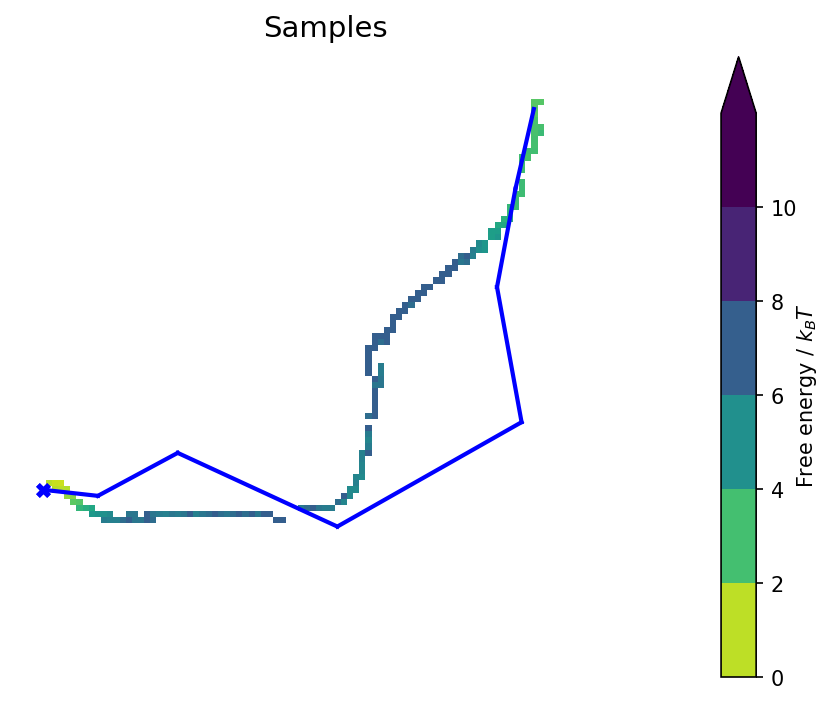

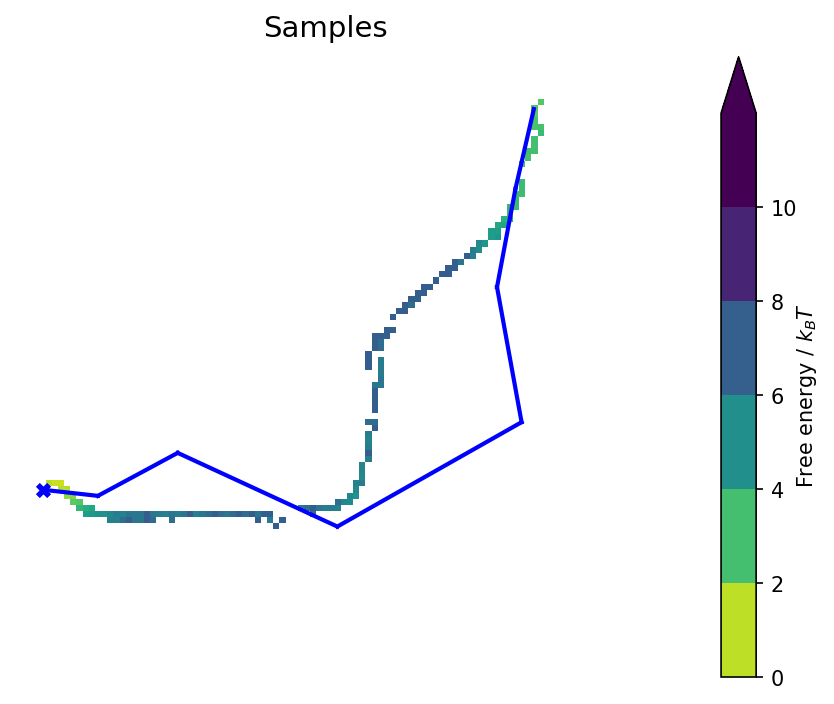

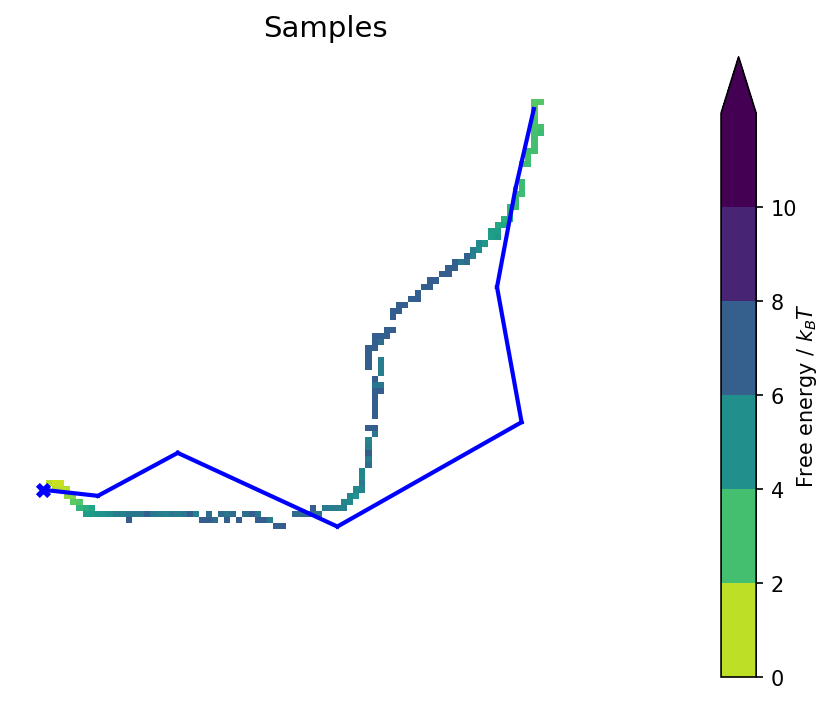

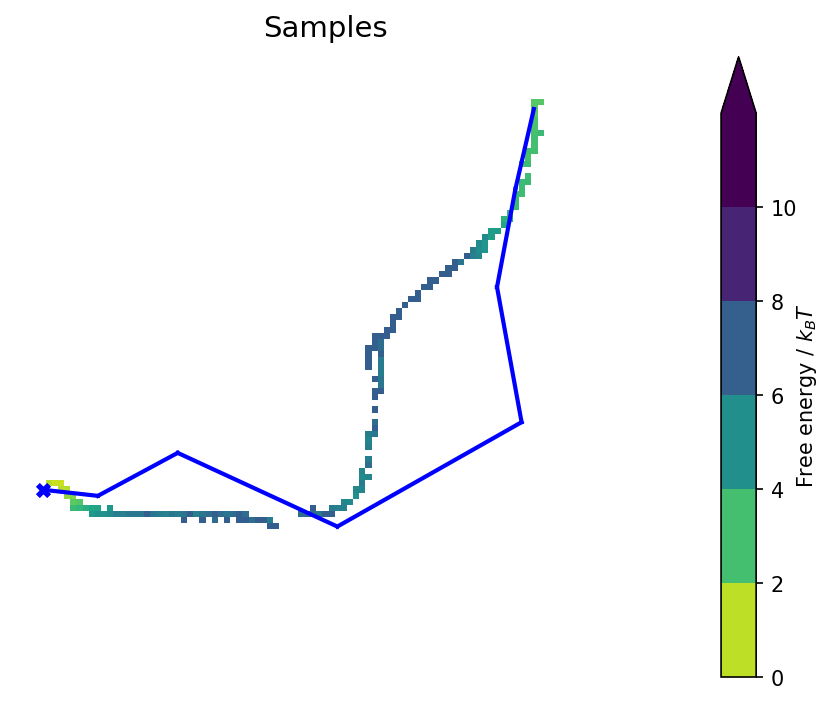

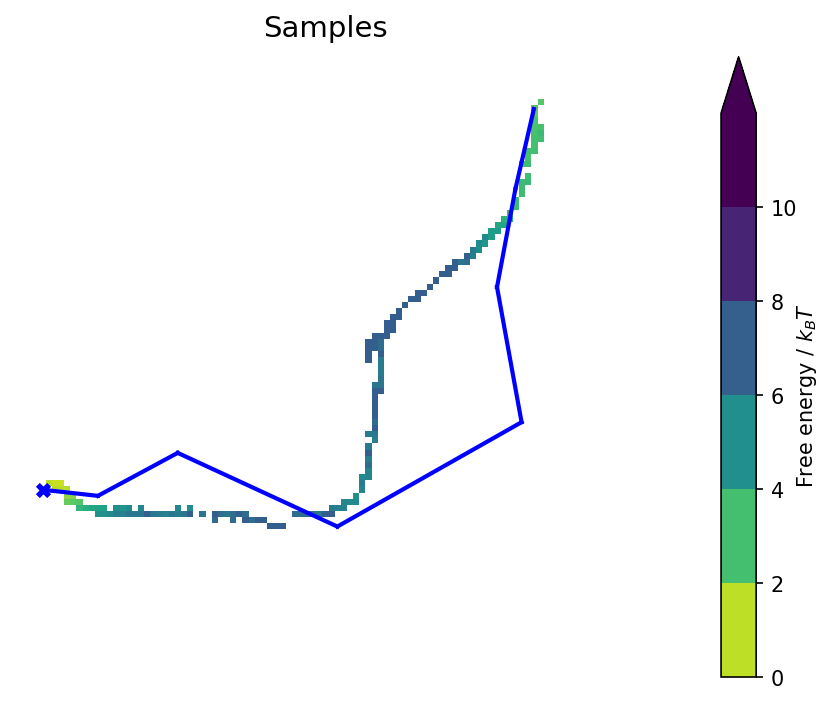

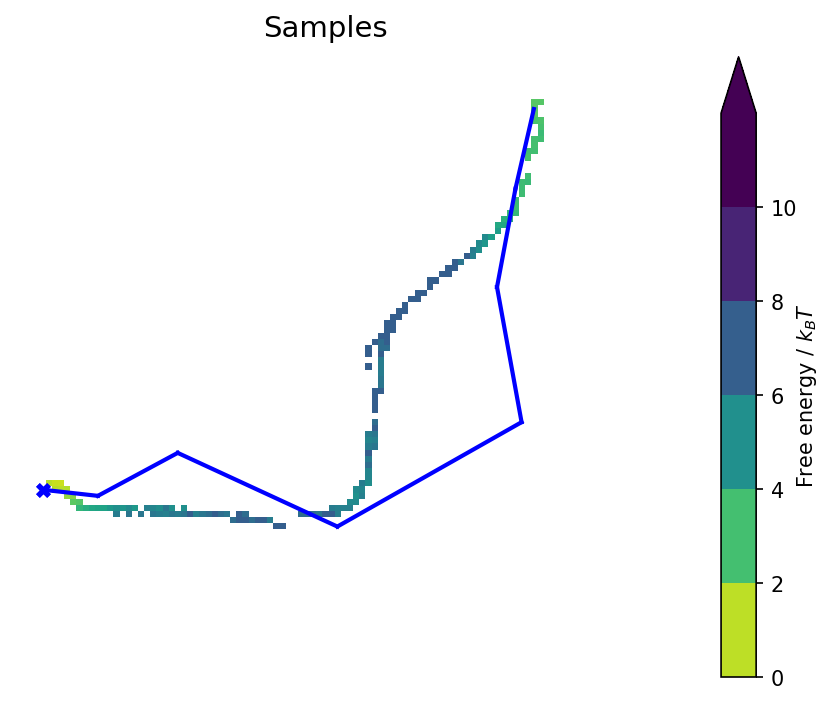

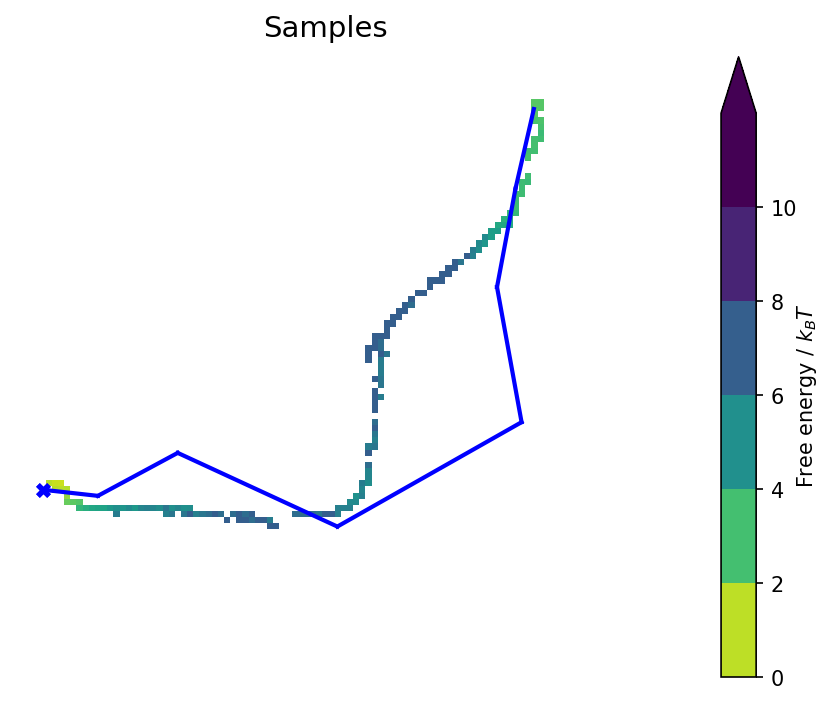

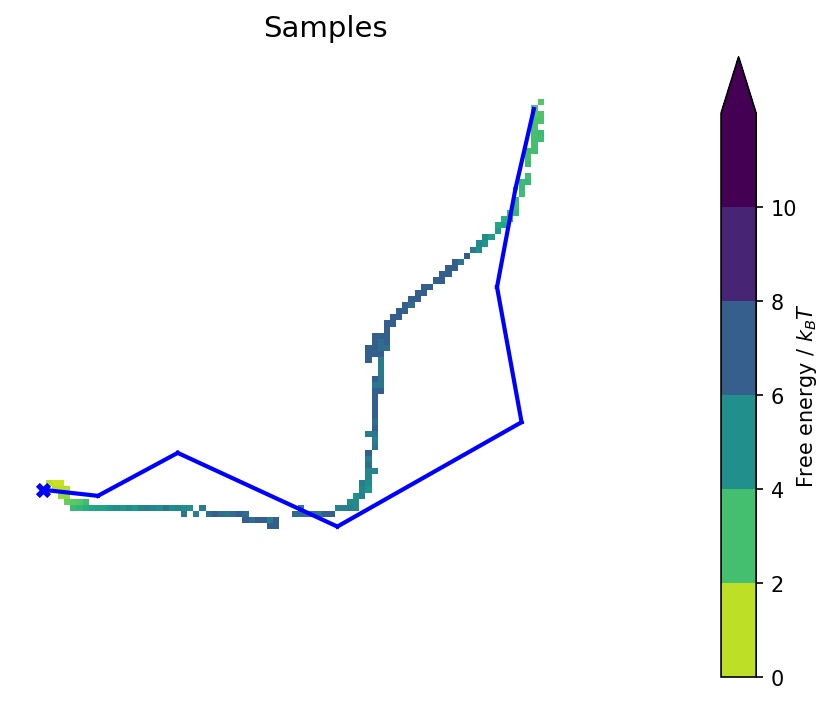

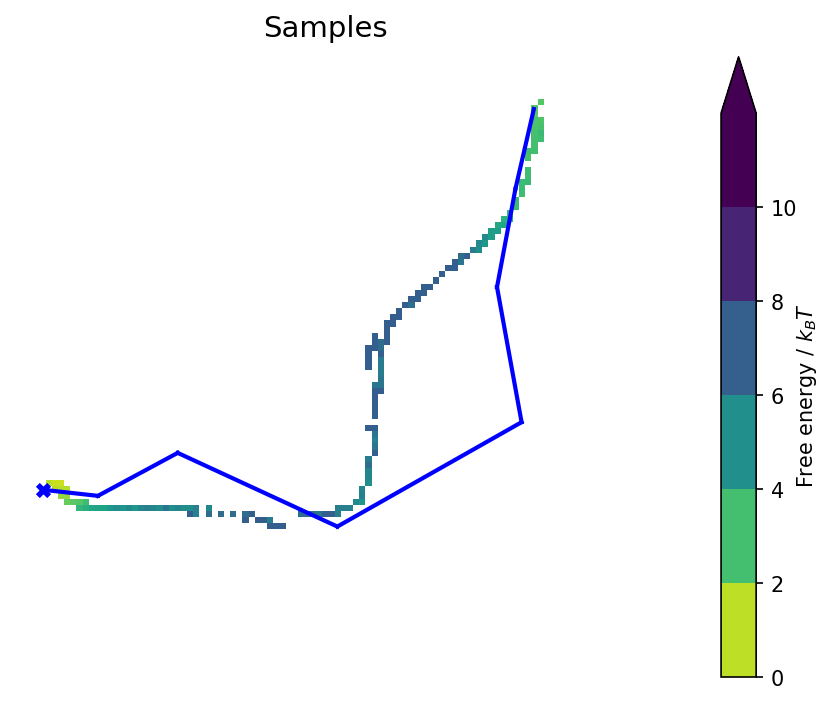

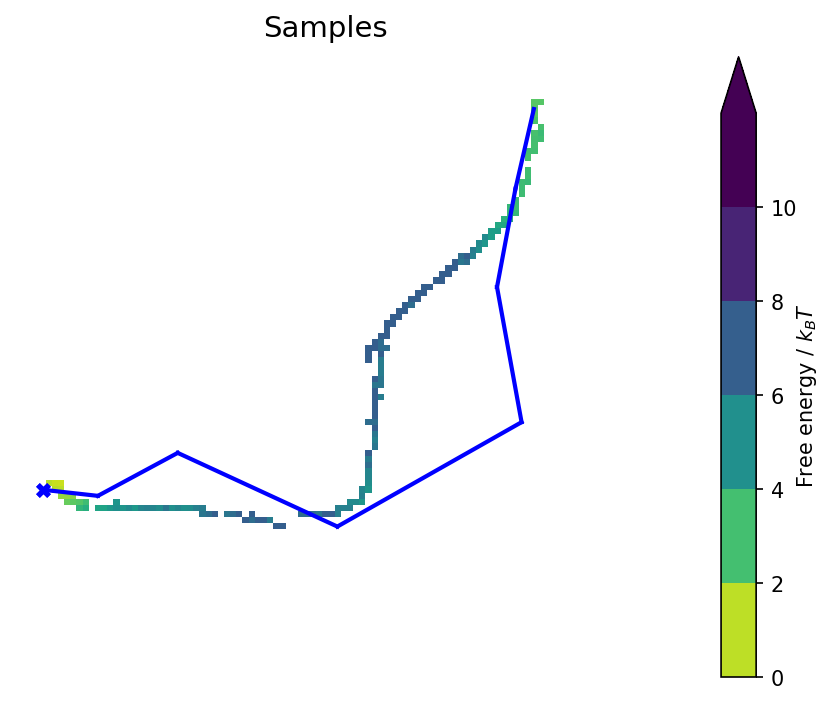

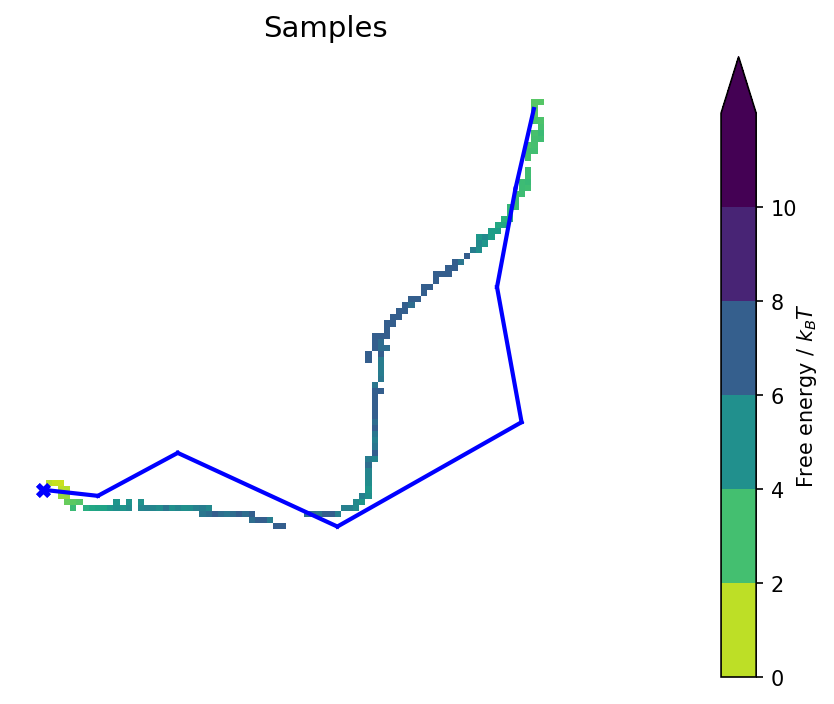

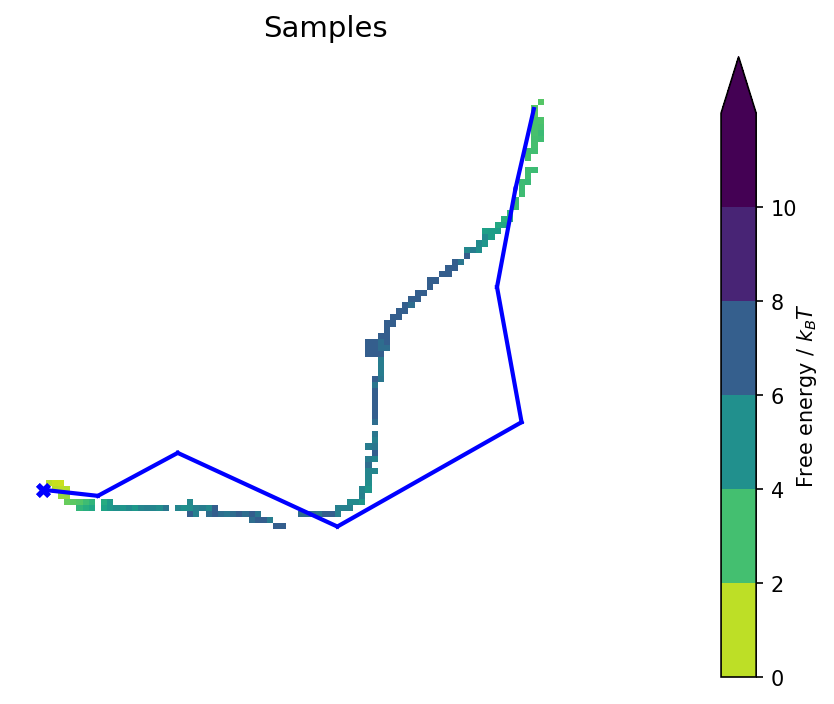

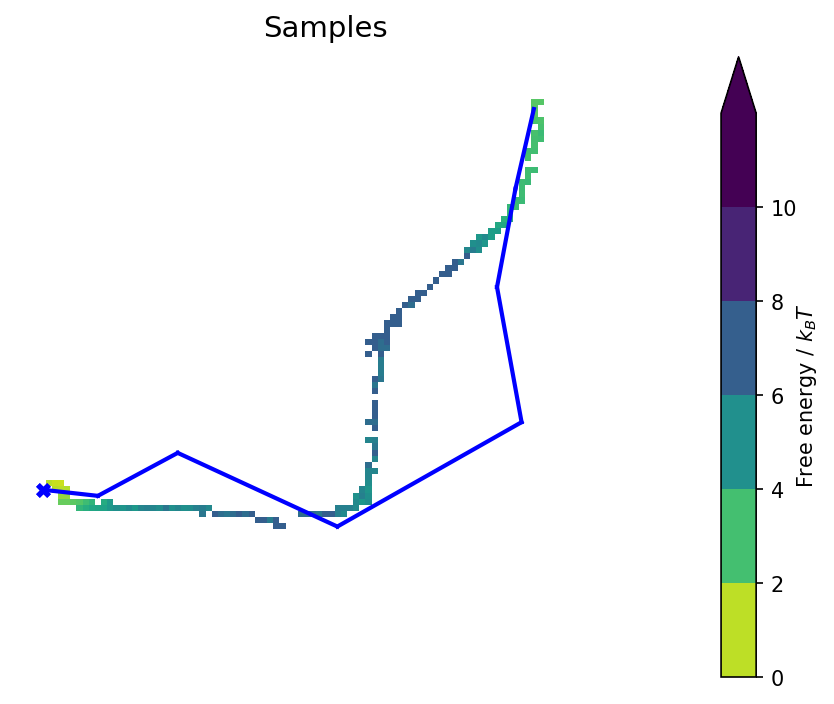

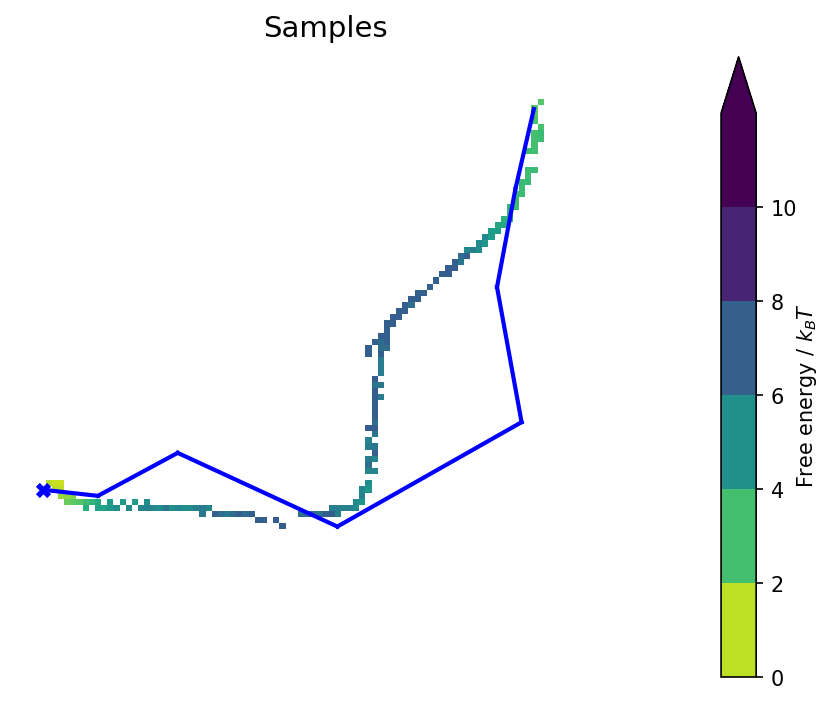

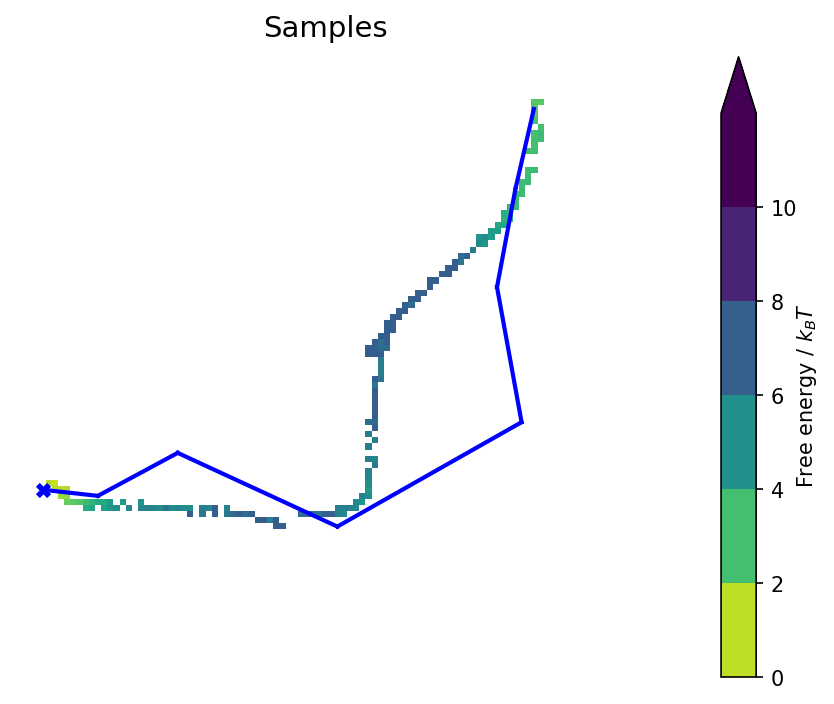

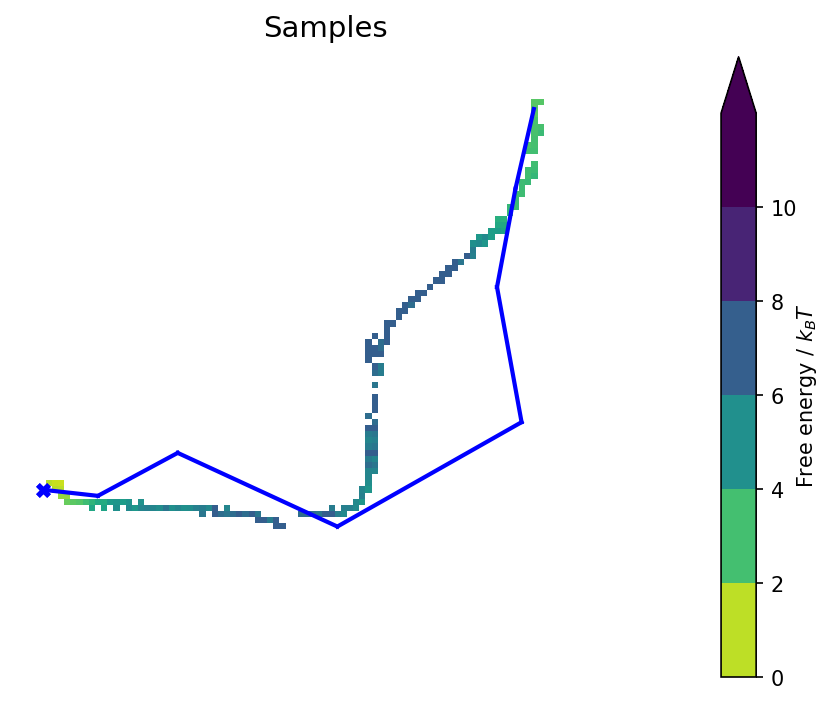

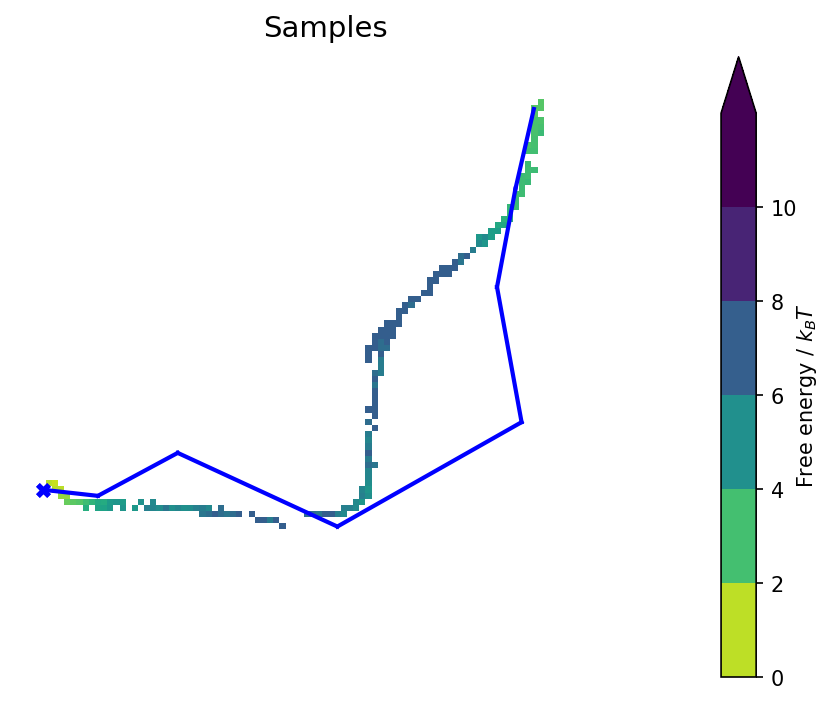

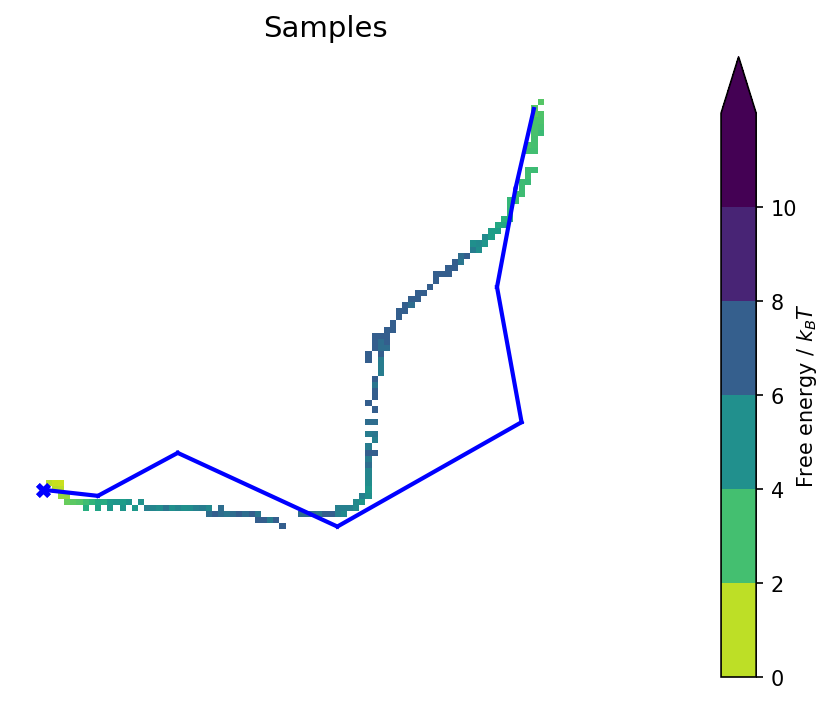

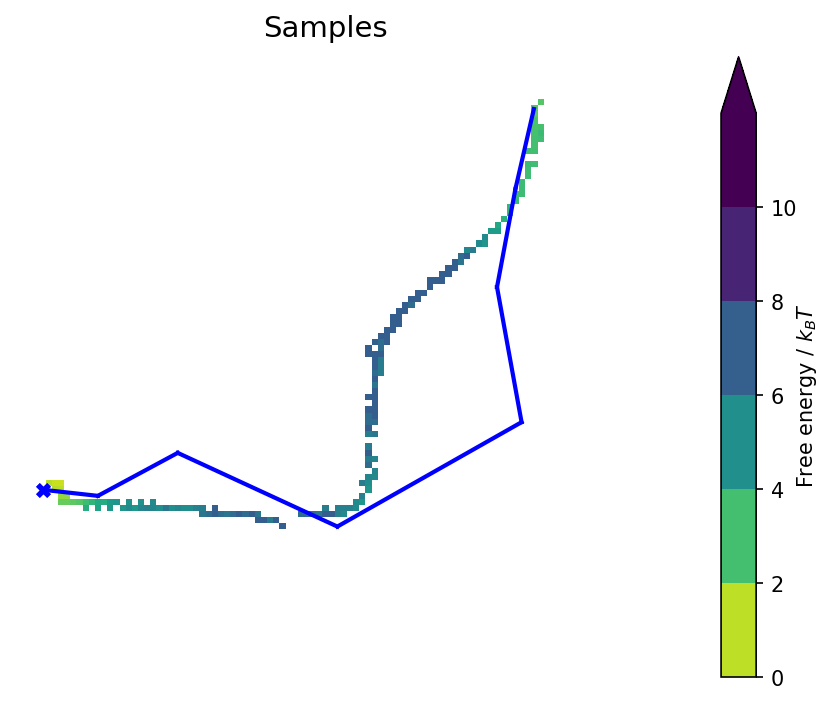

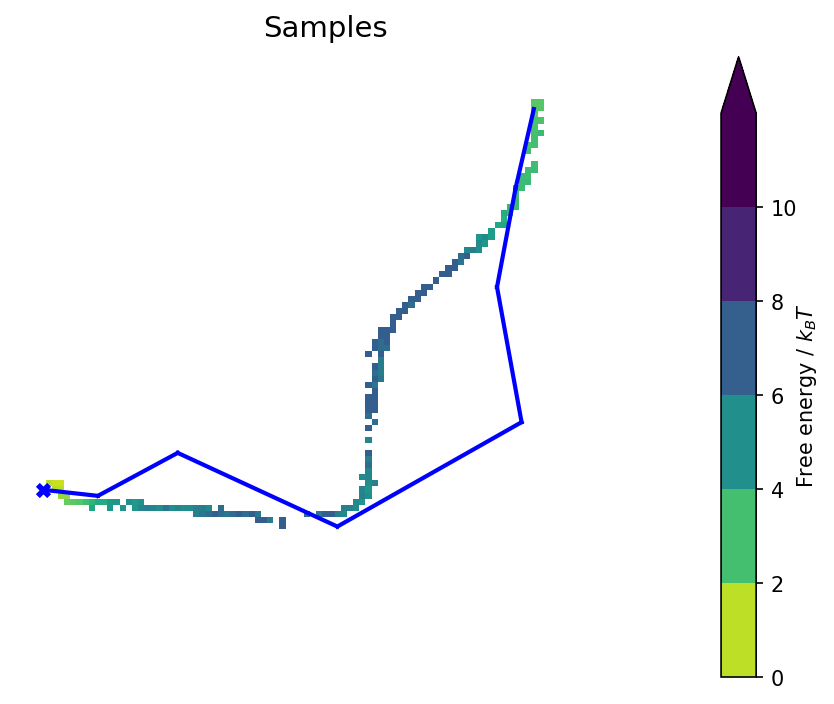

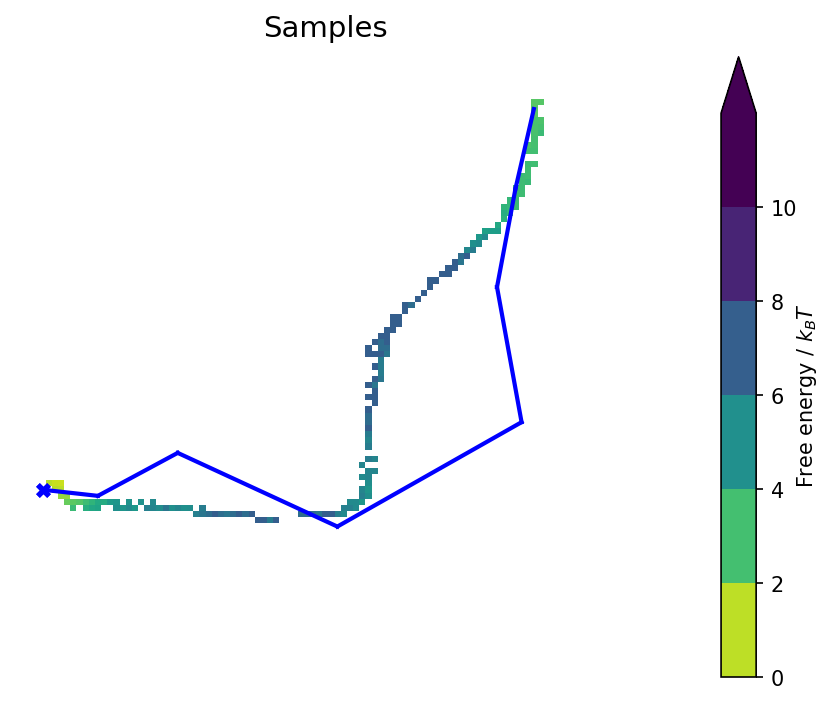

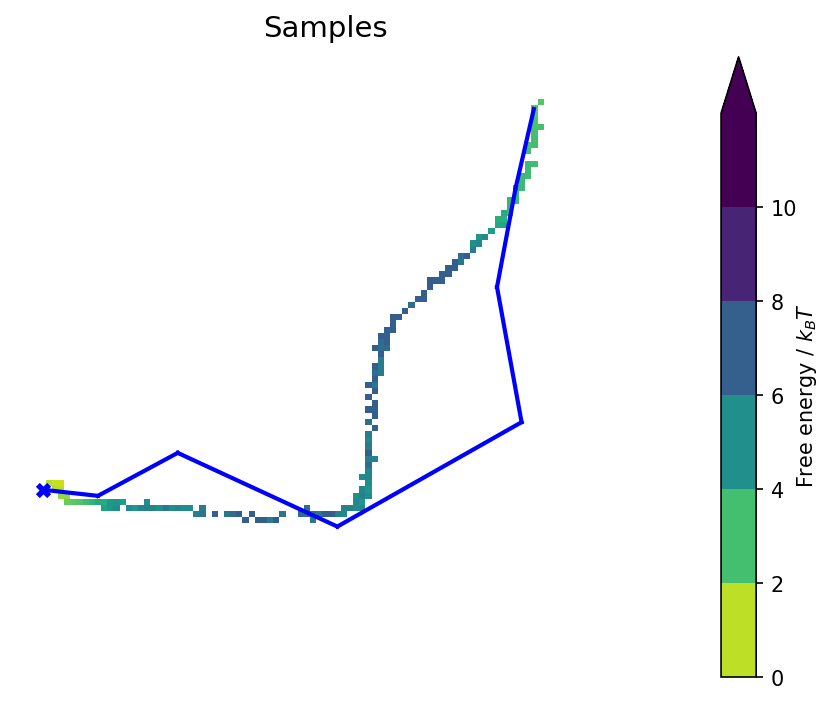

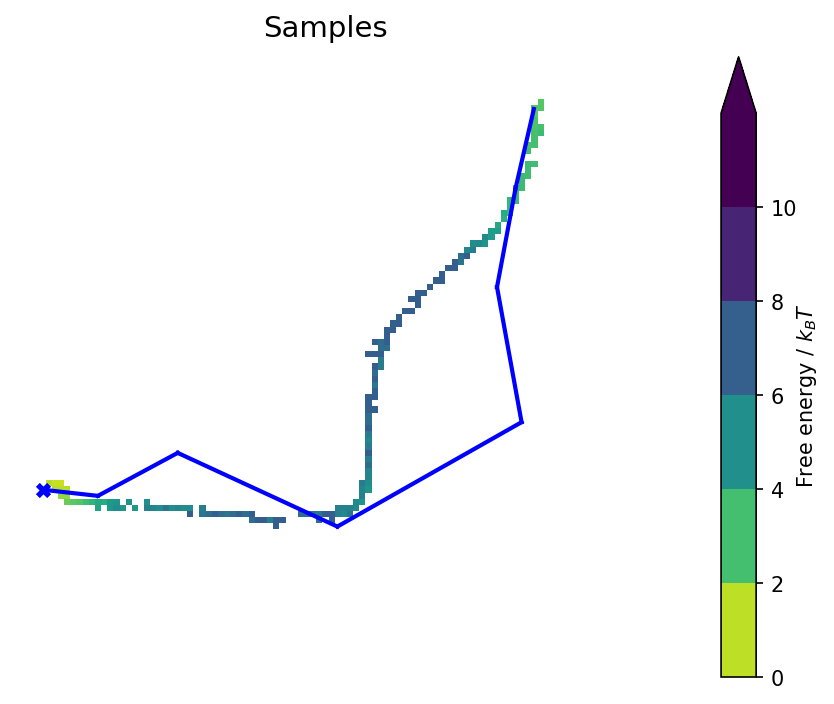

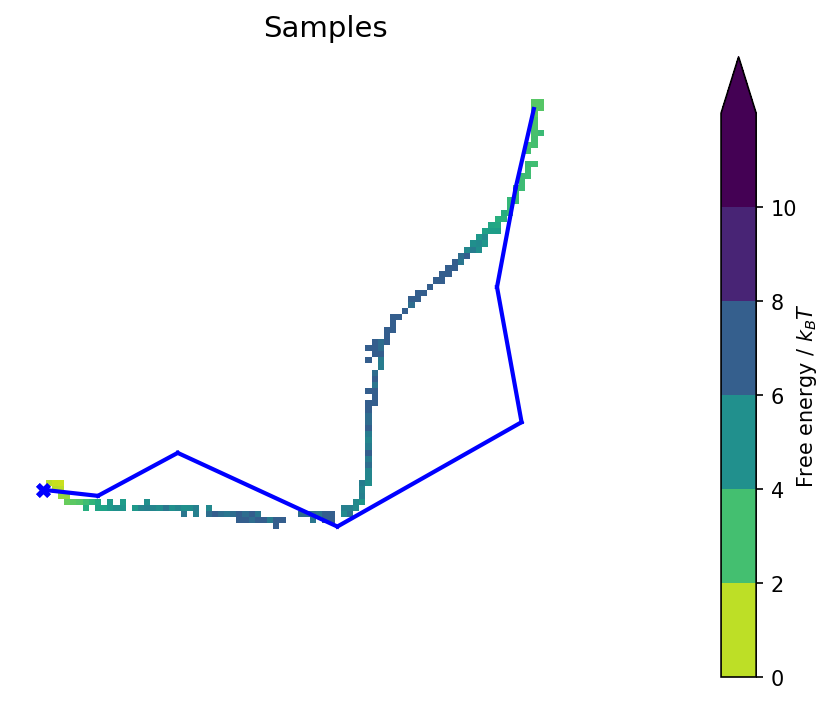

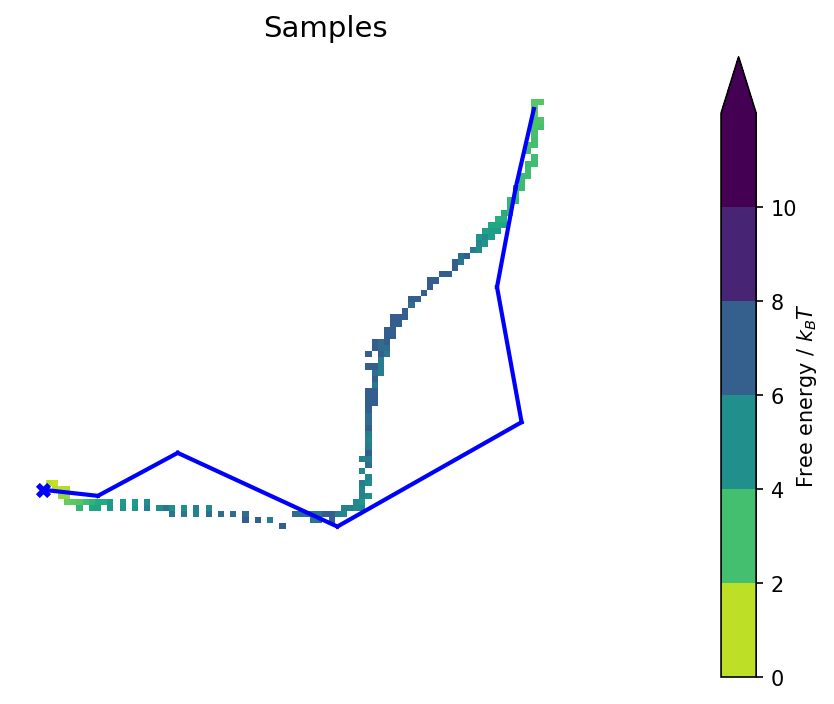

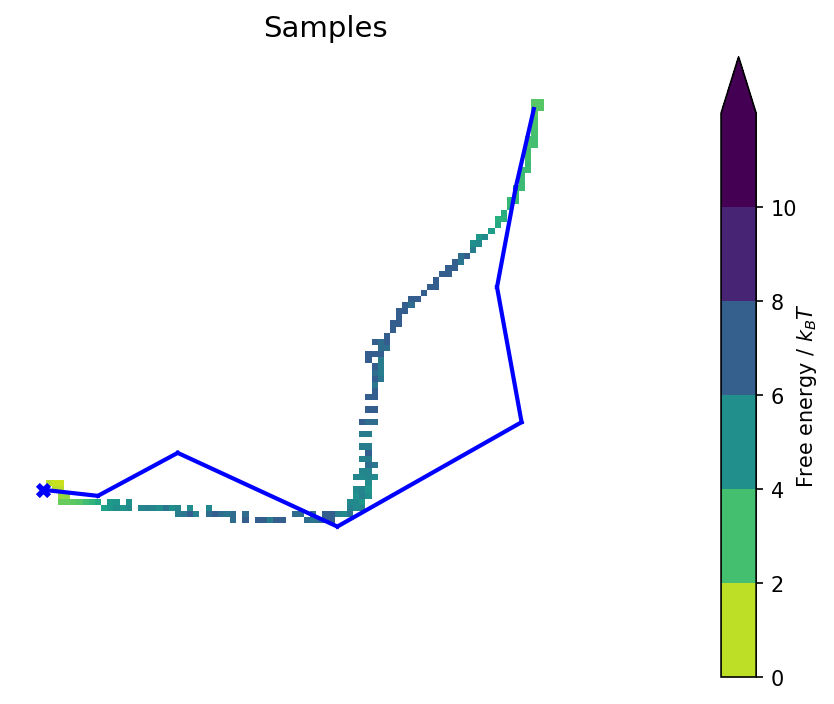

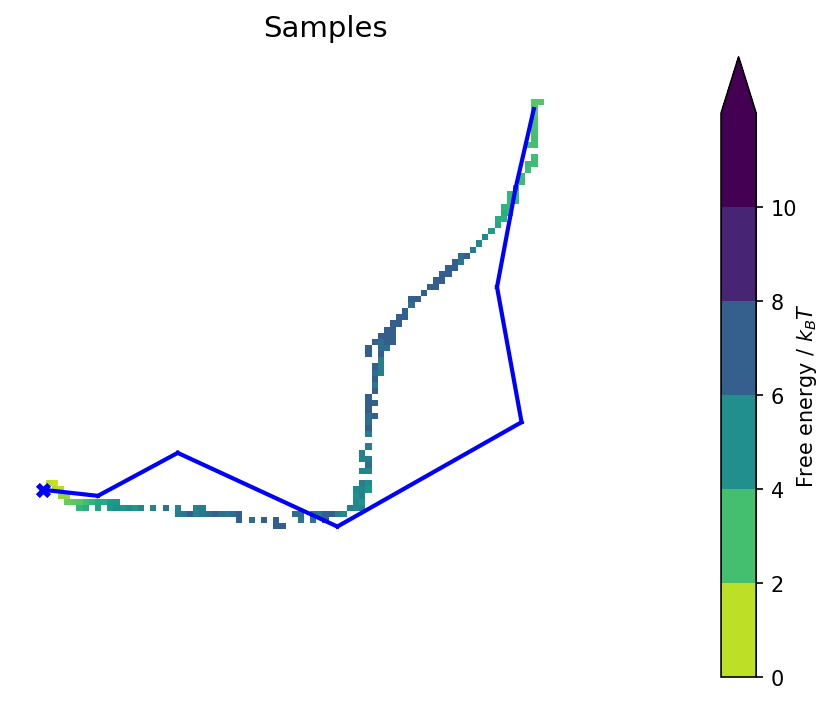

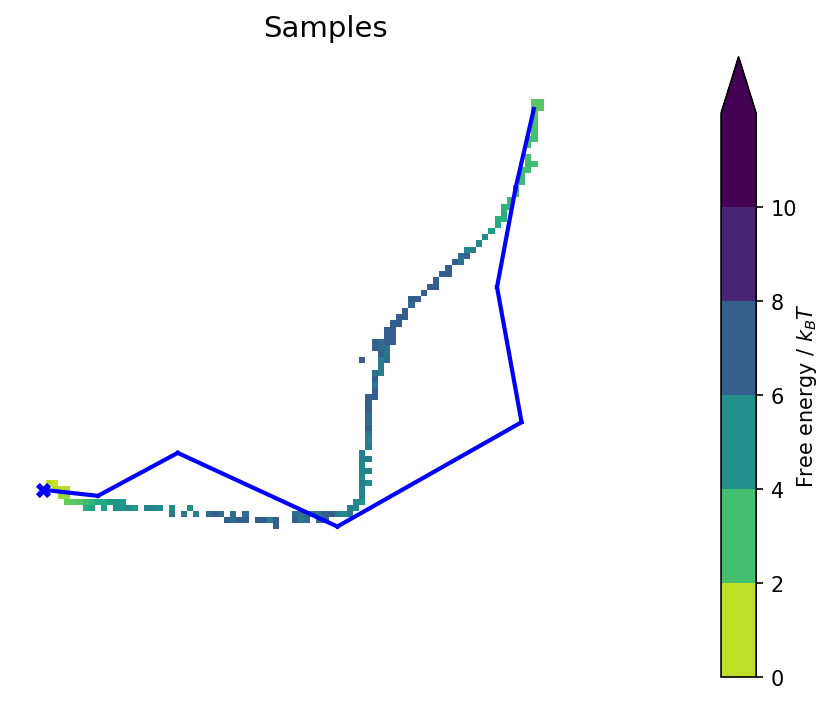

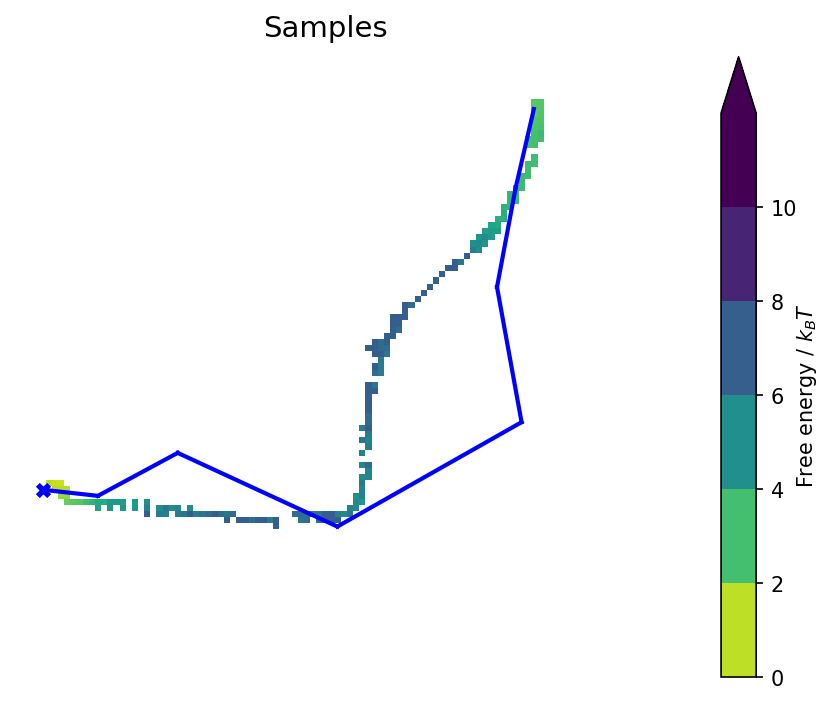

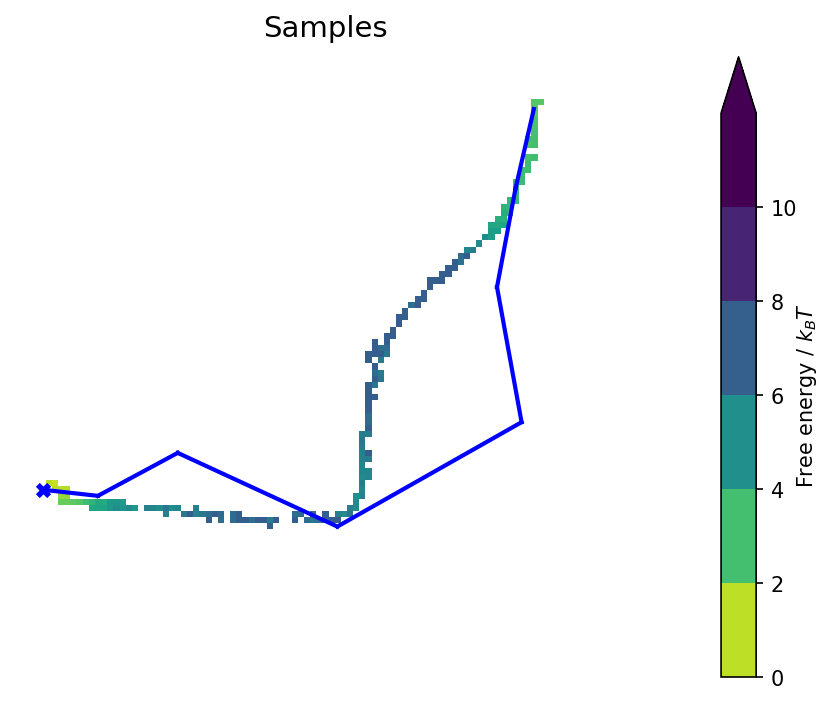

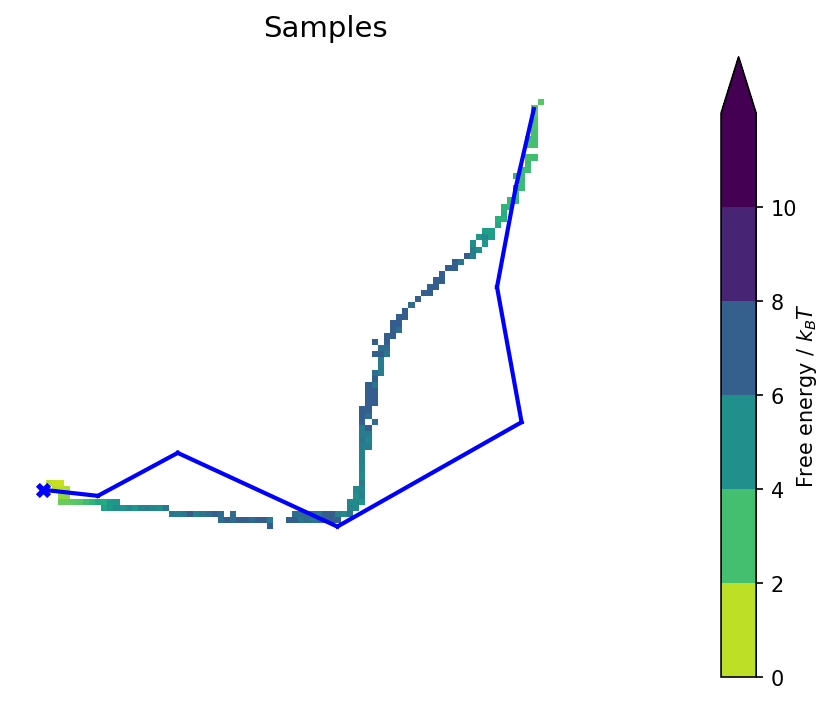

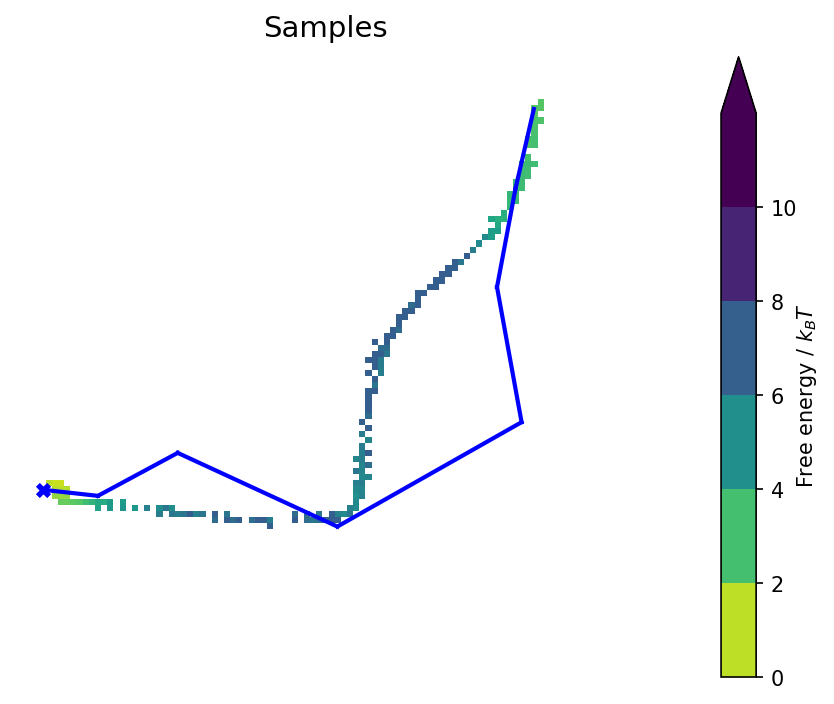

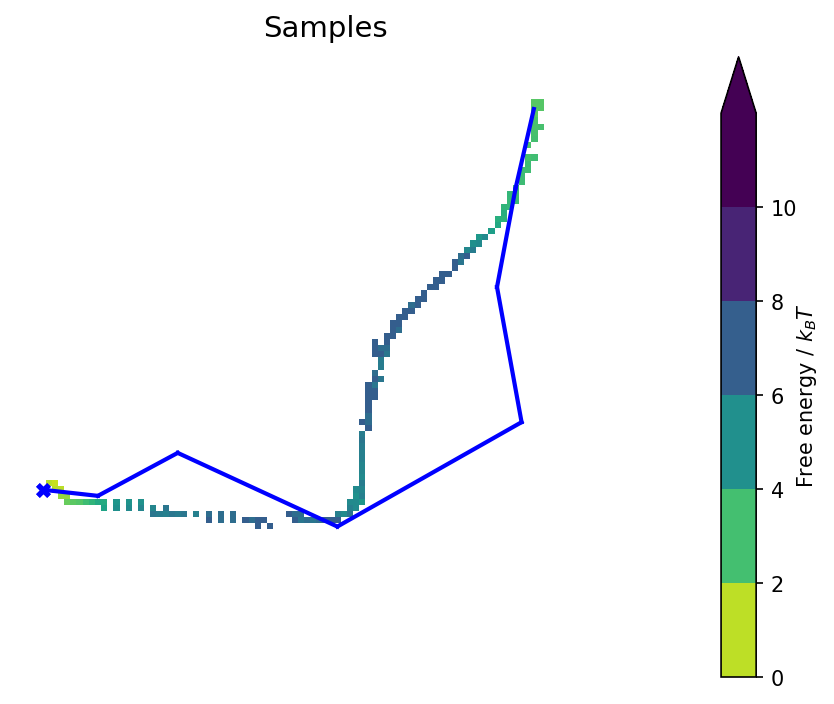

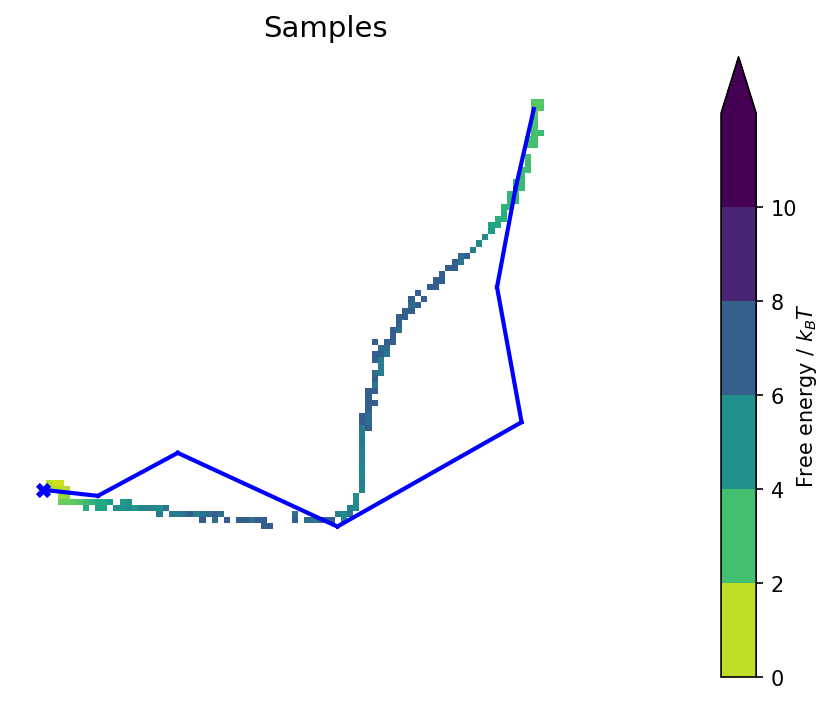

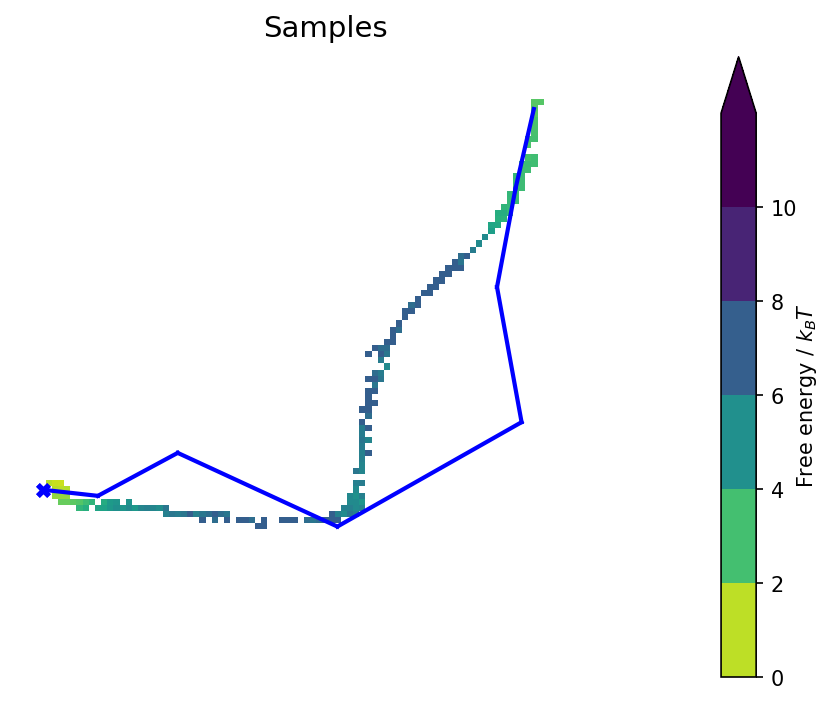

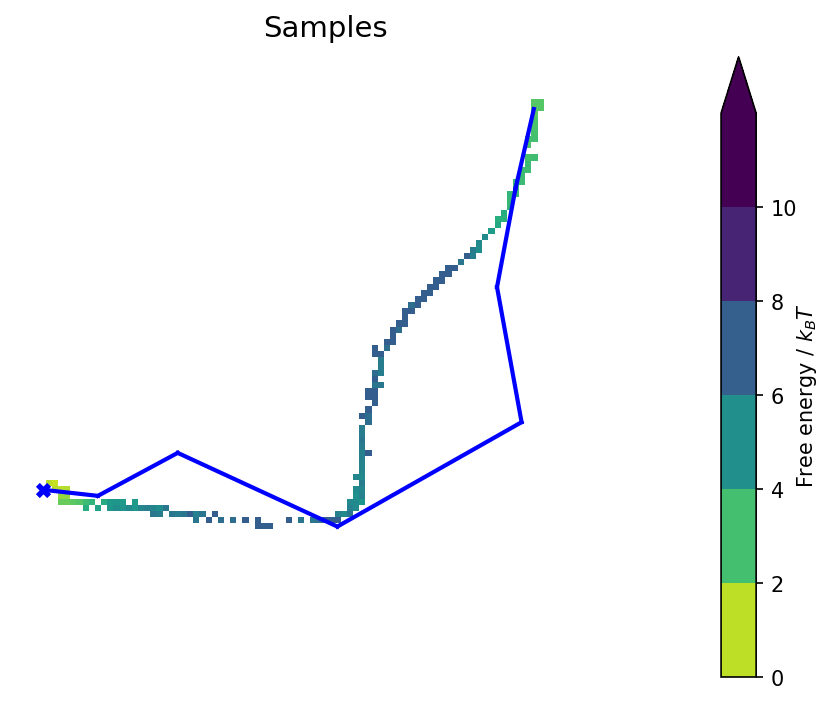

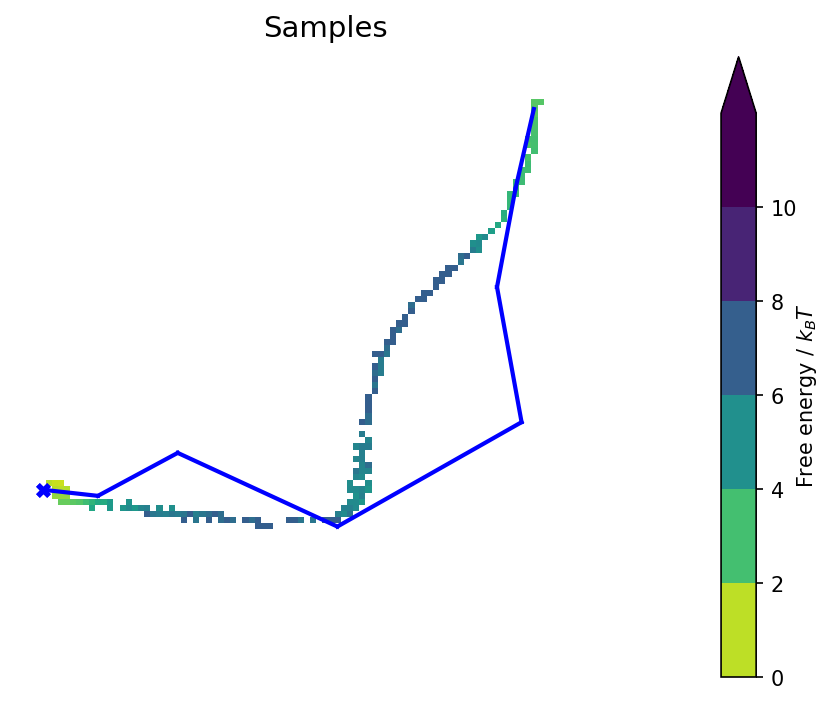

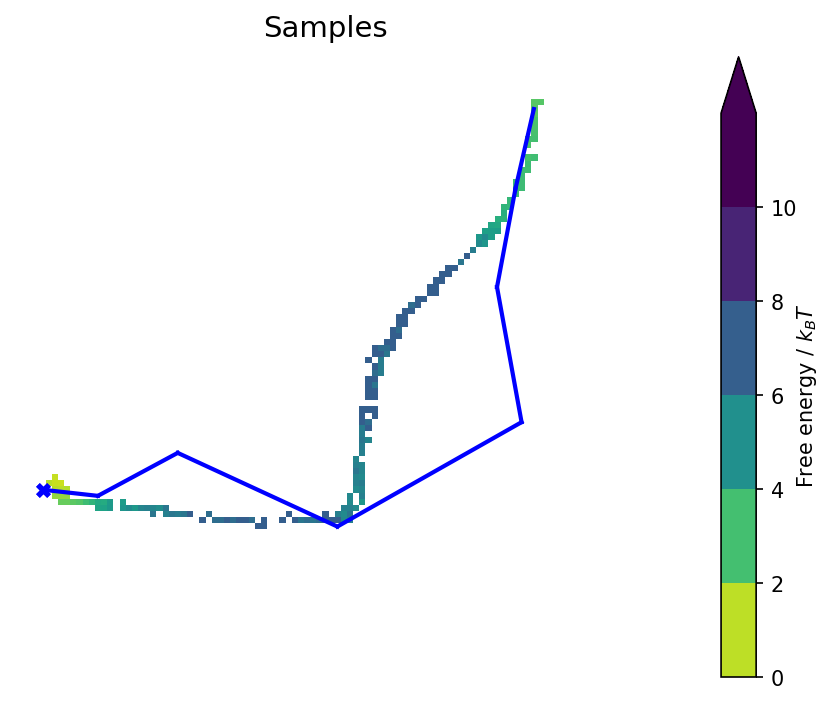

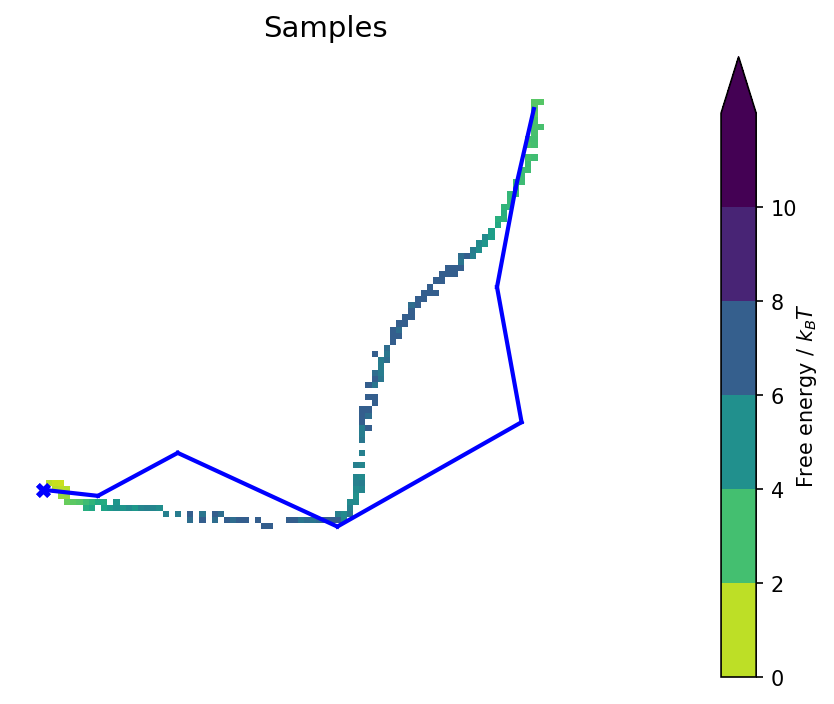

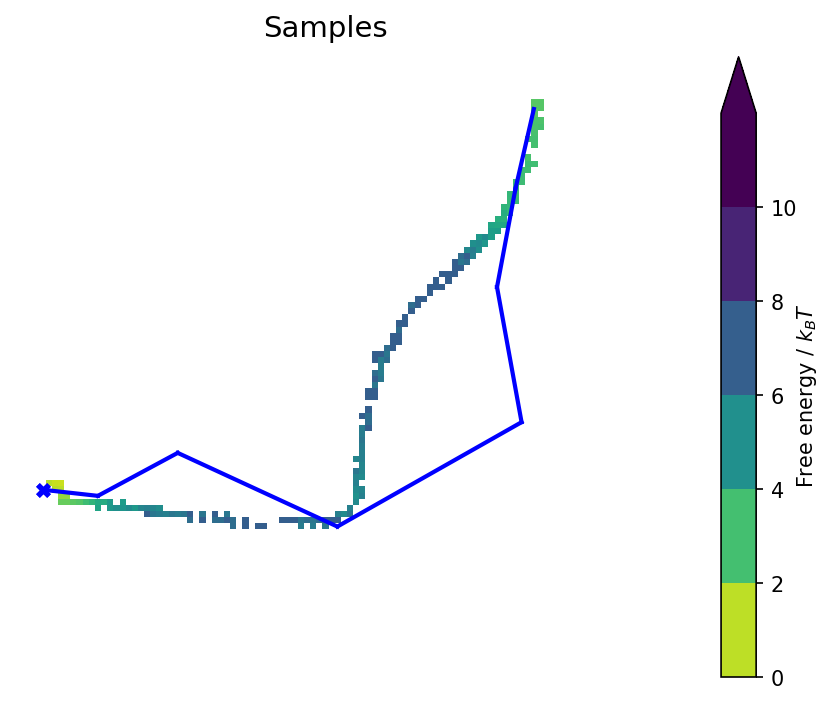

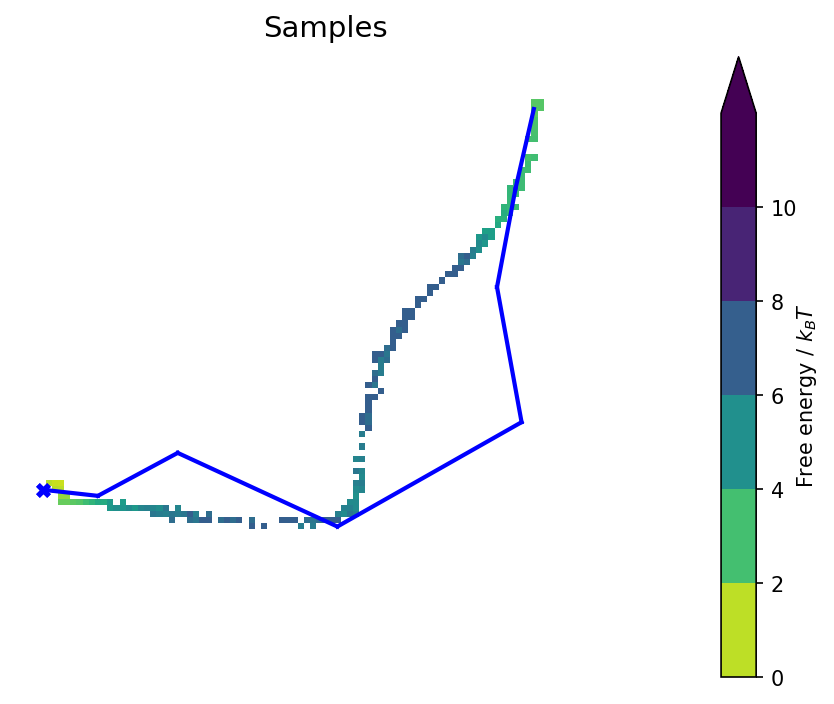

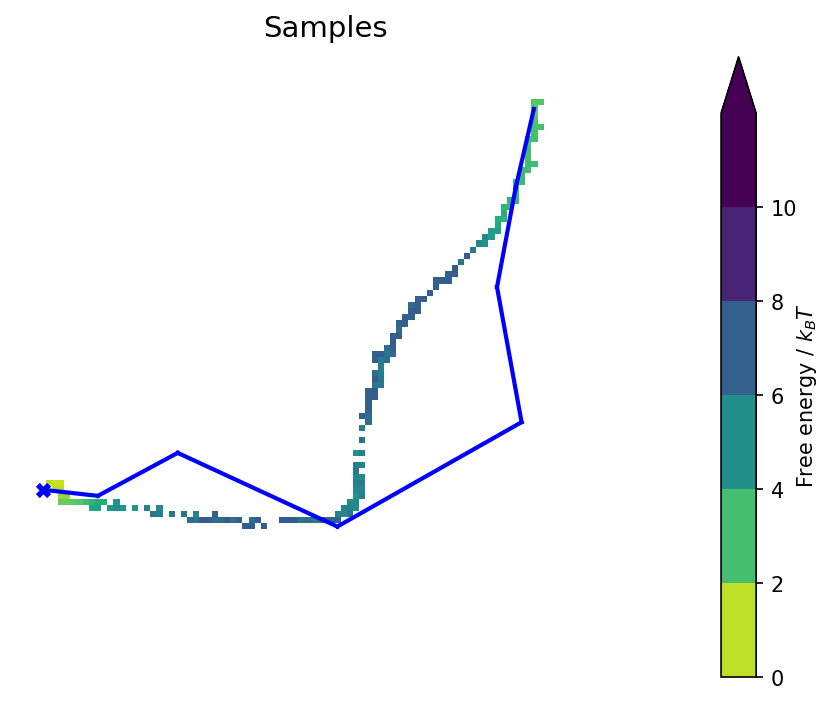

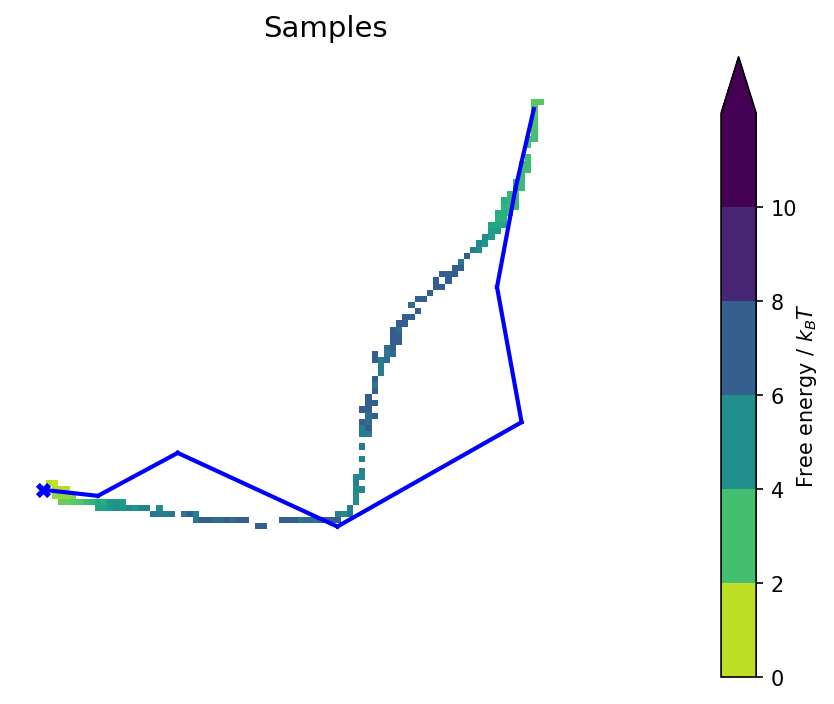

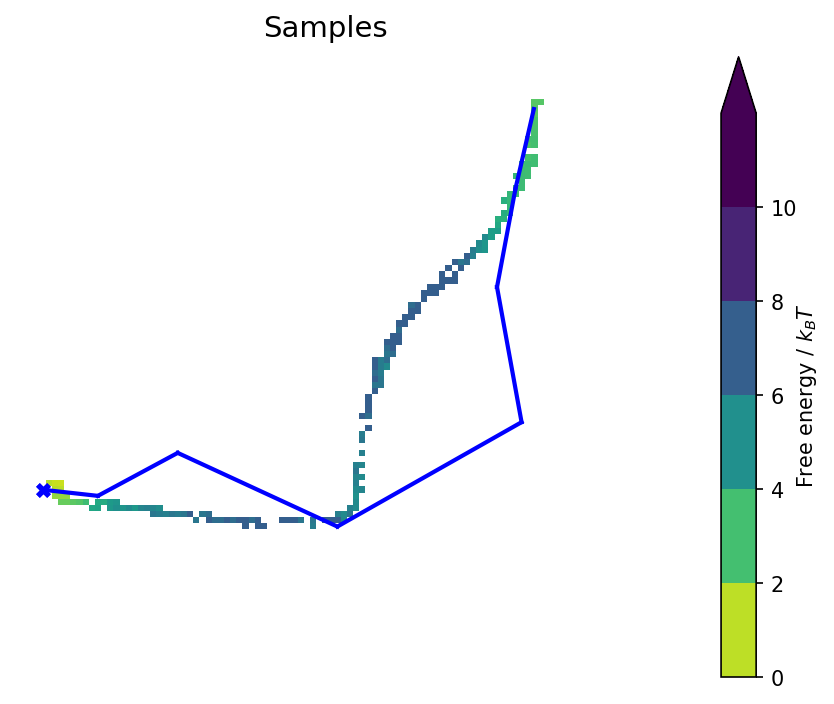

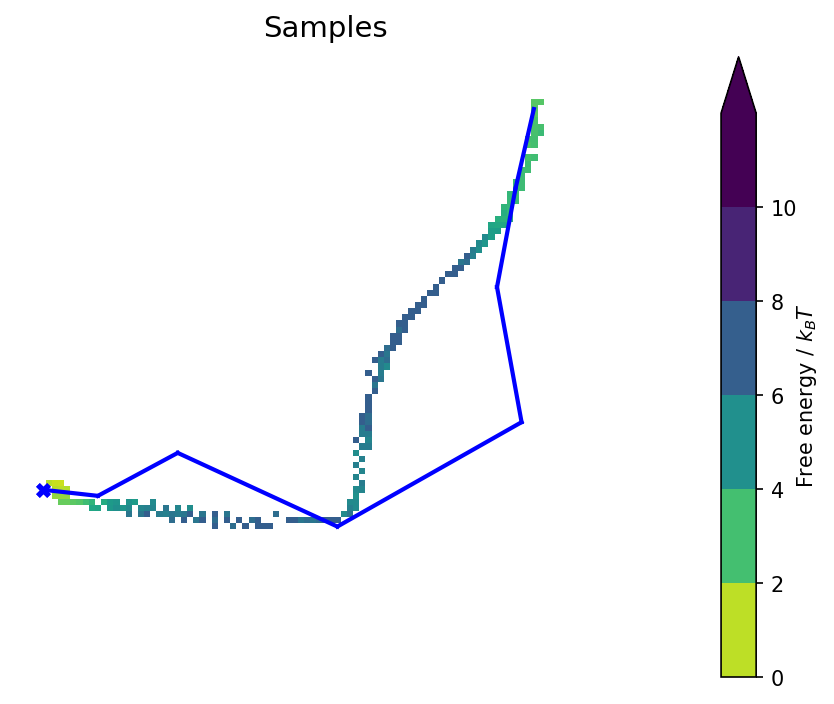

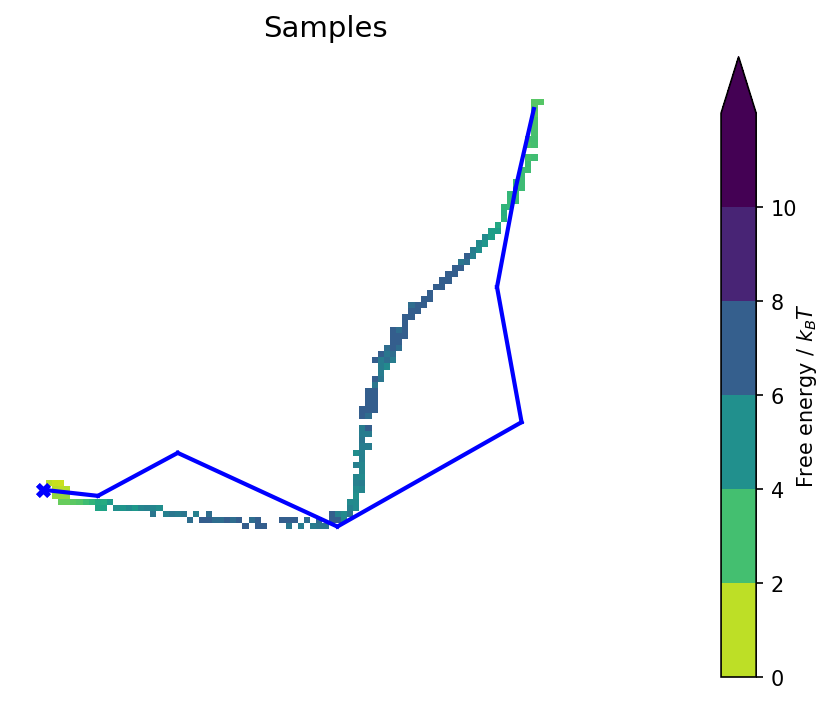

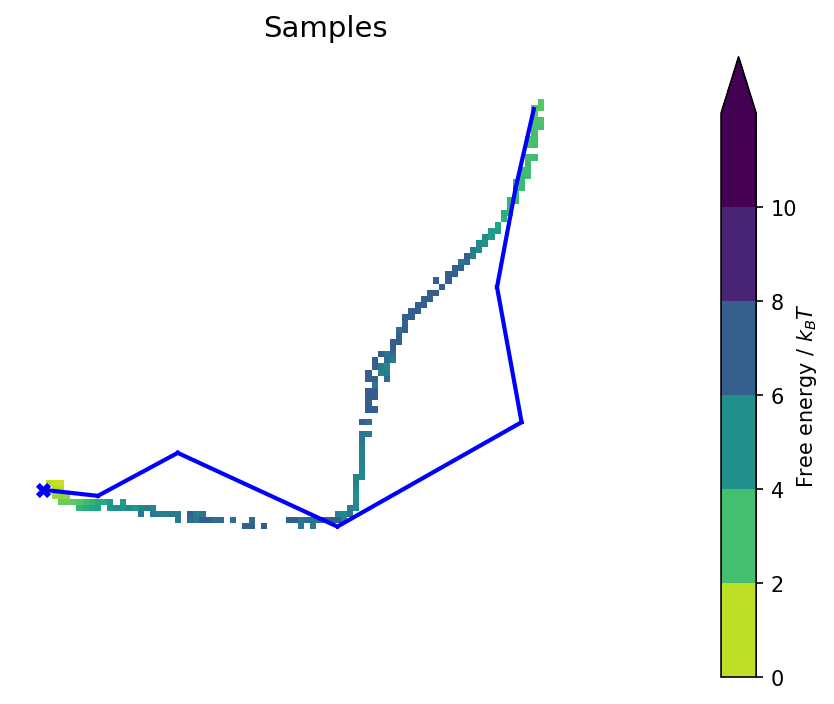

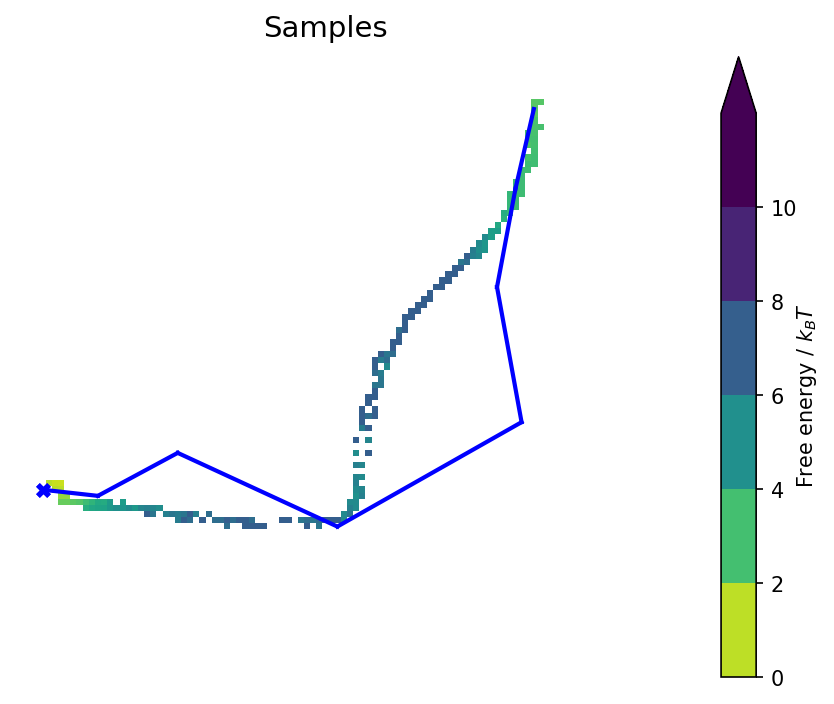

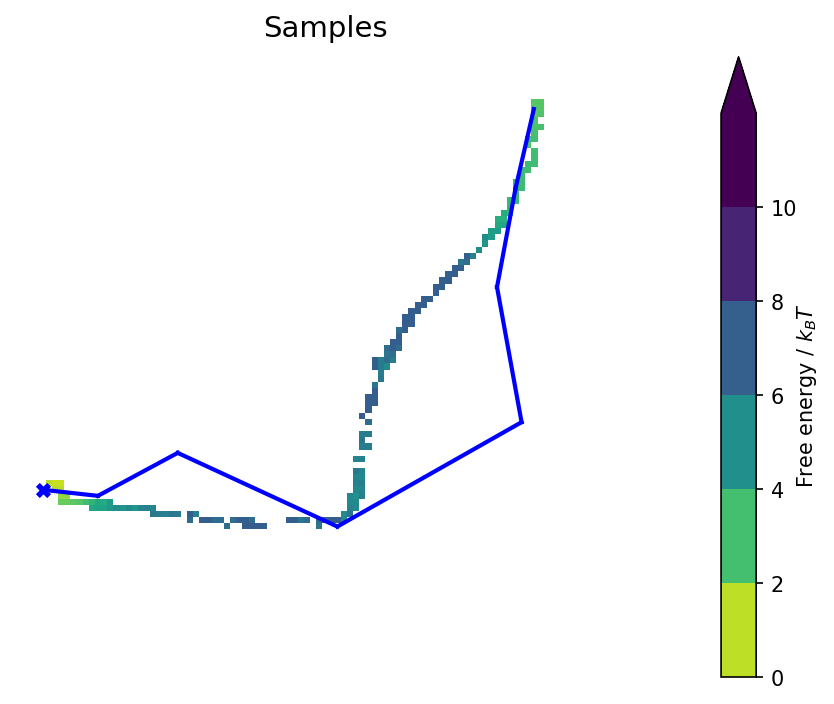

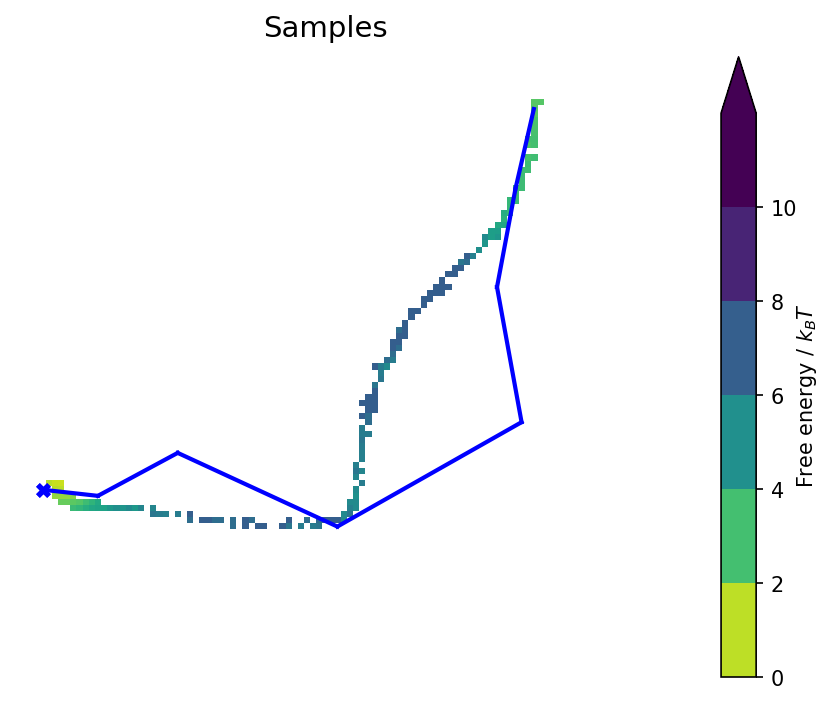

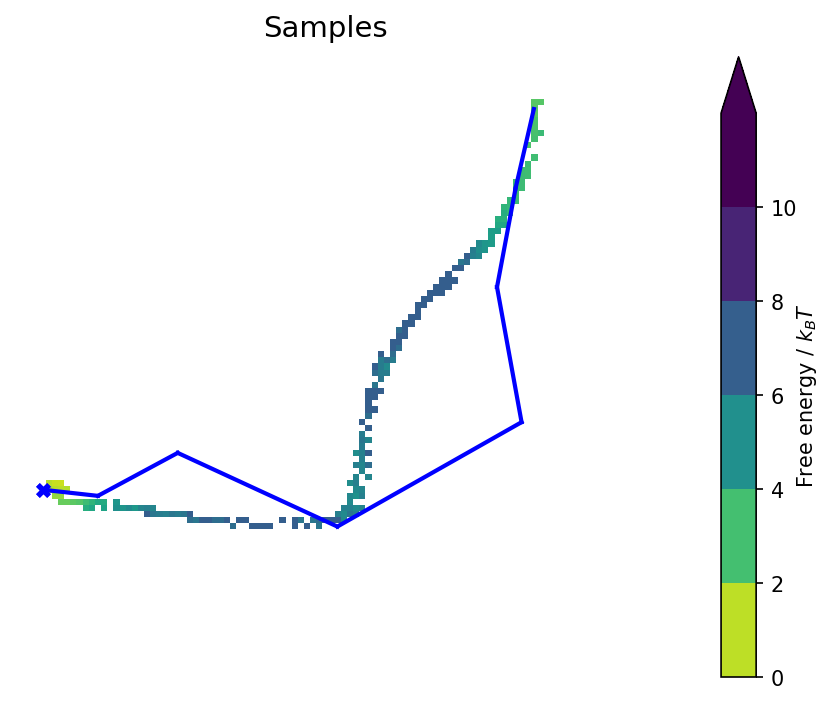

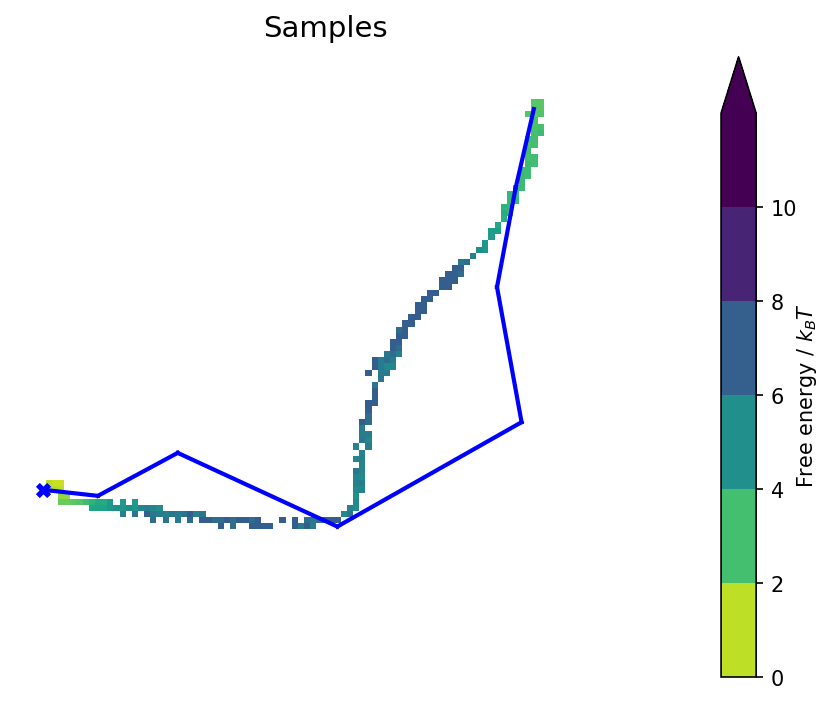

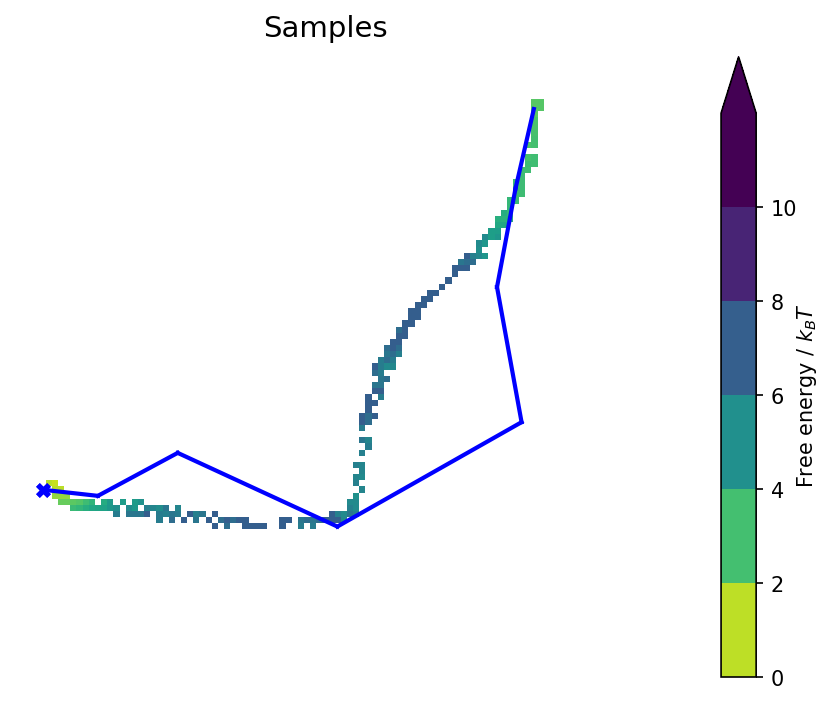

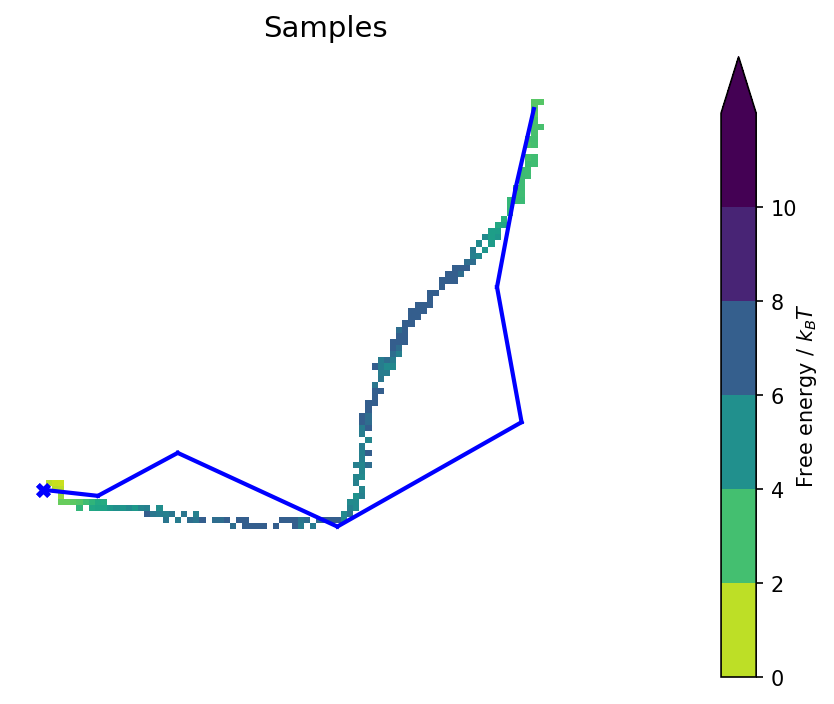

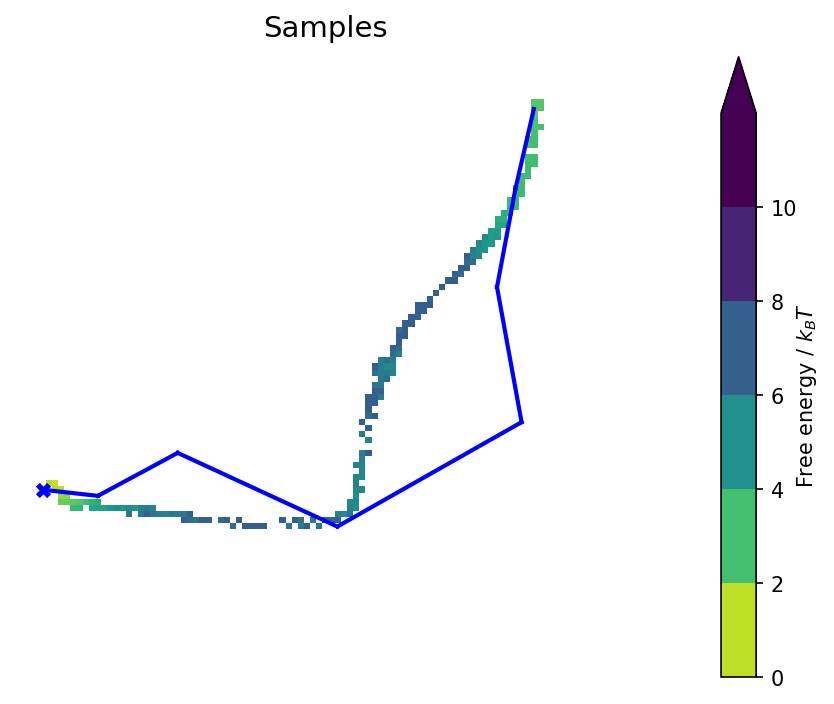

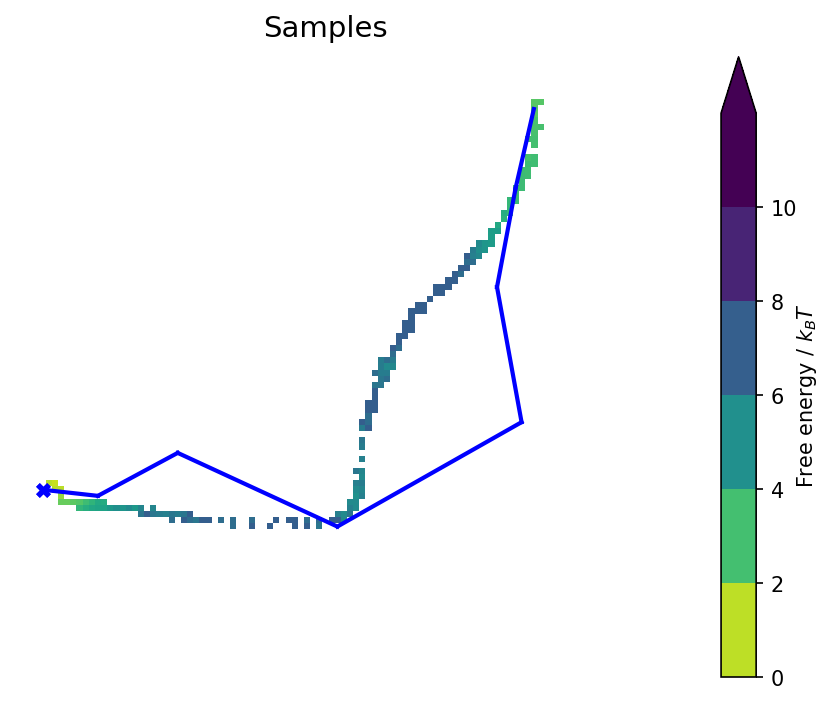

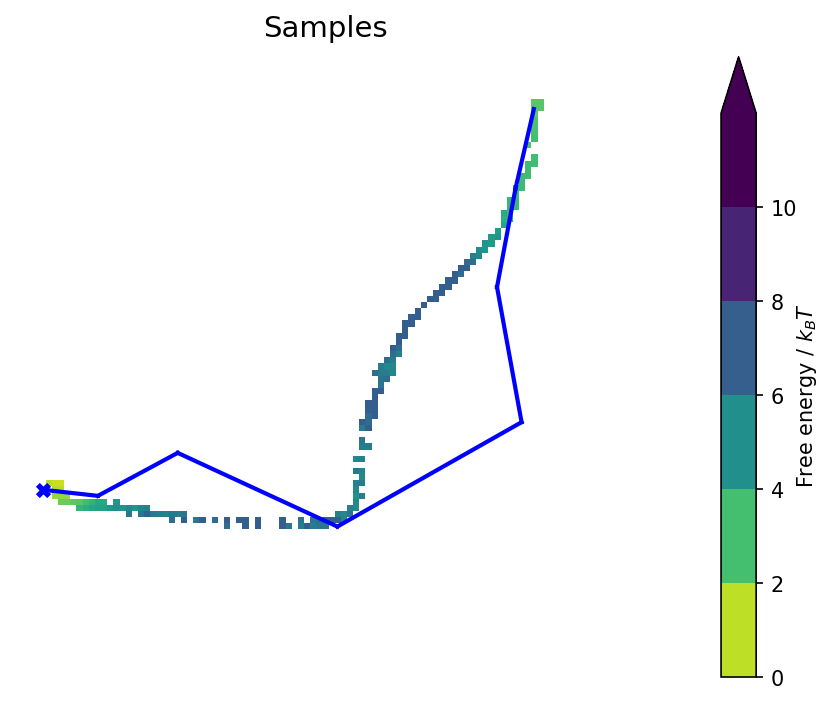

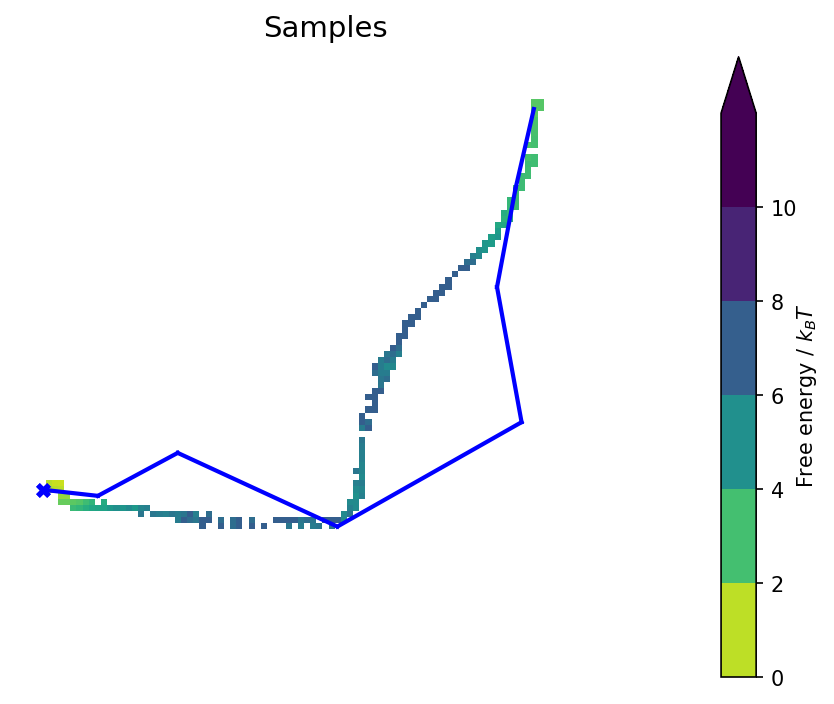

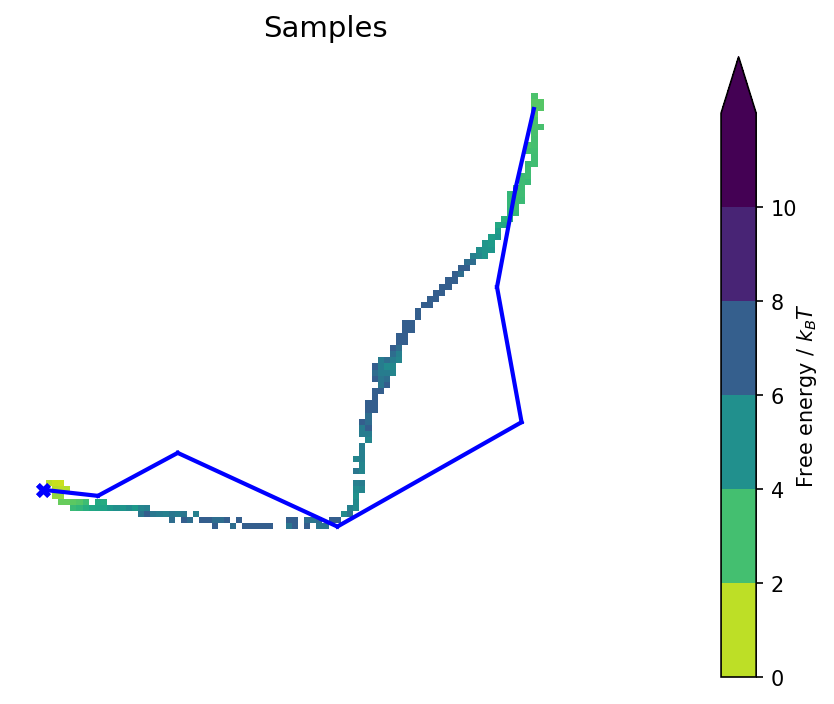

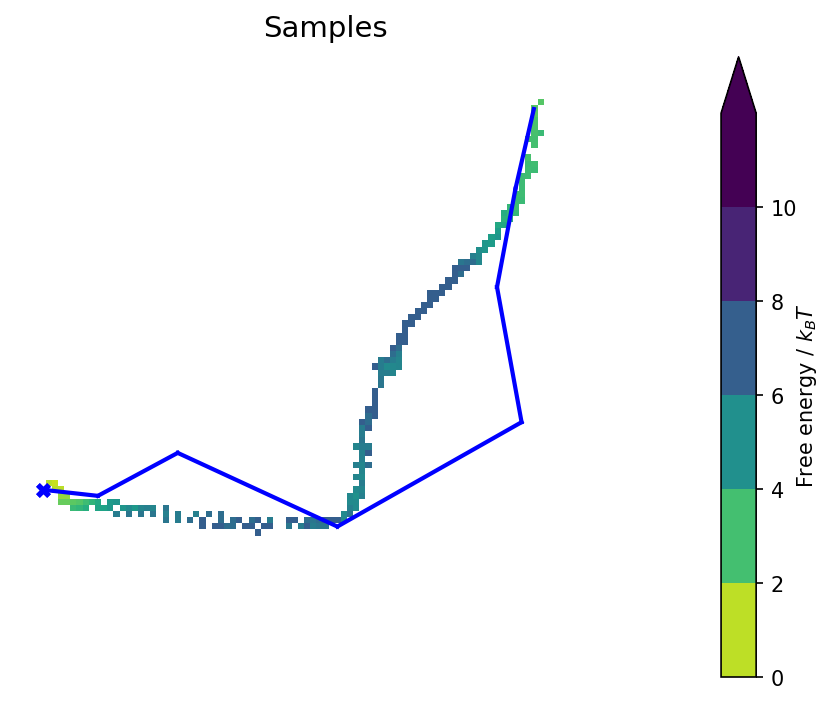

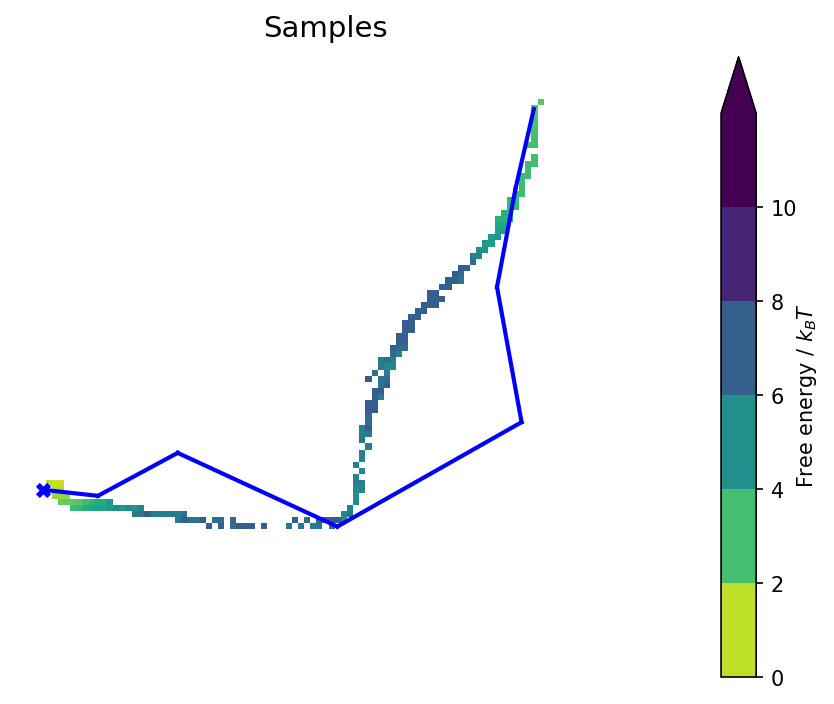

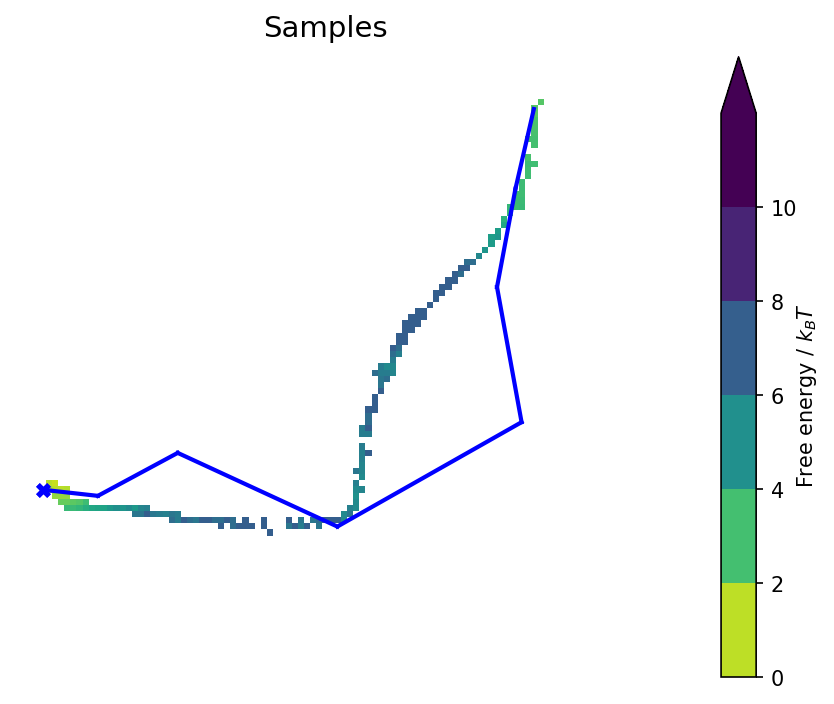

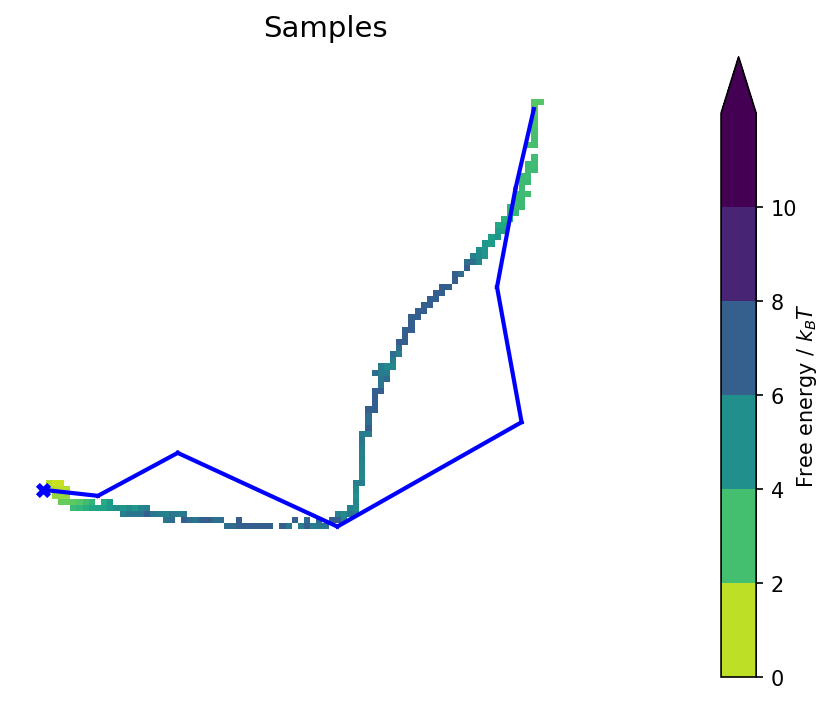

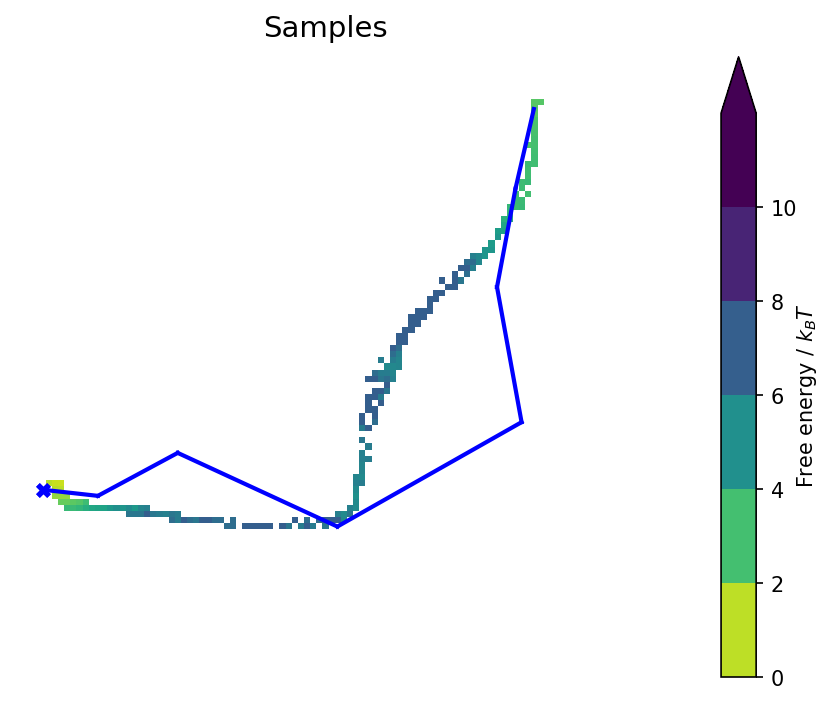

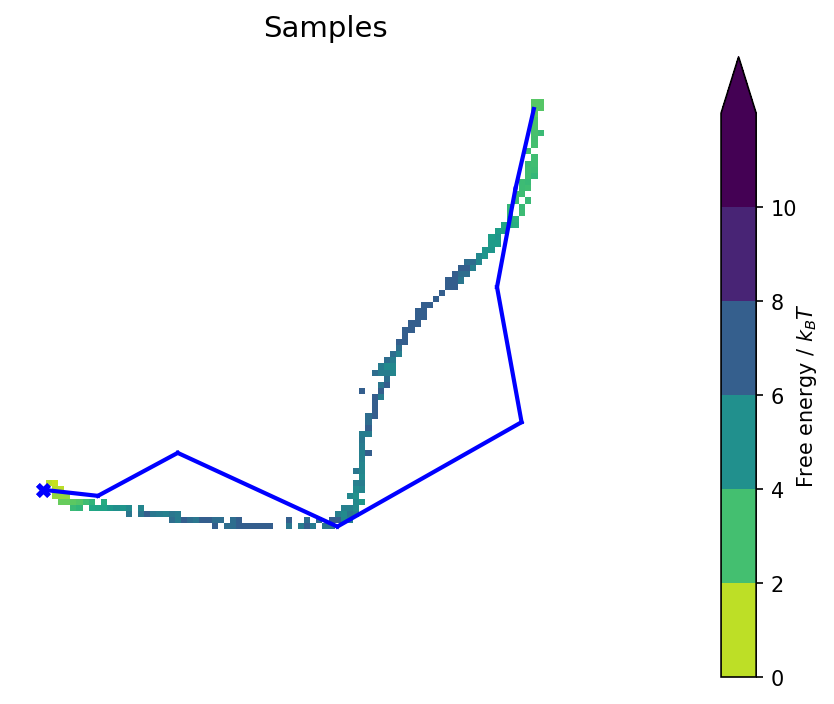

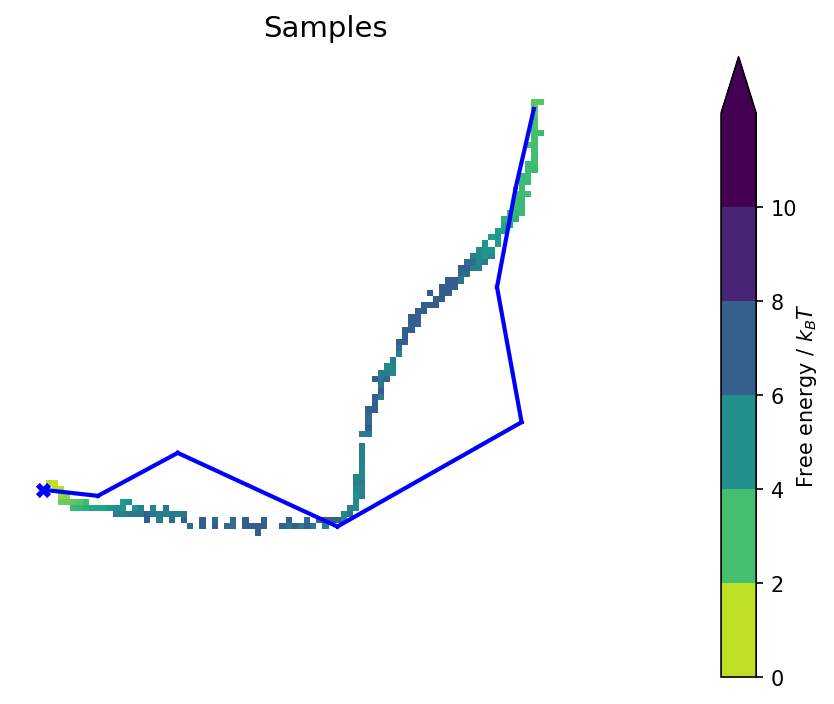

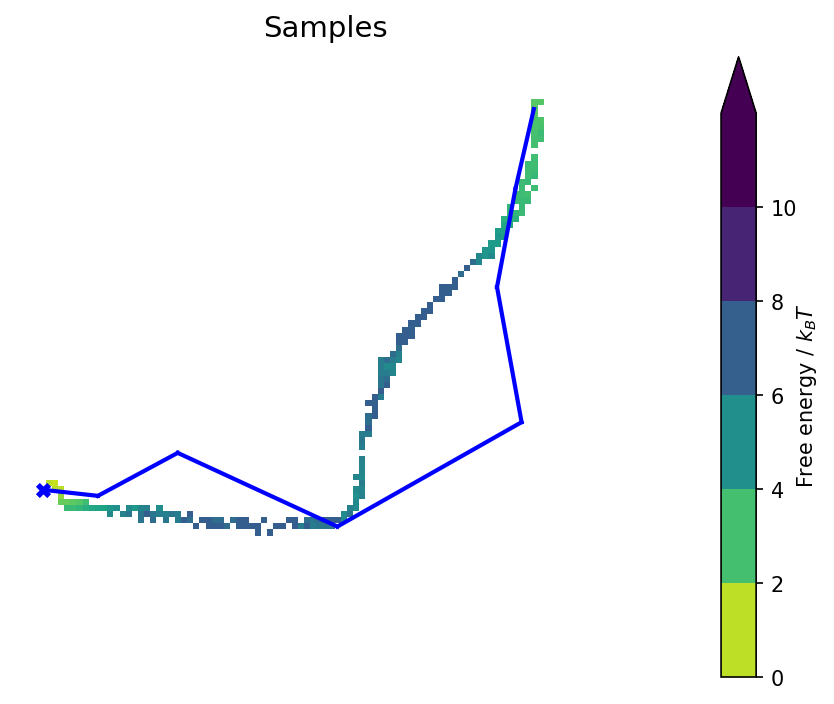

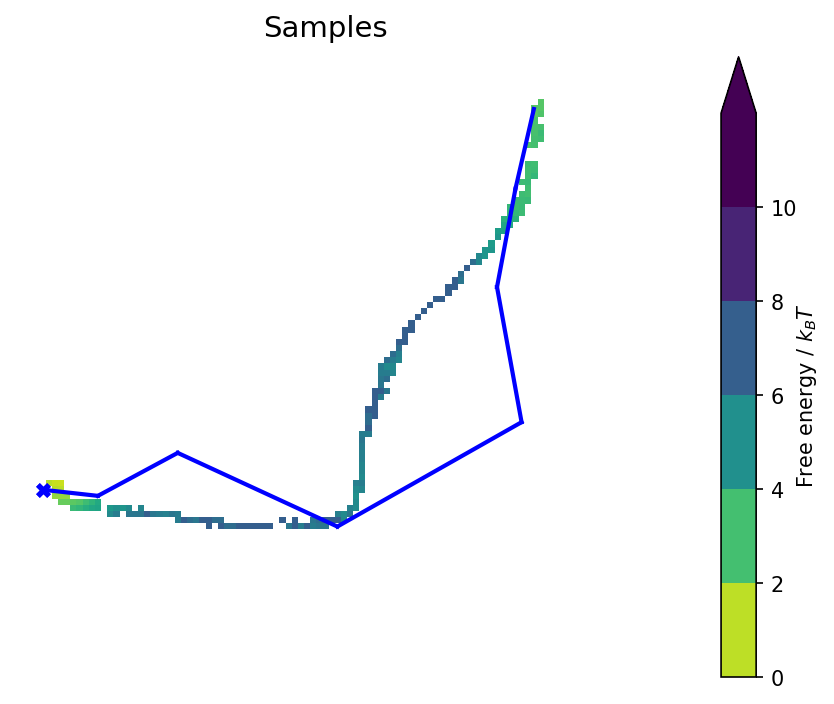

In [8]:
protein_name = "trp_cage"
start = CLUSTER_ENDPOINTS[protein_name][0]
end = CLUSTER_ENDPOINTS[protein_name][1]
gen_mode = "om_interpolate" # Mode of generation, "iid" or "langevin"
subsample = None # Give integer if only a random subset of the samples should be analyzed (if None, all samples are used)
append_exp_name = "no_encode_decode_linear_latent_time=15"
prob_matrix, kmeans_cluster_centers = dynamics_analysis(protein_name, "langevin", None, num_clusters = 20, subsample=subsample)
# start_tica_coord = start_tica_coords[protein_name]
# end_tica_coord =  end_tica_coords[protein_name]
# start = np.argmin(np.linalg.norm(kmeans_cluster_centers - start_tica_coord, axis=-1)) + 1
# end = np.argmin(np.linalg.norm(kmeans_cluster_centers - end_tica_coord, axis=-1)) + 1
path = most_probable_path(prob_matrix, start, end)
path= [i-1 for i in path]  # Convert back to zero indexing
path_centers = kmeans_cluster_centers[path]

free_energy = get_tic_plot(protein_name, gen_mode, append_exp_name, subsample, ref_path=path_centers, gif=True, window_size=3)
# gen_mode = "interpolate" # Mode of generation, "iid" or "langevin"
# subsample = None # Give integer if only a random subset of the samples should be analyzed (if None, all samples are used)
# append_exp_name = "linear_latent_time=0"

# get_tic_plot(protein_name, gen_mode, append_exp_name, subsample, ref_path=path_centers)


# create_consolidated_plot(figures, latent_times)


### TIC analysis

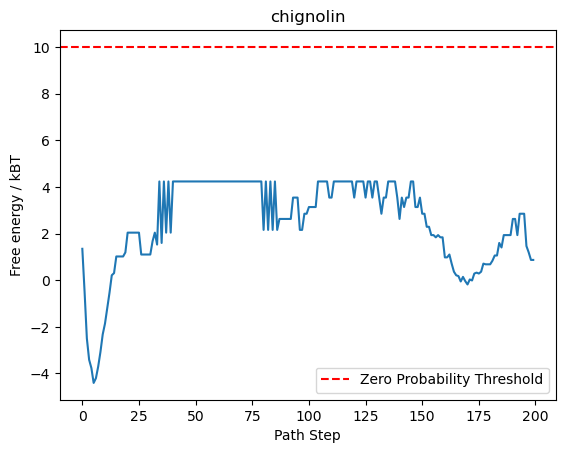

In [5]:
plt.figure()
plt.plot(free_energy[:free_energy.shape[0] // 2])
plt.xlabel("Path Step")
plt.ylabel("Free energy / kBT")
plt.title(protein_name)
plt.axhline(10, color='red', linestyle='--', label='Zero Probability Threshold')
plt.legend()

In [24]:
protein_name = "chignolin" # Options: chignolin, trp_cage, bba, villin, protein_g
start = CLUSTER_ENDPOINTS[protein_name][0]
end = CLUSTER_ENDPOINTS[protein_name][1]
gen_mode = "langevin" # Mode of generation, "iid" or "langevin"
subsample = None # Give integer if only a random subset of the samples should be analyzed (if None, all samples are used)
append_exp_name = None
prob_matrix, kmeans_cluster_centers = dynamics_analysis(protein_name, gen_mode, append_exp_name, num_clusters = 20, subsample=subsample)
path = most_probable_path(prob_matrix, start, end)
path= [i-1 for i in path]  # Convert back to zero indexing
path_centers = kmeans_cluster_centers[path]
path_coords = np.load(f"saved_references/saved_cluster_rep_coords_{protein_name.upper()}.npy")[path]
gt_vis = get_interpolation_viz(path_coords.transpose(1, 0, 2))
gen_mode = "om_interpolate" # Mode of generation, "iid" or "langevin"
latent_times = [20]
append_exp_names = [f"no_encode_decode_linear_latent_time={int(l)}" for l in latent_times] # Name of the experiment, leave as an empty string if not applicable

figures = [get_tic_plot(protein_name, gen_mode, append_exp_name, subsample, ref_path = path_centers) for append_exp_name in append_exp_names]

visualizations = [visualize_interpolation(protein_name, gen_mode, append_exp_name, subsample) for append_exp_name in append_exp_names]
visualizations = [gt_vis] + visualizations
for vis in visualizations:
    visualize_gif(vis)
# create_consolidated_plot(figures, latent_times)


Atoms: [TYR1-CA, TYR2-CA, ASP3-CA, PRO4-CA, GLU5-CA, THR6-CA, GLY7-CA, THR8-CA, TRP9-CA, TYR10-CA]
> /home/sanjeevr/om-diffusion/two-for-one-diffusion/evaluate/evaluators.py(402)__init__()
    400         if os.path.exists(saved_ref):
    401             # Load the saved objects
--> 402             with open(saved_ref, "rb") as f:
    403                 (
    404                     self.tica,

(101, 101)
(102,)
(102,)
(101, 101)
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
1548.134562920936
*** AttributeError: 'TicEvaluator' object has no attribute 'gt_pr

In [8]:
# # JS divergence
# tica_js = js_divergence(prob_samp.flatten(), tic_evaluator.gt_prob.flatten())
# print(f"JS divergence to reference distribution: {tica_js:.4f}")

### Pairwise distances

In [9]:
# # Initialize evaluator
# pwd_evaluator = PwdEvaluator(val_data=None, 
#                              plots_folder=eval_folder, 
#                              offset=3, 
#                              mol_name=protein_name,
#                              evalset='testset') # The evalset is the set we'll compare to in the next evaluation steps

# # Get samples pairwise distances
# pwd_sampled = get_pwd_triu_batch(sampled_mol, pwd_evaluator.offset)

# # Jensen-Shannon divergence to reference
# pwd_js = pwd_evaluator.js_divergence_pwd(pwd_evaluator.gt_hist, 
#                                          pwd_sampled, 
#                                          pwd_evaluator.gt_max, 
#                                          pwd_evaluator.resolution)

# print(f"JS divergence to reference distribution: {pwd_js:.4f}")

### RMSD

In [22]:
# Initialize evaluator
protein_name = "chignolin"
gen_mode = "om_interpolate"
append_exp_name_str = "no_encode_decode_linear_latent_time=20"
eval_folder = f"../saved_models/{protein_name}/main_eval_output_{gen_mode}_{append_exp_name_str}"
sample_path = Path(eval_folder, f"sample-{gen_mode}.pt")
pdb_file = f"../datasets/folded_pdbs/{Molecules[protein_name.upper()].value}-0-c-alpha.pdb"
# Load sampled molecules
sampled_mol = torch.load(sample_path)

rmsd_evaluator = RmsdEvaluator(mol_name=protein_name,
                               folded_pdb=f"../datasets/folded_pdbs/{Molecules[protein_name.upper()].value}.pdb",
                               eval_folder=eval_folder)

In [23]:
# # Plot
save_plot = True # Whether or not to save the displayed plots

# Recommended settings for plots
cutoff_dict = {'chignolin': 10, 'trp_cage': 12, 'bba': 14, 'villin': 14, 'protein_g': 20}
cutoff = cutoff_dict[protein_name.lower()]
nbins = 100 

# Load evaluation from reference data
rmsd_evaluator.eval("Reference", None, nbins, cutoff)

# Evaluate samples
rmsd_evaluator.eval(gen_mode, sampled_mol, nbins, cutoff)
rmsd_evaluator._plot_rmsd(save=save_plot)

> /home/sanjeevr/om-diffusion/two-for-one-diffusion/evaluate/evaluators.py(729)eval()
    727             rmsd = np.full(len(xyz), np.nan)
    728             import pdb; pdb.set_trace()
--> 729             rmsd[valid_mask] = md.rmsd(traj, self.folded) * 10
    730 
    731             if save_dynamics:

*** AttributeError: 'Trajectory' object has no attribute 'shape'. Did you mean: 'save'?
<mdtraj.Trajectory with 1 frames, 10 atoms, 10 residues, and unitcells at 0x7f2647aac830>
(1, 10, 3)


### Contacts

In [20]:
# Contact cutoff (in angstrom), recommended: 10
cutoff = 10

if subsample is not None:
    sampled_mol = sampled_mol[np.random.permutation(subsample)]

# Initialize evaluator
contacts = ContactEvaluator(mol_name=protein_name, 
                            folded_pdb=f"../datasets/folded_pdbs/{Molecules[protein_name.upper()].value}.pdb", 
                            eval_folder=eval_folder,
                            contact_cutoff=cutoff
)

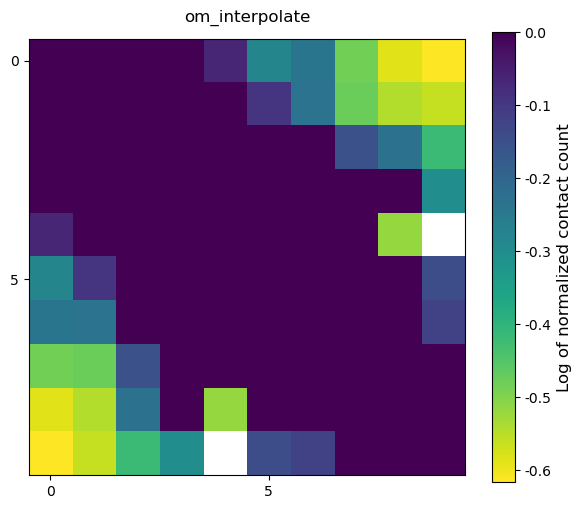

In [21]:
# Plot
save_plot = True # Whether or not to save the displayed plots


# Plot normalized count over contacts (contact probability) for samples
_ = contacts._plot_contact_normcount(
    sampled_mol, gen_mode, save=save_plot, take_log=True
)